## MPD 데이터셋 병합 (50k)

In [ ]:
import os
import json
import kagglehub
import pandas as pd
import gc

# 1. 데이터셋 다운로드 경로 확보 (이미 다운된 파일은 캐시에서 즉시 경로만 반환됨)
print("데이터셋 경로 확인 중...")
dataset_dir = kagglehub.dataset_download("himanshuwagh/spotify-million")
data_path = os.path.join(dataset_dir, "data") if os.path.exists(os.path.join(dataset_dir, "data")) else dataset_dir

# 2. 50개 파일 경로 생성
num_slices =
target_files = [
    os.path.join(data_path, f"mpd.slice.{i * 1000}-{(i * 1000) + 999}.json")
    for i in range(num_slices)
]

output_file = "spotify_sample_50k.csv"
if os.path.exists(output_file):
    os.remove(output_file)

print("병합 시작...")

# 3. 직접 json 로드 후 playlists 추출하여 CSV에 순차 작성
success_count = 0
for idx, file_path in enumerate(target_files, 1):
    if idx % 20 == 0 or idx == num_slices:
        print(f"[{idx}/{num_slices}] 처리 중: {os.path.basename(file_path)}")

    try:
        # JSON 직접 열기
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # 최상위 키 중 실제 데이터인 'playlists'만 DataFrame으로 변환
        temp_df = pd.DataFrame(data["playlists"])

        # 첫 번째 파일은 컬럼 헤더 포함, 이후는 내용만 추가
        if success_count == 0:
            temp_df.to_csv(output_file, mode="w", index=False)
        else:
            temp_df.to_csv(output_file, mode="a", index=False, header=False)

        success_count += 1
        del temp_df, data

    except FileNotFoundError:
        print(f"파일 없음: {os.path.basename(file_path)}")
    except Exception as e:
        print(f"오류 발생 ({os.path.basename(file_path)}): {e}")

    if idx % 50 == 0:
        gc.collect()

print(f"\n총 {success_count}개 파일 병합 완료: {output_file}")

데이터셋 경로 확인 중...


100%|██████████| 5.20G/5.20G [02:17<00:00, 40.5MB/s]

Extracting files...


병합 시작...
[20/50] 처리 중: mpd.slice.19000-19999.json
[40/50] 처리 중: mpd.slice.39000-39999.json
[50/50] 처리 중: mpd.slice.49000-49999.json

총 50개 파일 병합 완료: spotify_sample_300k.csv


## 장르 대분류 매핑

In [ ]:
import re
import pandas as pd

# 1. 데이터 로드
df = pd.read_csv("all_unique_purpose_labels.csv")

# TPO 목적 플리('yes') 제외
target_df = df[df["has_purpose"].astype(str).str.lower() != "yes"].copy()
target_df["name_clean"] = target_df["name_key"].fillna("").astype(str).str.lower()

# 2. 세부 팝 장르별 정규식 정의
SUB_POP_PATTERNS = {
    "K-Pop": re.compile(r"\b(k[\s-]?pop|korean[\s-]?pop)\b", re.I),
    "J-Pop": re.compile(r"\b(j[\s-]?pop|japanese[\s-]?pop)\b", re.I),
    "Latin Pop": re.compile(r"\b(latin[\s-]?pop|reggaeton|latin[\s-]?urban)\b", re.I),
    "Indie/Alt Pop": re.compile(r"\b(indie[\s-]?pop|alt[\s-]?pop|bedroom[\s-]?pop)\b", re.I),
    "Electropop/Synthpop": re.compile(r"\b(electropop|synthpop|dance[\s-]?pop)\b", re.I),
    "General Pop": re.compile(r"\b(pop|pop[\s-]?hits|top[\s-]?pop|mainstream[\s-]?pop)\b", re.I),
}

# 3. 각 서브 장르별 매칭 및 집계
results = []
samples = {}

for genre_name, pattern in SUB_POP_PATTERNS.items():
    matched = target_df[target_df["name_clean"].str.contains(pattern, regex=True)]

    unique_count = len(matched)
    total_playlists = matched["n_playlists"].sum() if "n_playlists" in matched.columns else unique_count

    results.append({
        "Subgenre": genre_name,
        "Unique_Titles": unique_count,
        "Total_Playlists": int(total_playlists),
    })

    # 상위 5개 샘플 제목 저장
    if "n_playlists" in matched.columns:
        top_samples = matched.sort_values(by="n_playlists", ascending=False)["name_clean"].head(5).tolist()
    else:
        top_samples = matched["name_clean"].head(5).tolist()
    samples[genre_name] = top_samples

# 4. 결과 출력
summary_df = pd.DataFrame(results).sort_values(by="Total_Playlists", ascending=False)

print("=== [세부 팝 장르별 데이터 분포] ===")
print(summary_df.to_string(index=False))

print("\n=== [장르별 대표 플리 제목 샘플 (상위 5개)] ===")
for genre_name, title_list in samples.items():
    print(f"\n[{genre_name}] ({len(title_list)}개 확인)")
    for t in title_list:
        print(f" - {t}")

=== [세부 팝 장르별 데이터 분포] ===
           Subgenre  Unique_Titles  Total_Playlists
        General Pop            190             6283
          Latin Pop             32             1276
              K-Pop             24             1145
      Indie/Alt Pop              9              170
Electropop/Synthpop              4               92
              J-Pop              6               39

=== [장르별 대표 플리 제목 샘플 (상위 5개)] ===

[K-Pop] (5개 확인)
 - kpop
 - k-pop
 - k pop
 - kpop!
 - kpop :)

[J-Pop] (5개 확인)
 - jpop
 - j-pop
 - #jpop
 - *j-pop*
 - jpop!!

[Latin Pop] (5개 확인)
 - reggaeton
 - latin pop
 - reggaeton viejo
 - old school reggaeton
 - reggaeton 2017

[Indie/Alt Pop] (5개 확인)
 - indie pop
 - indiepop
 - indie pop rock
 - indie pop/rock
 - indie pop!

[Electropop/Synthpop] (4개 확인)
 - electropop
 - synthpop
 - dance pop
 - !! synthpop

[General Pop] (5개 확인)
 - pop
 - pop punk
 - k-pop
 - punk goes pop
 - pop music


/tmp/ipykernel_2306/2766043607.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matched = target_df[target_df["name_clean"].str.contains(pattern, regex=True)]


장르 대분류 매핑 완료 및 파일 저장: standardized_genre_labels.csv

--- 카테고리별 고유 제목 수 및 전체 플레이리스트 커버리지 ---
                unique_titles  total_playlists
standard_genre                                
HipHop                    393            21648
Country                   289            21364
Rock                      484            21213
EDM                       205             9414
RnB_Soul                  160             7159
Pop                       170             6147
Classical                  48             3575
Jazz                       80             3047


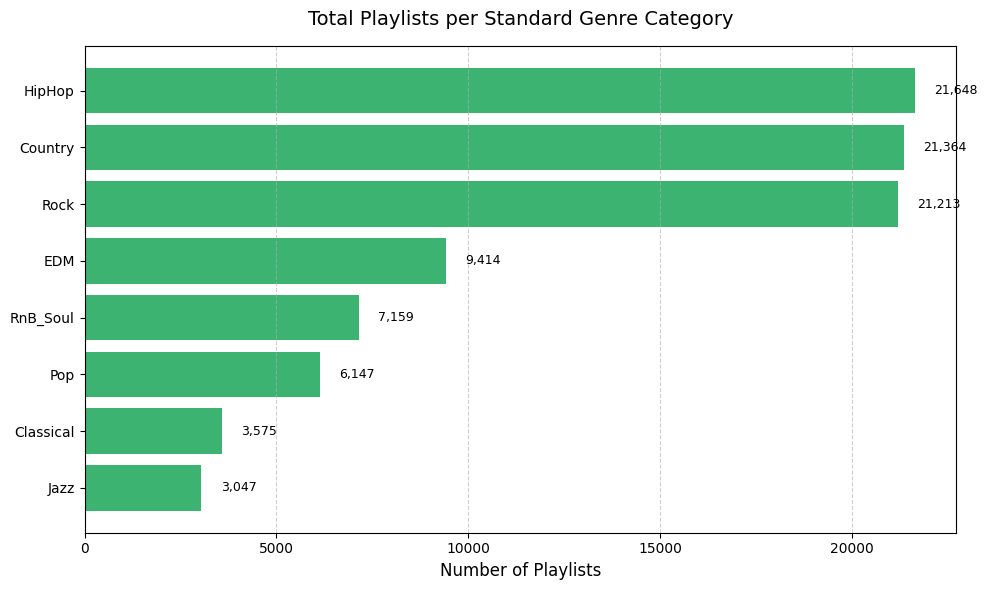

In [ ]:
import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. 파일 로드
df = pd.read_csv("all_unique_purpose_labels.csv")

# 2. 8대 핵심 음악 장르 정규표현식 사전 정의
GENRE_PATTERNS = {
    "Rock": re.compile(
        r"\b(rock|metal|punk|hardrock|altrock|grunge|indie[\s-]?rock)\b", re.I
    ),
    "HipHop": re.compile(
        r"\b(hip[\s-]?hop|rap|trap|boom[\s-]?bap|drill)\b", re.I
    ),
    "Pop": re.compile(
        r"\b(pop|kpop|k[\s-]?pop|jpop|synthpop|electropop|dancepop)\b", re.I
    ),
    "EDM": re.compile(
        r"\b(edm|house|techno|trance|dubstep|electronic|dnb|drum[\s-]?and[\s-]?bass)\b",
        re.I,
    ),
    "RnB_Soul": re.compile(
        r"\b(r&b|rnb|soul|neo[\s-]?soul|motown|funk)\b", re.I
    ),
    "Country": re.compile(
        r"\b(country|bluegrass|americana|folk[\s-]?country)\b", re.I
    ),
    "Jazz": re.compile(
        r"\b(jazz|bebop|swing|smooth[\s-]?jazz|bossa[\s-]?nova)\b", re.I
    ),
    "Classical": re.compile(
        r"\b(classical|orchestra|symphony|piano|baroque|opera|mozart|beethoven|bach)\b",
        re.I,
    ),
}


def map_to_standard_genre(row):
    # TPO 목적 플리('yes')는 장르 시드에서 제외 (순수 장르 플리만 추출)
    if str(row.get("has_purpose", "")).lower() == "yes":
        return "None"

    name = str(row.get("name_key", "")).lower()
    if not name.strip():
        return "None"

    matched_genres = []
    for genre, pattern in GENRE_PATTERNS.items():
        if pattern.search(name):
            matched_genres.append(genre)

    # 1개 장르에만 명확하게 매칭된 경우만 순수 시드로 채택 (장르 중복/혼합 플리 제외)
    if len(matched_genres) == 1:
        return matched_genres[0]
    elif len(matched_genres) > 1:
        return "Mixed_Genre"
    else:
        return "Other_Genre"


# 3. 장르 매핑 적용
df["standard_genre"] = df.apply(map_to_standard_genre, axis=1)

# 순수 8대 단일 장르 시드만 필터링
pure_genres = list(GENRE_PATTERNS.keys())
genre_labels_clean = df[df["standard_genre"].isin(pure_genres)].copy()

# 4. CSV 저장
output_csv = "standardized_genre_labels.csv"
genre_labels_clean.to_csv(output_csv, index=False, encoding="utf-8-sig")

print(f"장르 대분류 매핑 완료 및 파일 저장: {output_csv}")
print("\n--- 카테고리별 고유 제목 수 및 전체 플레이리스트 커버리지 ---")

# 통계 요약
summary = (
    genre_labels_clean.groupby("standard_genre")
    .agg(
        unique_titles=("name_key", "count"),
        total_playlists=("n_playlists", "sum"),
    )
    .sort_values(by="total_playlists", ascending=False)
)
print(summary)

# 5. 시각화
plt.figure(figsize=(10, 6))
bars = plt.barh(
    summary.index[::-1], summary["total_playlists"][::-1], color="mediumseagreen"
)

plt.title("Total Playlists per Standard Genre Category", fontsize=14, pad=15)
plt.xlabel("Number of Playlists", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for bar in bars:
    w = bar.get_width()
    plt.text(
        w + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{int(w):,}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [ ]:
import hashlib
import pandas as pd


def get_split(name_key: str, salt: str = "genre_seed_v1", test_ratio: float = 0.2) -> str:
    """동일 name_key는 반드시 같은 split에 배정 (Data Leakage 방지)"""
    key = f"{salt}:{str(name_key).strip().lower()}".encode("utf-8")
    hash_val = int(hashlib.md5(key).hexdigest()[:8], 16)
    ratio = (hash_val % 10000) / 10000.0
    return "test" if ratio < test_ratio else "train"


def main():
    df = pd.read_csv("standardized_genre_labels.csv")

    # 1. 컬럼명 표준화 및 결측치 제거
    df["name_key"] = df["name_key"].fillna(df["name"]).astype(str).str.lower().str.strip()
    df = df[df["name_key"] != ""].copy()

    # 2. Title-Split 적용 (Train 80% / Test 20%)
    df["split"] = df["name_key"].apply(get_split)

    # 3. 데이터 분할
    train_df = df[df["split"] == "train"].copy()
    test_df = df[df["split"] == "test"].copy()

    # 4. 파일 저장
    train_df.to_csv("genre_seed_train.csv", index=False, encoding="utf-8-sig")
    test_df.to_csv("genre_seed_test.csv", index=False, encoding="utf-8-sig")

    print(f"Train 플리 수: {train_df['n_playlists'].sum():,}개 (고유 제목 {len(train_df):,}개)")
    print(f"Test 플리 수:  {test_df['n_playlists'].sum():,}개 (고유 제목 {len(test_df):,}개)")

    print("\n=== [Train / Test 장르별 분포 확인] ===")
    split_check = (
        df.groupby(["standard_genre", "split"])["n_playlists"]
        .sum()
        .unstack()
        .fillna(0)
    )
    split_check["Total"] = split_check["train"] + split_check["test"]
    split_check["Test_Ratio(%)"] = (
        split_check["test"] / split_check["Total"] * 100
    ).round(1)
    print(split_check)


if __name__ == "__main__":
    main()

Train 플리 수: 84,898개 (고유 제목 1,443개)
Test 플리 수:  8,669개 (고유 제목 386개)

=== [Train / Test 장르별 분포 확인] ===
split           test  train  Total  Test_Ratio(%)
standard_genre                                   
Classical        361   3214   3575           10.1
Country         2141  19223  21364           10.0
EDM              793   8621   9414            8.4
HipHop          1305  20343  21648            6.0
Jazz             461   2586   3047           15.1
Pop              569   5578   6147            9.3
RnB_Soul        1054   6105   7159           14.7
Rock            1985  19228  21213            9.4


## 장르 프로필 생성 (add purity)

In [ ]:
import ast
import json
import pandas as pd
from tqdm import tqdm

input_csv = "spotify_sample_50k.csv"
output_parquet = "sample_50k_flat.parquet"

print("1. 필요한 컬럼만 로드 중...")
df = pd.read_csv(input_csv, usecols=["pid", "name", "tracks"])

rows = []
print("2. tracks 컬럼 평탄화(Flatten) 진행 중...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    pid = int(row["pid"])
    pl_name = str(row["name"]) if pd.notna(row["name"]) else ""
    raw_tracks = row["tracks"]

    if not raw_tracks or pd.isna(raw_tracks):
        continue

    # 문자열로 저장된 리스트 딕셔너리 파싱 (JSON 또는 ast)
    tracks_list = []
    if isinstance(raw_tracks, str):
        try:
            tracks_list = ast.literal_eval(raw_tracks)
        except Exception:
            try:
                tracks_list = json.loads(raw_tracks.replace("'", '"'))
            except Exception:
                continue
    elif isinstance(raw_tracks, list):
        tracks_list = raw_tracks

    for tr in tracks_list:
        if isinstance(tr, dict):
            rows.append(
                {
                    "pid": pid,
                    "name": pl_name,
                    "track_uri": tr.get("track_uri", ""),
                    "artist_uri": tr.get("artist_uri", ""),
                    "album_uri": tr.get("album_uri", ""),
                }
            )

# 3. DataFrame 변환 및 Parquet 저장
print("3. Parquet 파일로 압축 저장 중...")
flat_df = pd.DataFrame(rows)
flat_df["pid"] = flat_df["pid"].astype("int32")
flat_df.to_parquet(output_parquet, compression="snappy", index=False)

print(f"\n변환 완료! 생성 파일: {output_parquet}")
print(
    f"총 펼쳐진 트랙 행 수: {len(flat_df):,}개 (용량이 30MB 수준으로 대폭 축소되었습니다)"
)

1. 필요한 컬럼만 로드 중...
2. tracks 컬럼 평탄화(Flatten) 진행 중...


100%|██████████| 50000/50000 [02:45<00:00, 301.55it/s]


3. Parquet 파일로 압축 저장 중...

변환 완료! 생성 파일: sample_50k_flat.parquet
총 펼쳐진 트랙 행 수: 3,344,374개 (용량이 30MB 수준으로 대폭 축소되었습니다)


In [ ]:
import math
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score
from tqdm import tqdm

# 설정
DATA_PATH = "sample_50k_flat.parquet"
TRAIN_SEEDS_PATH = "genre_seed_train.csv"
TEST_SEEDS_PATH = "genre_seed_test.csv"

MIN_TRACK_SUPPORT = 3  # 최소 트랙 출현 횟수
SMOOTHING_ALPHA = 8.0  # 팀원 세팅 라플라스 평활화 계수
ALPHA_RAW = 0.15  # Raw 15% + Lift 85% 하이브리드 결합 비율


def normalized_entropy(vec: np.ndarray, num_classes: int) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(num_classes))


def main():
    print("=== [1/4] 데이터 및 시드셋 로드 ===")
    df = pd.read_parquet(DATA_PATH)
    train_seeds = pd.read_csv(TRAIN_SEEDS_PATH)
    test_seeds = pd.read_csv(TEST_SEEDS_PATH)

    name_col = "name_key" if "name_key" in df.columns else "name"
    df["clean_name"] = (
        df[name_col].fillna("").astype(str).str.strip().str.lower()
    )

    train_map = dict(
        zip(train_seeds["name_key"].str.lower(), train_seeds["standard_genre"])
    )
    test_map = dict(
        zip(test_seeds["name_key"].str.lower(), test_seeds["standard_genre"])
    )

    categories = sorted(list(set(train_seeds["standard_genre"].unique())))
    num_classes = len(categories)
    cat_to_idx = {c: i for i, c in enumerate(categories)}

    print("=== [2/4] Train 트랙 프로필 구축 (팀원 동일 메커니즘 적용) ===")
    df["train_genre"] = df["clean_name"].map(train_map)
    train_df = df.dropna(subset=["train_genre"]).copy()

    # 사전 확률 (Priors)
    genre_counts = train_df["train_genre"].value_counts()
    total_train = len(train_df)
    priors = np.array(
        [genre_counts.get(c, 0) / total_train for c in categories], dtype=float
    )

    # 트랙-장르 출현 빈도 행렬 집계
    matrix = (
        train_df.groupby(["track_uri", "train_genre"])
        .size()
        .unstack(fill_value=0)
    )
    for c in categories:
        if c not in matrix.columns:
            matrix[c] = 0
    matrix = matrix[categories]

    raw_profile = {}
    lift_profile = {}
    purity_profile = {}
    track_support = {}

    for track_uri, row in matrix.iterrows():
        counts = row.to_numpy(dtype=float)
        support = counts.sum()
        if support < MIN_TRACK_SUPPORT:
            continue

        raw = counts / support
        posterior = (counts + SMOOTHING_ALPHA * priors) / (
            support + SMOOTHING_ALPHA
        )

        lift = np.divide(
            posterior, priors, out=np.ones_like(posterior), where=priors > 0
        )
        lift = np.clip(lift, 0.05, 25.0)
        lift = np.sqrt(lift)
        lift /= lift.sum()

        raw_profile[track_uri] = raw
        lift_profile[track_uri] = lift
        purity_profile[track_uri] = 1.0 - normalized_entropy(raw, num_classes)
        track_support[track_uri] = support

    print(f"생성된 프로필 수: {len(raw_profile):,}개")

    print("=== [3/4] Held-out Test 평가 ===")
    df["test_genre"] = df["clean_name"].map(test_map)
    test_df = df.dropna(subset=["test_genre"]).copy()

    y_true = []
    y_pred = []

    for pid, group in test_df.groupby("pid"):
        true_category = group["test_genre"].iloc[0]

        raw_acc = np.zeros(num_classes, dtype=float)
        lift_acc = np.zeros(num_classes, dtype=float)
        weight_sum = 0.0

        for tr_uri in group["track_uri"]:
            if tr_uri not in raw_profile:
                continue

            raw = raw_profile[tr_uri]
            lift = lift_profile[tr_uri]
            purity = purity_profile[tr_uri]
            support = track_support[tr_uri]

            # 로그 신뢰도 * 엔트로피 순도
            reliability = min(1.0, math.log1p(support) / math.log1p(100))
            track_weight = reliability * purity

            raw_acc += raw * track_weight
            lift_acc += lift * track_weight
            weight_sum += track_weight

        if weight_sum > 0:
            raw_vec = raw_acc / weight_sum
            lift_vec = lift_acc / weight_sum
            score = ALPHA_RAW * raw_vec + (1.0 - ALPHA_RAW) * lift_vec

            pred_idx = int(np.argmax(score))
            y_true.append(true_category)
            y_pred.append(categories[pred_idx])

    print("\n=== [4/4] 벤치마크 결과 ===")
    print(f"평가 성공 플레이리스트: {len(y_true):,}개")
    print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Micro F1-Score: {f1_score(y_true, y_pred, average='micro'):.4f}\n")
    print(classification_report(y_true, y_pred, digits=4))


if __name__ == "__main__":
    main()

=== [1/4] 데이터 및 시드셋 로드 ===
=== [2/4] Train 트랙 프로필 구축 (팀원 동일 메커니즘 적용) ===
생성된 프로필 수: 21,497개
=== [3/4] Held-out Test 평가 ===

=== [4/4] 벤치마크 결과 ===
평가 성공 플레이리스트: 401개
Macro F1-Score: 0.8472
Micro F1-Score: 0.9002

              precision    recall  f1-score   support

   Classical     1.0000    0.7647    0.8667        17
     Country     0.9905    1.0000    0.9952       104
         EDM     0.8571    0.9730    0.9114        37
      HipHop     0.8545    0.9038    0.8785        52
        Jazz     0.8182    0.5000    0.6207        18
         Pop     0.8065    0.7812    0.7937        32
    RnB_Soul     0.8205    0.7273    0.7711        44
        Rock     0.9048    0.9794    0.9406        97

    accuracy                         0.9002       401
   macro avg     0.8815    0.8287    0.8472       401
weighted avg     0.8991    0.9002    0.8962       401



## mod_genre_seed.csv 생성 (add PID)

In [ ]:
import hashlib
import pandas as pd


def get_split(
    name_key: str, salt: str = "genre_v1", test_ratio: float = 0.2
) -> str:
    key = f"{salt}:{name_key}".encode("utf-8")
    hash_val = int(hashlib.md5(key).hexdigest()[:8], 16)
    return "test" if (hash_val % 10000) / 10000.0 < test_ratio else "train"


# 1. 이미 만드신 장르 사전 로드
genre_dict = pd.read_csv("standardized_genre_labels.csv")
genre_map = dict(
    zip(
        genre_dict["name_key"].str.lower(), genre_dict["standard_genre"]
    )
)

# 2. 50k Parquet의 플레이리스트 목록에 사전 매핑 -> PID 부여
df = pd.read_parquet(
    "sample_50k_flat.parquet", columns=["pid", "name"]
)
unique_pls = df.drop_duplicates(subset=["pid"]).copy()
unique_pls["name_key"] = (
    unique_pls["name"].fillna("").astype(str).str.strip().str.lower()
)

# 3. 장르 라벨 매핑 및 Train/Test 분할
unique_pls["standard_genre"] = unique_pls["name_key"].map(genre_map)
matched_df = unique_pls.dropna(subset=["standard_genre"]).copy()
matched_df["split"] = matched_df["name_key"].apply(get_split)

# 4. PID가 포함된 genre_seed_train / test 저장
train_df = matched_df[matched_df["split"] == "train"][
    ["pid", "name", "name_key", "standard_genre"]
]
test_df = matched_df[matched_df["split"] == "test"][
    ["pid", "name", "name_key", "standard_genre"]
]

train_df.to_csv(
    "mod_genre_seed_train.csv", index=False, encoding="utf-8-sig"
)
test_df.to_csv(
    "mod_genre_seed_test.csv", index=False, encoding="utf-8-sig"
)

print(
    f"PID 포함 시드 생성 완료! Train: {len(train_df):,}개, Test: {len(test_df):,}개"
)

PID 포함 시드 생성 완료! Train: 4,733개, Test: 629개


## TPO / Genre 파라미터 튜닝

### **1. purity 유무 성능 대조 실험**

#### 1) Genre

In [ ]:
from __future__ import annotations

import math
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# [코랩 환경 설정 및 파라미터]
# ==========================================
TASK_TYPE = "genre"  # 'genre' 또는 'tpo' 중 선택

if TASK_TYPE == "genre":
    TRAIN_PATH = Path("/content/mod_genre_seed_train.csv")
    TEST_PATH = Path("/content/mod_genre_seed_test.csv")
    OUTPUT_DIR = Path("/content/results_genre_comparison")
else:
    TRAIN_PATH = Path("/content/11cat_seed_train.csv")
    TEST_PATH = Path("/content/11cat_seed_test.csv")
    OUTPUT_DIR = Path("/content/results_tpo_comparison")

PARQUET_PATH = Path("/content/sample_50k_flat.parquet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터
REPEATS = 3
VAL_RATIO = 0.20
ALPHA_RAW = 0.15
MIN_TRACK_SUPPORT = 3
SMOOTHING_ALPHA = 8.0
TARGET_PRECISION = 0.90
MIN_VALIDATION_ACCEPTED = 20
MIN_SUCCESS_SPLITS = 2

CATEGORIES = []
CAT_TO_IDX = {}


def split_by_title(
    df: pd.DataFrame,
    val_ratio: float,
    seed: int,
    cat_col: str,
    name_col: str,
):
    rng = np.random.default_rng(seed)
    train_titles, val_titles = set(), set()

    for category, g in df.groupby(cat_col):
        titles = g[name_col].dropna().astype(str).drop_duplicates().to_numpy()
        rng.shuffle(titles)

        if len(titles) <= 1:
            train_titles.update(titles.tolist())
            continue

        n_val = max(1, int(round(len(titles) * val_ratio)))
        n_val = min(n_val, len(titles) - 1)

        val_titles.update(titles[:n_val].tolist())
        train_titles.update(titles[n_val:].tolist())

    profile_train = df[df[name_col].astype(str).isin(train_titles)].copy()
    validation = df[df[name_col].astype(str).isin(val_titles)].copy()

    return profile_train, validation


def normalized_entropy(vec: np.ndarray) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(len(CATEGORIES)))


def confidence_score(vec: np.ndarray, coverage: float) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 0.0

    p = p / p.sum()
    order = np.sort(p)[::-1]

    top1 = float(order[0])
    top2 = float(order[1]) if len(order) > 1 else 0.0
    margin = top1 - top2
    entropy = normalized_entropy(p)

    confidence = (
        0.40 * top1
        + 0.30 * margin
        + 0.20 * (1.0 - entropy)
        + 0.10 * float(np.clip(coverage, 0.0, 1.0))
    )
    return float(np.clip(confidence, 0.0, 1.0))


def macro_f1(y_true, y_pred):
    f1s = []
    for label in range(len(CATEGORIES)):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0

        if precision + recall:
            f1s.append(2 * precision * recall / (precision + recall))
        else:
            f1s.append(0.0)
    return float(np.mean(f1s))


def build_profiles(
    profile_train: pd.DataFrame,
    tracks_df: pd.DataFrame,
    min_support: int,
    smoothing_alpha: float,
    use_purity: bool,
    cat_col: str,
):
    pid_to_cat = dict(
        zip(profile_train["pid"].astype(int), profile_train[cat_col])
    )
    category_counts = profile_train[cat_col].value_counts()
    total_train = len(profile_train)

    priors = np.array(
        [category_counts.get(c, 0) / total_train for c in CATEGORIES],
        dtype=float,
    )

    train_tracks = tracks_df[tracks_df["pid"].isin(pid_to_cat)].copy()
    train_tracks["cat"] = train_tracks["pid"].map(pid_to_cat)
    train_tracks["cat_idx"] = train_tracks["cat"].map(CAT_TO_IDX)
    train_tracks = train_tracks.dropna(subset=["cat_idx"])
    train_tracks["cat_idx"] = train_tracks["cat_idx"].astype(int)

    unique_track_pl = train_tracks.drop_duplicates(subset=["pid", "track_uri"])
    track_cat_matrix = (
        unique_track_pl.groupby(["track_uri", "cat_idx"])
        .size()
        .unstack(fill_value=0)
    )

    for idx in range(len(CATEGORIES)):
        if idx not in track_cat_matrix.columns:
            track_cat_matrix[idx] = 0
    track_cat_matrix = track_cat_matrix[range(len(CATEGORIES))]

    raw_profile = {}
    lift_profile = {}
    purity_profile = {}
    track_support = Counter()

    for track_uri, row in track_cat_matrix.iterrows():
        counts = row.to_numpy(dtype=float)
        support = counts.sum()
        if support < min_support:
            continue

        raw = counts / support
        posterior = (counts + smoothing_alpha * priors) / (
            support + smoothing_alpha
        )

        lift = np.divide(
            posterior, priors, out=np.ones_like(posterior), where=priors > 0
        )
        lift = np.clip(lift, 0.05, 25.0)
        lift = np.sqrt(lift)
        lift /= lift.sum()

        raw_profile[track_uri] = raw
        lift_profile[track_uri] = lift
        if use_purity:
            purity_profile[track_uri] = 1.0 - normalized_entropy(raw)
        track_support[track_uri] = int(support)

    matched = train_tracks["pid"].nunique()
    return raw_profile, lift_profile, purity_profile, track_support, matched


def classify_target(
    target: pd.DataFrame,
    tracks_df: pd.DataFrame,
    raw_profile: dict,
    lift_profile: dict,
    purity_profile: dict,
    track_support: Counter,
    alpha_raw: float,
    use_purity: bool,
    cat_col: str,
    name_col: str,
):
    pid_to_true = dict(zip(target["pid"].astype(int), target[cat_col]))
    pid_to_name = dict(zip(target["pid"].astype(int), target[name_col]))

    target_tracks = tracks_df[tracks_df["pid"].isin(pid_to_true)]
    grouped = target_tracks.groupby("pid")

    rows = []
    for pid, true_category in pid_to_true.items():
        if true_category not in CAT_TO_IDX:
            continue

        raw_acc = np.zeros(len(CATEGORIES), dtype=float)
        lift_acc = np.zeros(len(CATEGORIES), dtype=float)
        weight_sum = 0.0
        known_tracks = 0
        total_tracks = 0

        if pid in grouped.groups:
            pl_group = grouped.get_group(pid)
            total_tracks = len(pl_group)

            for track_uri in pl_group["track_uri"]:
                raw = raw_profile.get(track_uri)
                lift = lift_profile.get(track_uri)
                if raw is None or lift is None:
                    continue

                support = track_support.get(track_uri, 1)
                reliability = min(1.0, math.log1p(support) / math.log1p(100))

                if use_purity:
                    purity = purity_profile.get(track_uri, 0.0)
                    track_weight = reliability * purity
                else:
                    track_weight = reliability

                raw_acc += raw * track_weight
                lift_acc += lift * track_weight
                weight_sum += track_weight
                known_tracks += 1

        if weight_sum > 0:
            raw_vec = raw_acc / weight_sum
            lift_vec = lift_acc / weight_sum
            score = alpha_raw * raw_vec + (1.0 - alpha_raw) * lift_vec

            pred_idx = int(np.argmax(score))
            coverage = known_tracks / max(1, total_tracks)
            confidence = confidence_score(score, coverage)
            pred_category = CATEGORIES[pred_idx]
        else:
            pred_idx = -1
            pred_category = None
            coverage = 0.0
            confidence = 0.0

        rows.append(
            {
                "pid": pid,
                "name": pid_to_name.get(pid, ""),
                "true_category": true_category,
                "true_idx": CAT_TO_IDX[true_category],
                "pred_category": pred_category,
                "pred_idx": pred_idx,
                "confidence": confidence,
                "track_coverage": coverage,
            }
        )

    return pd.DataFrame(rows)


def choose_category_thresholds(
    predictions: pd.DataFrame, target_precision: float, min_accepted: int
):
    rows = []
    for category in CATEGORIES:
        g = predictions[predictions["pred_category"] == category].copy()
        best = None

        for threshold in np.round(np.arange(0.0, 0.951, 0.01), 2):
            accepted = g[g["confidence"] >= threshold]
            if len(accepted) < min_accepted:
                continue

            precision = accepted["true_category"].eq(category).mean()
            if precision >= target_precision:
                candidate = {
                    "threshold": float(threshold),
                    "accepted": len(accepted),
                    "precision": float(precision),
                }
                if (
                    best is None
                    or candidate["accepted"] > best["accepted"]
                    or (
                        candidate["accepted"] == best["accepted"]
                        and candidate["precision"] > best["precision"]
                    )
                ):
                    best = candidate

        if best is None:
            rows.append(
                {
                    "category": category,
                    "usable": False,
                    "threshold": np.nan,
                    "accepted": 0,
                    "precision": np.nan,
                }
            )
        else:
            rows.append(
                {
                    "category": category,
                    "usable": True,
                    "threshold": best["threshold"],
                    "accepted": best["accepted"],
                    "precision": best["precision"],
                }
            )

    return pd.DataFrame(rows)


def aggregate_thresholds(
    repeated_thresholds: pd.DataFrame, min_success_splits: int
):
    rows = []
    for category in CATEGORIES:
        g = repeated_thresholds[repeated_thresholds["category"] == category]
        success = g[g["usable"]].copy()
        n_success = len(success)

        if n_success >= min_success_splits:
            final_threshold = float(success["threshold"].max())
            rows.append(
                {
                    "category": category,
                    "usable": True,
                    "successful_splits": n_success,
                    "total_splits": len(g),
                    "final_threshold": final_threshold,
                    "mean_validation_precision": float(
                        success["precision"].mean()
                    ),
                    "min_validation_precision": float(
                        success["precision"].min()
                    ),
                    "mean_accepted": float(success["accepted"].mean()),
                }
            )
        else:
            rows.append(
                {
                    "category": category,
                    "usable": False,
                    "successful_splits": n_success,
                    "total_splits": len(g),
                    "final_threshold": np.nan,
                    "mean_validation_precision": (
                        float(success["precision"].mean())
                        if n_success
                        else np.nan
                    ),
                    "min_validation_precision": (
                        float(success["precision"].min())
                        if n_success
                        else np.nan
                    ),
                    "mean_accepted": (
                        float(success["accepted"].mean()) if n_success else 0.0
                    ),
                }
            )
    return pd.DataFrame(rows)


def apply_thresholds(
    predictions: pd.DataFrame, final_thresholds: pd.DataFrame
):
    threshold_map = {
        row["category"]: (
            float(row["final_threshold"]) if row["usable"] else None
        )
        for _, row in final_thresholds.iterrows()
    }
    pred = predictions.copy()

    def accept_row(row):
        category = row["pred_category"]
        if category is None:
            return False
        threshold = threshold_map.get(category)
        if threshold is None:
            return False
        return row["confidence"] >= threshold

    pred["accepted"] = pred.apply(accept_row, axis=1)
    pred["category_threshold"] = pred["pred_category"].map(
        {cat: th for cat, th in threshold_map.items() if th is not None}
    )
    return pred


def run_pipeline(
    mode_name: str,
    use_purity: bool,
    train: pd.DataFrame,
    test: pd.DataFrame,
    tracks_df: pd.DataFrame,
    cat_col: str,
    name_col: str,
):
    print(f"\n==================================================")
    print(f"▶ 실행: {mode_name}")
    print(f"==================================================")

    all_threshold_rows = []

    # 1. Repeated Validation
    for repeat in range(REPEATS):
        seed = 42 + repeat * 101
        profile_train, validation = split_by_title(
            train, VAL_RATIO, seed, cat_col, name_col
        )
        raw_profile, lift_profile, purity_profile, support, matched = (
            build_profiles(
                profile_train,
                tracks_df,
                MIN_TRACK_SUPPORT,
                SMOOTHING_ALPHA,
                use_purity,
                cat_col,
            )
        )
        val_predictions = classify_target(
            validation,
            tracks_df,
            raw_profile,
            lift_profile,
            purity_profile,
            support,
            ALPHA_RAW,
            use_purity,
            cat_col,
            name_col,
        )

        threshold_df = choose_category_thresholds(
            val_predictions, TARGET_PRECISION, MIN_VALIDATION_ACCEPTED
        )
        threshold_df.insert(0, "repeat", repeat + 1)
        threshold_df.insert(1, "seed", seed)
        all_threshold_rows.append(threshold_df)

    repeated_thresholds = pd.concat(all_threshold_rows, ignore_index=True)
    final_thresholds = aggregate_thresholds(
        repeated_thresholds, MIN_SUCCESS_SPLITS
    )

    # 2. Train 전수 프로필 구축
    raw_profile, lift_profile, purity_profile, support, matched = build_profiles(
        train,
        tracks_df,
        MIN_TRACK_SUPPORT,
        SMOOTHING_ALPHA,
        use_purity,
        cat_col,
    )

    # 3. Held-out Test 평가
    test_predictions = classify_target(
        test,
        tracks_df,
        raw_profile,
        lift_profile,
        purity_profile,
        support,
        ALPHA_RAW,
        use_purity,
        cat_col,
        name_col,
    )
    test_predictions = apply_thresholds(test_predictions, final_thresholds)

    classified = test_predictions[test_predictions["pred_category"].notna()]
    overall_accuracy = (
        classified["true_category"].eq(classified["pred_category"]).mean()
    )
    overall_macro_f1 = macro_f1(
        classified["true_idx"].to_numpy(dtype=int),
        classified["pred_idx"].to_numpy(dtype=int),
    )

    accepted = test_predictions[test_predictions["accepted"]]
    accepted_accuracy = (
        accepted["true_category"].eq(accepted["pred_category"]).mean()
        if len(accepted)
        else np.nan
    )

    return {
        "Model": mode_name,
        "Macro-F1": round(overall_macro_f1, 4),
        "Overall Accuracy": round(overall_accuracy, 4),
        "Stable Categories": (
            f"{int(final_thresholds['usable'].sum())} / {len(CATEGORIES)}"
        ),
        "Accepted Accuracy": (
            round(accepted_accuracy, 4)
            if pd.notna(accepted_accuracy)
            else np.nan
        ),
        "Accepted Coverage": (
            f"{len(accepted) / len(test_predictions) * 100:.1f}%"
            f" ({len(accepted):,}개)"
        ),
    }


# ==========================================
# [메인 실행부]
# ==========================================
print(f"=== [{TASK_TYPE.upper()} 모드] 데이터 로드 중 ===")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

cat_col = (
    "coarse_category" if "coarse_category" in train.columns else "standard_genre"
)
name_col = "name_key" if "name_key" in train.columns else "name"

CATEGORIES = sorted(list(train[cat_col].dropna().unique()))
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}

for df in (train, test):
    df["pid"] = pd.to_numeric(df["pid"], errors="coerce")

train = train.dropna(subset=["pid", cat_col]).copy()
test = test.dropna(subset=["pid", cat_col]).copy()
train["pid"] = train["pid"].astype(int)
test["pid"] = test["pid"].astype(int)

tracks_df = pd.read_parquet(PARQUET_PATH, columns=["pid", "track_uri"])
tracks_df["pid"] = tracks_df["pid"].astype(int)

print(
    f"타깃 카테고리 ({len(CATEGORIES)}개): {CATEGORIES}"
)
print(f"Train / Test 플리 수: {len(train):,}개 / {len(test):,}개")
print(f"Parquet 로드 행 수 : {len(tracks_df):,}개")

# 두 모델 순차 평가 (Baseline vs Mod)
res_baseline = run_pipeline(
    "1. 기존 팀원 코드 (Baseline)",
    False,
    train,
    test,
    tracks_df,
    cat_col,
    name_col,
)
res_mod = run_pipeline(
    "2. 수정 코드 (With Purity)",
    True,
    train,
    test,
    tracks_df,
    cat_col,
    name_col,
)

# 요약표 출력
comparison_df = pd.DataFrame([res_baseline, res_mod])
comparison_df.to_csv(
    OUTPUT_DIR / "ablation_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n==================================================")
print("=== [최종 모델 비교 요약표 (Ablation Summary)] ===")
print("==================================================")
print(comparison_df.to_string(index=False))

=== [GENRE 모드] 데이터 로드 중 ===
타깃 카테고리 (8개): ['Classical', 'Country', 'EDM', 'HipHop', 'Jazz', 'Pop', 'RnB_Soul', 'Rock']
Train / Test 플리 수: 4,733개 / 629개
Parquet 로드 행 수 : 3,344,374개

▶ 실행: 1. 기존 팀원 코드 (Baseline)

▶ 실행: 2. 수정 코드 (With Purity)

=== [최종 모델 비교 요약표 (Ablation Summary)] ===
                 Model  Macro-F1  Overall Accuracy Stable Categories  Accepted Accuracy Accepted Coverage
1. 기존 팀원 코드 (Baseline)    0.8577            0.9106             6 / 8             0.9086      81.7% (514개)
2. 수정 코드 (With Purity)    0.8577            0.9106             6 / 8             0.9172      80.6% (507개)


#### 2) TPO

In [ ]:
from __future__ import annotations

import math
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==========================================
# [코랩 환경 설정 및 파라미터]
# ==========================================
TASK_TYPE = "tpo"  # 'genre' 또는 'tpo' 중 선택

if TASK_TYPE == "genre":
    TRAIN_PATH = Path("/content/mod_genre_seed_train.csv")
    TEST_PATH = Path("/content/mod_genre_seed_test.csv")
    OUTPUT_DIR = Path("/content/results_genre_comparison")
else:
    TRAIN_PATH = Path("/content/11cat_seed_train.csv")
    TEST_PATH = Path("/content/11cat_seed_test.csv")
    OUTPUT_DIR = Path("/content/results_tpo_comparison")

PARQUET_PATH = Path("/content/sample_50k_flat.parquet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터
REPEATS = 3
VAL_RATIO = 0.20
ALPHA_RAW = 0.15
MIN_TRACK_SUPPORT = 3
SMOOTHING_ALPHA = 8.0
TARGET_PRECISION = 0.90
MIN_VALIDATION_ACCEPTED = 20
MIN_SUCCESS_SPLITS = 2

CATEGORIES = []
CAT_TO_IDX = {}


def split_by_title(
    df: pd.DataFrame,
    val_ratio: float,
    seed: int,
    cat_col: str,
    name_col: str,
):
    rng = np.random.default_rng(seed)
    train_titles, val_titles = set(), set()

    for category, g in df.groupby(cat_col):
        titles = g[name_col].dropna().astype(str).drop_duplicates().to_numpy()
        rng.shuffle(titles)

        if len(titles) <= 1:
            train_titles.update(titles.tolist())
            continue

        n_val = max(1, int(round(len(titles) * val_ratio)))
        n_val = min(n_val, len(titles) - 1)

        val_titles.update(titles[:n_val].tolist())
        train_titles.update(titles[n_val:].tolist())

    profile_train = df[df[name_col].astype(str).isin(train_titles)].copy()
    validation = df[df[name_col].astype(str).isin(val_titles)].copy()

    return profile_train, validation


def normalized_entropy(vec: np.ndarray) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(len(CATEGORIES)))


def confidence_score(vec: np.ndarray, coverage: float) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 0.0

    p = p / p.sum()
    order = np.sort(p)[::-1]

    top1 = float(order[0])
    top2 = float(order[1]) if len(order) > 1 else 0.0
    margin = top1 - top2
    entropy = normalized_entropy(p)

    confidence = (
        0.40 * top1
        + 0.30 * margin
        + 0.20 * (1.0 - entropy)
        + 0.10 * float(np.clip(coverage, 0.0, 1.0))
    )
    return float(np.clip(confidence, 0.0, 1.0))


def macro_f1(y_true, y_pred):
    f1s = []
    for label in range(len(CATEGORIES)):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))

        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0

        if precision + recall:
            f1s.append(2 * precision * recall / (precision + recall))
        else:
            f1s.append(0.0)
    return float(np.mean(f1s))


def build_profiles(
    profile_train: pd.DataFrame,
    tracks_df: pd.DataFrame,
    min_support: int,
    smoothing_alpha: float,
    use_purity: bool,
    cat_col: str,
):
    pid_to_cat = dict(
        zip(profile_train["pid"].astype(int), profile_train[cat_col])
    )
    category_counts = profile_train[cat_col].value_counts()
    total_train = len(profile_train)

    priors = np.array(
        [category_counts.get(c, 0) / total_train for c in CATEGORIES],
        dtype=float,
    )

    train_tracks = tracks_df[tracks_df["pid"].isin(pid_to_cat)].copy()
    train_tracks["cat"] = train_tracks["pid"].map(pid_to_cat)
    train_tracks["cat_idx"] = train_tracks["cat"].map(CAT_TO_IDX)
    train_tracks = train_tracks.dropna(subset=["cat_idx"])
    train_tracks["cat_idx"] = train_tracks["cat_idx"].astype(int)

    unique_track_pl = train_tracks.drop_duplicates(subset=["pid", "track_uri"])
    track_cat_matrix = (
        unique_track_pl.groupby(["track_uri", "cat_idx"])
        .size()
        .unstack(fill_value=0)
    )

    for idx in range(len(CATEGORIES)):
        if idx not in track_cat_matrix.columns:
            track_cat_matrix[idx] = 0
    track_cat_matrix = track_cat_matrix[range(len(CATEGORIES))]

    raw_profile = {}
    lift_profile = {}
    purity_profile = {}
    track_support = Counter()

    for track_uri, row in track_cat_matrix.iterrows():
        counts = row.to_numpy(dtype=float)
        support = counts.sum()
        if support < min_support:
            continue

        raw = counts / support
        posterior = (counts + smoothing_alpha * priors) / (
            support + smoothing_alpha
        )

        lift = np.divide(
            posterior, priors, out=np.ones_like(posterior), where=priors > 0
        )
        lift = np.clip(lift, 0.05, 25.0)
        lift = np.sqrt(lift)
        lift /= lift.sum()

        raw_profile[track_uri] = raw
        lift_profile[track_uri] = lift
        if use_purity:
            purity_profile[track_uri] = 1.0 - normalized_entropy(raw)
        track_support[track_uri] = int(support)

    matched = train_tracks["pid"].nunique()
    return raw_profile, lift_profile, purity_profile, track_support, matched


def classify_target(
    target: pd.DataFrame,
    tracks_df: pd.DataFrame,
    raw_profile: dict,
    lift_profile: dict,
    purity_profile: dict,
    track_support: Counter,
    alpha_raw: float,
    use_purity: bool,
    cat_col: str,
    name_col: str,
):
    pid_to_true = dict(zip(target["pid"].astype(int), target[cat_col]))
    pid_to_name = dict(zip(target["pid"].astype(int), target[name_col]))

    target_tracks = tracks_df[tracks_df["pid"].isin(pid_to_true)]
    grouped = target_tracks.groupby("pid")

    rows = []
    for pid, true_category in pid_to_true.items():
        if true_category not in CAT_TO_IDX:
            continue

        raw_acc = np.zeros(len(CATEGORIES), dtype=float)
        lift_acc = np.zeros(len(CATEGORIES), dtype=float)
        weight_sum = 0.0
        known_tracks = 0
        total_tracks = 0

        if pid in grouped.groups:
            pl_group = grouped.get_group(pid)
            total_tracks = len(pl_group)

            for track_uri in pl_group["track_uri"]:
                raw = raw_profile.get(track_uri)
                lift = lift_profile.get(track_uri)
                if raw is None or lift is None:
                    continue

                support = track_support.get(track_uri, 1)
                reliability = min(1.0, math.log1p(support) / math.log1p(100))

                if use_purity:
                    purity = purity_profile.get(track_uri, 0.0)
                    track_weight = reliability * purity
                else:
                    track_weight = reliability

                raw_acc += raw * track_weight
                lift_acc += lift * track_weight
                weight_sum += track_weight
                known_tracks += 1

        if weight_sum > 0:
            raw_vec = raw_acc / weight_sum
            lift_vec = lift_acc / weight_sum
            score = alpha_raw * raw_vec + (1.0 - alpha_raw) * lift_vec

            pred_idx = int(np.argmax(score))
            coverage = known_tracks / max(1, total_tracks)
            confidence = confidence_score(score, coverage)
            pred_category = CATEGORIES[pred_idx]
        else:
            pred_idx = -1
            pred_category = None
            coverage = 0.0
            confidence = 0.0

        rows.append(
            {
                "pid": pid,
                "name": pid_to_name.get(pid, ""),
                "true_category": true_category,
                "true_idx": CAT_TO_IDX[true_category],
                "pred_category": pred_category,
                "pred_idx": pred_idx,
                "confidence": confidence,
                "track_coverage": coverage,
            }
        )

    return pd.DataFrame(rows)


def choose_category_thresholds(
    predictions: pd.DataFrame, target_precision: float, min_accepted: int
):
    rows = []
    for category in CATEGORIES:
        g = predictions[predictions["pred_category"] == category].copy()
        best = None

        for threshold in np.round(np.arange(0.0, 0.951, 0.01), 2):
            accepted = g[g["confidence"] >= threshold]
            if len(accepted) < min_accepted:
                continue

            precision = accepted["true_category"].eq(category).mean()
            if precision >= target_precision:
                candidate = {
                    "threshold": float(threshold),
                    "accepted": len(accepted),
                    "precision": float(precision),
                }
                if (
                    best is None
                    or candidate["accepted"] > best["accepted"]
                    or (
                        candidate["accepted"] == best["accepted"]
                        and candidate["precision"] > best["precision"]
                    )
                ):
                    best = candidate

        if best is None:
            rows.append(
                {
                    "category": category,
                    "usable": False,
                    "threshold": np.nan,
                    "accepted": 0,
                    "precision": np.nan,
                }
            )
        else:
            rows.append(
                {
                    "category": category,
                    "usable": True,
                    "threshold": best["threshold"],
                    "accepted": best["accepted"],
                    "precision": best["precision"],
                }
            )

    return pd.DataFrame(rows)


def aggregate_thresholds(
    repeated_thresholds: pd.DataFrame, min_success_splits: int
):
    rows = []
    for category in CATEGORIES:
        g = repeated_thresholds[repeated_thresholds["category"] == category]
        success = g[g["usable"]].copy()
        n_success = len(success)

        if n_success >= min_success_splits:
            final_threshold = float(success["threshold"].max())
            rows.append(
                {
                    "category": category,
                    "usable": True,
                    "successful_splits": n_success,
                    "total_splits": len(g),
                    "final_threshold": final_threshold,
                    "mean_validation_precision": float(
                        success["precision"].mean()
                    ),
                    "min_validation_precision": float(
                        success["precision"].min()
                    ),
                    "mean_accepted": float(success["accepted"].mean()),
                }
            )
        else:
            rows.append(
                {
                    "category": category,
                    "usable": False,
                    "successful_splits": n_success,
                    "total_splits": len(g),
                    "final_threshold": np.nan,
                    "mean_validation_precision": (
                        float(success["precision"].mean())
                        if n_success
                        else np.nan
                    ),
                    "min_validation_precision": (
                        float(success["precision"].min())
                        if n_success
                        else np.nan
                    ),
                    "mean_accepted": (
                        float(success["accepted"].mean()) if n_success else 0.0
                    ),
                }
            )
    return pd.DataFrame(rows)


def apply_thresholds(
    predictions: pd.DataFrame, final_thresholds: pd.DataFrame
):
    threshold_map = {
        row["category"]: (
            float(row["final_threshold"]) if row["usable"] else None
        )
        for _, row in final_thresholds.iterrows()
    }
    pred = predictions.copy()

    def accept_row(row):
        category = row["pred_category"]
        if category is None:
            return False
        threshold = threshold_map.get(category)
        if threshold is None:
            return False
        return row["confidence"] >= threshold

    pred["accepted"] = pred.apply(accept_row, axis=1)
    pred["category_threshold"] = pred["pred_category"].map(
        {cat: th for cat, th in threshold_map.items() if th is not None}
    )
    return pred


def run_pipeline(
    mode_name: str,
    use_purity: bool,
    train: pd.DataFrame,
    test: pd.DataFrame,
    tracks_df: pd.DataFrame,
    cat_col: str,
    name_col: str,
):
    print(f"\n==================================================")
    print(f"▶ 실행: {mode_name}")
    print(f"==================================================")

    all_threshold_rows = []

    # 1. Repeated Validation
    for repeat in range(REPEATS):
        seed = 42 + repeat * 101
        profile_train, validation = split_by_title(
            train, VAL_RATIO, seed, cat_col, name_col
        )
        raw_profile, lift_profile, purity_profile, support, matched = (
            build_profiles(
                profile_train,
                tracks_df,
                MIN_TRACK_SUPPORT,
                SMOOTHING_ALPHA,
                use_purity,
                cat_col,
            )
        )
        val_predictions = classify_target(
            validation,
            tracks_df,
            raw_profile,
            lift_profile,
            purity_profile,
            support,
            ALPHA_RAW,
            use_purity,
            cat_col,
            name_col,
        )

        threshold_df = choose_category_thresholds(
            val_predictions, TARGET_PRECISION, MIN_VALIDATION_ACCEPTED
        )
        threshold_df.insert(0, "repeat", repeat + 1)
        threshold_df.insert(1, "seed", seed)
        all_threshold_rows.append(threshold_df)

    repeated_thresholds = pd.concat(all_threshold_rows, ignore_index=True)
    final_thresholds = aggregate_thresholds(
        repeated_thresholds, MIN_SUCCESS_SPLITS
    )

    # 2. Train 전수 프로필 구축
    raw_profile, lift_profile, purity_profile, support, matched = build_profiles(
        train,
        tracks_df,
        MIN_TRACK_SUPPORT,
        SMOOTHING_ALPHA,
        use_purity,
        cat_col,
    )

    # 3. Held-out Test 평가
    test_predictions = classify_target(
        test,
        tracks_df,
        raw_profile,
        lift_profile,
        purity_profile,
        support,
        ALPHA_RAW,
        use_purity,
        cat_col,
        name_col,
    )
    test_predictions = apply_thresholds(test_predictions, final_thresholds)

    classified = test_predictions[test_predictions["pred_category"].notna()]
    overall_accuracy = (
        classified["true_category"].eq(classified["pred_category"]).mean()
    )
    overall_macro_f1 = macro_f1(
        classified["true_idx"].to_numpy(dtype=int),
        classified["pred_idx"].to_numpy(dtype=int),
    )

    accepted = test_predictions[test_predictions["accepted"]]
    accepted_accuracy = (
        accepted["true_category"].eq(accepted["pred_category"]).mean()
        if len(accepted)
        else np.nan
    )

    return {
        "Model": mode_name,
        "Macro-F1": round(overall_macro_f1, 4),
        "Overall Accuracy": round(overall_accuracy, 4),
        "Stable Categories": (
            f"{int(final_thresholds['usable'].sum())} / {len(CATEGORIES)}"
        ),
        "Accepted Accuracy": (
            round(accepted_accuracy, 4)
            if pd.notna(accepted_accuracy)
            else np.nan
        ),
        "Accepted Coverage": (
            f"{len(accepted) / len(test_predictions) * 100:.1f}%"
            f" ({len(accepted):,}개)"
        ),
    }


# ==========================================
# [메인 실행부]
# ==========================================
print(f"=== [{TASK_TYPE.upper()} 모드] 데이터 로드 중 ===")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

cat_col = (
    "coarse_category" if "coarse_category" in train.columns else "standard_genre"
)
name_col = "name_key" if "name_key" in train.columns else "name"

CATEGORIES = sorted(list(train[cat_col].dropna().unique()))
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}

for df in (train, test):
    df["pid"] = pd.to_numeric(df["pid"], errors="coerce")

train = train.dropna(subset=["pid", cat_col]).copy()
test = test.dropna(subset=["pid", cat_col]).copy()
train["pid"] = train["pid"].astype(int)
test["pid"] = test["pid"].astype(int)

tracks_df = pd.read_parquet(PARQUET_PATH, columns=["pid", "track_uri"])
tracks_df["pid"] = tracks_df["pid"].astype(int)

print(
    f"타깃 카테고리 ({len(CATEGORIES)}개): {CATEGORIES}"
)
print(f"Train / Test 플리 수: {len(train):,}개 / {len(test):,}개")
print(f"Parquet 로드 행 수 : {len(tracks_df):,}개")

# 두 모델 순차 평가 (Baseline vs Mod)
res_baseline = run_pipeline(
    "1. 기존 팀원 코드 (Baseline)",
    False,
    train,
    test,
    tracks_df,
    cat_col,
    name_col,
)
res_mod = run_pipeline(
    "2. 수정 코드 (With Purity)",
    True,
    train,
    test,
    tracks_df,
    cat_col,
    name_col,
)

# 요약표 출력
comparison_df = pd.DataFrame([res_baseline, res_mod])
comparison_df.to_csv(
    OUTPUT_DIR / "ablation_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n==================================================")
print("=== [최종 모델 비교 요약표 (Ablation Summary)] ===")
print("==================================================")
print(comparison_df.to_string(index=False))

=== [TPO 모드] 데이터 로드 중 ===
타깃 카테고리 (11개): ['DailyRoutine', 'Driving', 'Gaming', 'Holiday', 'Party', 'Romance/Wedding', 'Seasonal/Summer', 'Sleep/Relax', 'Study/Focus', 'Workout', 'Worship']
Train / Test 플리 수: 153,373개 / 42,577개
Parquet 로드 행 수 : 3,344,374개

▶ 실행: 1. 기존 팀원 코드 (Baseline)

▶ 실행: 2. 수정 코드 (With Purity)

=== [최종 모델 비교 요약표 (Ablation Summary)] ===
                 Model  Macro-F1  Overall Accuracy Stable Categories  Accepted Accuracy Accepted Coverage
1. 기존 팀원 코드 (Baseline)    0.3828            0.4451            1 / 11             0.9767        0.2% (86개)
2. 수정 코드 (With Purity)    0.3740            0.4382            1 / 11             0.9231        0.2% (91개)


### **2. purity 튜닝 실험 (TPO/Genre 변경 가능)**

In [ ]:
from __future__ import annotations

import math
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 환경 설정 (TASK_TYPE: 'genre' 또는 'tpo' 선택)
# ==============================================================================
TASK_TYPE = "tpo"  # 'genre' 실행 후 'tpo'로 변경하여 재실행

if TASK_TYPE == "genre":
    # 존재하는 파일명에 맞춰 자동 지정
    train_candidate = Path("/content/mod_genre_seed_train.csv")
    if not train_candidate.exists():
        train_candidate = Path("/content/mod_genre_seed_train.csv")
    test_candidate = Path("/content/mod_genre_seed_test.csv")
    if not test_candidate.exists():
        test_candidate = Path("/content/mod_genre_seed_test.csv")

    TRAIN_PATH = train_candidate
    TEST_PATH = test_candidate
    OUTPUT_DIR = Path("/content/comprehensive_genre_results")
else:
    TRAIN_PATH = Path("/content/11cat_seed_train.csv")
    TEST_PATH = Path("/content/11cat_seed_test.csv")
    OUTPUT_DIR = Path("/content/comprehensive_tpo_results")

PARQUET_PATH = Path("/content/sample_50k_flat.parquet")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 공통 하이퍼파라미터
REPEATS = 3
VAL_RATIO = 0.20
ALPHA_RAW = 0.15
MIN_TRACK_SUPPORT = 3
SMOOTHING_ALPHA = 8.0
TARGET_PRECISION = 0.90
MIN_VALIDATION_ACCEPTED = 20
MIN_SUCCESS_SPLITS = 2

CATEGORIES = []
CAT_TO_IDX = {}


# ==============================================================================
# [2] 핵심 수학 및 평가 유틸리티
# ==============================================================================
def split_by_title(
    df: pd.DataFrame,
    val_ratio: float,
    seed: int,
    cat_col: str,
    name_col: str,
):
    rng = np.random.default_rng(seed)
    train_titles, val_titles = set(), set()
    for category, g in df.groupby(cat_col):
        titles = g[name_col].dropna().astype(str).drop_duplicates().to_numpy()
        rng.shuffle(titles)
        if len(titles) <= 1:
            train_titles.update(titles.tolist())
            continue
        n_val = max(1, int(round(len(titles) * val_ratio)))
        n_val = min(n_val, len(titles) - 1)
        val_titles.update(titles[:n_val].tolist())
        train_titles.update(titles[n_val:].tolist())

    return (
        df[df[name_col].astype(str).isin(train_titles)].copy(),
        df[df[name_col].astype(str).isin(val_titles)].copy(),
    )


def normalized_entropy(vec: np.ndarray) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(len(CATEGORIES)))


def confidence_score(vec: np.ndarray, coverage: float) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 0.0
    p = p / p.sum()
    order = np.sort(p)[::-1]
    top1 = float(order[0])
    top2 = float(order[1]) if len(order) > 1 else 0.0
    margin = top1 - top2
    entropy = normalized_entropy(p)
    confidence = (
        0.40 * top1
        + 0.30 * margin
        + 0.20 * (1.0 - entropy)
        + 0.10 * float(np.clip(coverage, 0.0, 1.0))
    )
    return float(np.clip(confidence, 0.0, 1.0))


def macro_f1(y_true, y_pred):
    f1s = []
    for label in range(len(CATEGORIES)):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(
            2 * precision * recall / (precision + recall)
            if (precision + recall)
            else 0.0
        )
    return float(np.mean(f1s))


# ==============================================================================
# [3] 프로필 생성 및 가중치 계산 엔진
# ==============================================================================
def build_profiles(
    profile_train: pd.DataFrame,
    tracks_df: pd.DataFrame,
    min_support: int,
    smoothing_alpha: float,
    cat_col: str,
):
    pid_to_cat = dict(
        zip(profile_train["pid"].astype(int), profile_train[cat_col])
    )
    category_counts = profile_train[cat_col].value_counts()
    total_train = len(profile_train)
    priors = np.array(
        [category_counts.get(c, 0) / total_train for c in CATEGORIES],
        dtype=float,
    )

    train_tracks = tracks_df[tracks_df["pid"].isin(pid_to_cat)].copy()
    train_tracks["cat"] = train_tracks["pid"].map(pid_to_cat)
    train_tracks["cat_idx"] = train_tracks["cat"].map(CAT_TO_IDX)
    train_tracks = train_tracks.dropna(subset=["cat_idx"])
    train_tracks["cat_idx"] = train_tracks["cat_idx"].astype(int)

    unique_track_pl = train_tracks.drop_duplicates(subset=["pid", "track_uri"])
    track_cat_matrix = (
        unique_track_pl.groupby(["track_uri", "cat_idx"])
        .size()
        .unstack(fill_value=0)
    )

    for idx in range(len(CATEGORIES)):
        if idx not in track_cat_matrix.columns:
            track_cat_matrix[idx] = 0
    track_cat_matrix = track_cat_matrix[range(len(CATEGORIES))]

    raw_profile, lift_profile, purity_profile, track_support = (
        {},
        {},
        {},
        Counter(),
    )

    for track_uri, row in track_cat_matrix.iterrows():
        counts = row.to_numpy(dtype=float)
        support = counts.sum()
        if support < min_support:
            continue

        raw = counts / support
        posterior = (counts + smoothing_alpha * priors) / (
            support + smoothing_alpha
        )
        lift = np.divide(
            posterior, priors, out=np.ones_like(posterior), where=priors > 0
        )
        lift = np.clip(lift, 0.05, 25.0)
        lift = np.sqrt(lift)
        lift /= lift.sum()

        raw_profile[track_uri] = raw
        lift_profile[track_uri] = lift
        purity_profile[track_uri] = 1.0 - normalized_entropy(raw)
        track_support[track_uri] = int(support)

    return raw_profile, lift_profile, purity_profile, track_support


def calculate_weight(
    reliability: float,
    purity: float,
    mode: str,
    gamma: float = 1.0,
    beta: float = 0.5,
) -> float:
    """가중치 산출 방식 분기:

    1) baseline: reliability 단독
    2) soft_purity: reliability * (purity ** gamma)
    3) hybrid: reliability * (beta + (1 - beta) * purity)
    """
    if mode == "baseline":
        return reliability
    elif mode == "soft_purity":
        return reliability * (purity**gamma)
    elif mode == "hybrid":
        return reliability * (beta + (1.0 - beta) * purity)
    return reliability


def classify_target(
    target: pd.DataFrame,
    tracks_df: pd.DataFrame,
    raw_profile: dict,
    lift_profile: dict,
    purity_profile: dict,
    track_support: Counter,
    alpha_raw: float,
    weight_mode: str,
    gamma: float,
    beta: float,
    cat_col: str,
    name_col: str,
):
    pid_to_true = dict(zip(target["pid"].astype(int), target[cat_col]))
    pid_to_name = dict(zip(target["pid"].astype(int), target[name_col]))
    target_tracks = tracks_df[tracks_df["pid"].isin(pid_to_true)]
    grouped = target_tracks.groupby("pid")

    rows = []
    for pid, true_category in pid_to_true.items():
        if true_category not in CAT_TO_IDX:
            continue

        raw_acc = np.zeros(len(CATEGORIES), dtype=float)
        lift_acc = np.zeros(len(CATEGORIES), dtype=float)
        weight_sum, known_tracks, total_tracks = 0.0, 0, 0

        if pid in grouped.groups:
            pl_group = grouped.get_group(pid)
            total_tracks = len(pl_group)
            for track_uri in pl_group["track_uri"]:
                raw = raw_profile.get(track_uri)
                lift = lift_profile.get(track_uri)
                if raw is None or lift is None:
                    continue

                support = track_support.get(track_uri, 1)
                reliability = min(1.0, math.log1p(support) / math.log1p(100))
                purity = purity_profile.get(track_uri, 0.0)

                track_weight = calculate_weight(
                    reliability, purity, weight_mode, gamma, beta
                )

                raw_acc += raw * track_weight
                lift_acc += lift * track_weight
                weight_sum += track_weight
                known_tracks += 1

        if weight_sum > 0:
            raw_vec = raw_acc / weight_sum
            lift_vec = lift_acc / weight_sum
            score = alpha_raw * raw_vec + (1.0 - alpha_raw) * lift_vec
            pred_idx = int(np.argmax(score))
            coverage = known_tracks / max(1, total_tracks)
            confidence = confidence_score(score, coverage)
            pred_category = CATEGORIES[pred_idx]
        else:
            pred_idx, pred_category, coverage, confidence = -1, None, 0.0, 0.0

        rows.append(
            {
                "pid": pid,
                "name": pid_to_name.get(pid, ""),
                "true_category": true_category,
                "true_idx": CAT_TO_IDX[true_category],
                "pred_category": pred_category,
                "pred_idx": pred_idx,
                "confidence": confidence,
                "track_coverage": coverage,
            }
        )

    return pd.DataFrame(rows)


def choose_category_thresholds(
    predictions: pd.DataFrame, target_precision: float, min_accepted: int
):
    rows = []
    for category in CATEGORIES:
        g = predictions[predictions["pred_category"] == category].copy()
        best = None
        for threshold in np.round(np.arange(0.0, 0.951, 0.01), 2):
            accepted = g[g["confidence"] >= threshold]
            if len(accepted) < min_accepted:
                continue
            precision = accepted["true_category"].eq(category).mean()
            if precision >= target_precision:
                candidate = {
                    "threshold": float(threshold),
                    "accepted": len(accepted),
                    "precision": float(precision),
                }
                if (
                    best is None
                    or candidate["accepted"] > best["accepted"]
                    or (
                        candidate["accepted"] == best["accepted"]
                        and candidate["precision"] > best["precision"]
                    )
                ):
                    best = candidate

        rows.append(
            {
                "category": category,
                "usable": best is not None,
                "threshold": best["threshold"] if best else np.nan,
                "accepted": best["accepted"] if best else 0,
                "precision": best["precision"] if best else np.nan,
            }
        )
    return pd.DataFrame(rows)


def aggregate_thresholds(
    repeated_thresholds: pd.DataFrame, min_success_splits: int
):
    rows = []
    for category in CATEGORIES:
        g = repeated_thresholds[repeated_thresholds["category"] == category]
        success = g[g["usable"]].copy()
        n_success = len(success)
        usable = n_success >= min_success_splits
        rows.append(
            {
                "category": category,
                "usable": usable,
                "final_threshold": (
                    float(success["threshold"].max()) if usable else np.nan
                ),
            }
        )
    return pd.DataFrame(rows)


def evaluate_pipeline(
    exp_name: str,
    weight_mode: str,
    gamma: float,
    beta: float,
    train: pd.DataFrame,
    test: pd.DataFrame,
    tracks_df: pd.DataFrame,
    cat_col: str,
    name_col: str,
):
    all_threshold_rows = []
    for repeat in range(REPEATS):
        seed = 42 + repeat * 101
        profile_train, validation = split_by_title(
            train, VAL_RATIO, seed, cat_col, name_col
        )
        raw_p, lift_p, purity_p, support = build_profiles(
            profile_train,
            tracks_df,
            MIN_TRACK_SUPPORT,
            SMOOTHING_ALPHA,
            cat_col,
        )
        val_preds = classify_target(
            validation,
            tracks_df,
            raw_p,
            lift_p,
            purity_p,
            support,
            ALPHA_RAW,
            weight_mode,
            gamma,
            beta,
            cat_col,
            name_col,
        )
        th_df = choose_category_thresholds(
            val_preds, TARGET_PRECISION, MIN_VALIDATION_ACCEPTED
        )
        th_df.insert(0, "repeat", repeat + 1)
        all_threshold_rows.append(th_df)

    final_thresholds = aggregate_thresholds(
        pd.concat(all_threshold_rows, ignore_index=True), MIN_SUCCESS_SPLITS
    )

    # 전수 Train 프로필 및 Test 평가
    raw_p, lift_p, purity_p, support = build_profiles(
        train, tracks_df, MIN_TRACK_SUPPORT, SMOOTHING_ALPHA, cat_col
    )
    test_preds = classify_target(
        test,
        tracks_df,
        raw_p,
        lift_p,
        purity_p,
        support,
        ALPHA_RAW,
        weight_mode,
        gamma,
        beta,
        cat_col,
        name_col,
    )

    th_map = {
        row["category"]: (
            float(row["final_threshold"]) if row["usable"] else None
        )
        for _, row in final_thresholds.iterrows()
    }
    test_preds["accepted"] = test_preds.apply(
        lambda r: (
            r["pred_category"] is not None
            and th_map.get(r["pred_category"]) is not None
            and r["confidence"] >= th_map[r["pred_category"]]
        ),
        axis=1,
    )

    classified = test_preds[test_preds["pred_category"].notna()]
    acc = classified["true_category"].eq(classified["pred_category"]).mean()
    mf1 = macro_f1(
        classified["true_idx"].to_numpy(dtype=int),
        classified["pred_idx"].to_numpy(dtype=int),
    )
    accepted = test_preds[test_preds["accepted"]]
    acc_acc = (
        accepted["true_category"].eq(accepted["pred_category"]).mean()
        if len(accepted)
        else np.nan
    )

    summary = {
        "Experiment": exp_name,
        "Macro-F1": round(mf1, 4),
        "Overall Acc": round(acc, 4),
        "Stable Cats": f"{int(final_thresholds['usable'].sum())}/{len(CATEGORIES)}",
        "Accepted Acc": round(acc_acc, 4) if pd.notna(acc_acc) else np.nan,
        "Accepted Cov": f"{len(accepted)/len(test_preds)*100:.1f}% ({len(accepted):,}개)",
    }
    return summary, test_preds


# ==============================================================================
# [4] 실험 실행 파이프라인
# ==============================================================================
print(f"=== [{TASK_TYPE.upper()} 모드] 데이터 로드 및 초기화 ===")
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
cat_col = (
    "coarse_category" if "coarse_category" in train.columns else "standard_genre"
)
name_col = "name_key" if "name_key" in train.columns else "name"

CATEGORIES = sorted(list(train[cat_col].dropna().unique()))
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}

for df in (train, test):
    df["pid"] = pd.to_numeric(df["pid"], errors="coerce")
train = train.dropna(subset=["pid", cat_col]).copy()
test = test.dropna(subset=["pid", cat_col]).copy()
train["pid"] = train["pid"].astype(int)
test["pid"] = test["pid"].astype(int)

tracks_df = pd.read_parquet(PARQUET_PATH, columns=["pid", "track_uri"])
tracks_df["pid"] = tracks_df["pid"].astype(int)

# 실험 파라미터 세트 정의
experiments = [
    # 1. Baseline
    ("1. Baseline (No Purity)", "baseline", 1.0, 0.0),
    # 2. Hard Purity (기존 Mod)
    ("2. Hard Purity (gamma=1.0)", "soft_purity", 1.0, 0.0),
    # 3. Soft Purity (완화 계수 탐색)
    ("3-1. Soft Purity (gamma=0.3)", "soft_purity", 0.3, 0.0),
    ("3-2. Soft Purity (gamma=0.5)", "soft_purity", 0.5, 0.0),
    ("3-3. Soft Purity (gamma=0.7)", "soft_purity", 0.7, 0.0),
    # 4. Hybrid 잔차 결합 (Baseline + Purity 보정)
    ("4-1. Hybrid Residual (beta=0.3)", "hybrid", 1.0, 0.3),
    ("4-2. Hybrid Residual (beta=0.5)", "hybrid", 1.0, 0.5),
    ("4-3. Hybrid Residual (beta=0.7)", "hybrid", 1.0, 0.7),
]

results = []
test_preds_dict = {}

print(f"\n총 {len(experiments)}개 방법론 순차 실험 진행...")
for exp_name, mode, gamma, beta in tqdm(experiments):
    res, test_preds = evaluate_pipeline(
        exp_name,
        mode,
        gamma,
        beta,
        train,
        test,
        tracks_df,
        cat_col,
        name_col,
    )
    results.append(res)
    test_preds_dict[exp_name] = test_preds

summary_df = pd.DataFrame(results)
summary_df.to_csv(
    OUTPUT_DIR / "all_experiments_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "\n================================================================================"
)
print(f"=== [{TASK_TYPE.upper()} 모드] 전체 방법론 종합 비교표 ===")
print(
    "================================================================================"
)
print(summary_df.to_string(index=False))

=== [TPO 모드] 데이터 로드 및 초기화 ===

총 8개 방법론 순차 실험 진행...


100%|██████████| 8/8 [03:50<00:00, 28.80s/it]


=== [TPO 모드] 전체 방법론 종합 비교표 ===
                     Experiment  Macro-F1  Overall Acc Stable Cats  Accepted Acc Accepted Cov
        1. Baseline (No Purity)    0.3828       0.4451        1/11        0.9767   0.2% (86개)
     2. Hard Purity (gamma=1.0)    0.3740       0.4382        1/11        0.9231   0.2% (91개)
   3-1. Soft Purity (gamma=0.3)    0.3849       0.4481        1/11        0.9655   0.2% (87개)
   3-2. Soft Purity (gamma=0.5)    0.3828       0.4461        1/11        0.9655   0.2% (87개)
   3-3. Soft Purity (gamma=0.7)    0.3784       0.4426        1/11        0.9438   0.2% (89개)
4-1. Hybrid Residual (beta=0.3)    0.3813       0.4436        1/11        0.9655   0.2% (87개)
4-2. Hybrid Residual (beta=0.5)    0.3843       0.4471        1/11        0.9655   0.2% (87개)
4-3. Hybrid Residual (beta=0.7)    0.3810       0.4436        1/11        0.9655   0.2% (87개)


## 2차원 결합

In [ ]:
from __future__ import annotations

import math
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 코랩 환경 경로 및 파라미터 세팅
# ==============================================================================
GENRE_TRAIN_PATH = (
    Path("/content/mod_genre_seed_train.csv")
)
GENRE_TEST_PATH = (
    Path("/content/mod_genre_seed_test.csv")
)

TPO_TRAIN_PATH = Path("/content/11cat_seed_train.csv")
TPO_TEST_PATH = Path("/content/11cat_seed_test.csv")

PARQUET_PATH = Path("/content/sample_50k_flat.parquet")
OUTPUT_DIR = Path("/content/results_2d_joint_profiling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 공통 하이퍼파라미터
REPEATS = 3
VAL_RATIO = 0.20
ALPHA_RAW = 0.15
MIN_TRACK_SUPPORT = 3
SMOOTHING_ALPHA = 8.0
TARGET_PRECISION = 0.90
MIN_VALIDATION_ACCEPTED = 20
MIN_SUCCESS_SPLITS = 2

# 도메인별 최적 가중치 설정
GENRE_GAMMA = 1.0  # Hard Purity (장르 최적)
TPO_GAMMA = 0.3  # Soft Purity (TPO 최적)


# ==============================================================================
# [2] 공통 수학 및 신뢰도 유틸리티
# ==============================================================================
def split_by_title(
    df: pd.DataFrame,
    val_ratio: float,
    seed: int,
    cat_col: str,
    name_col: str,
):
    rng = np.random.default_rng(seed)
    train_titles, val_titles = set(), set()
    for category, g in df.groupby(cat_col):
        titles = g[name_col].dropna().astype(str).drop_duplicates().to_numpy()
        rng.shuffle(titles)
        if len(titles) <= 1:
            train_titles.update(titles.tolist())
            continue
        n_val = max(1, int(round(len(titles) * val_ratio)))
        n_val = min(n_val, len(titles) - 1)
        val_titles.update(titles[:n_val].tolist())
        train_titles.update(titles[n_val:].tolist())

    return (
        df[df[name_col].astype(str).isin(train_titles)].copy(),
        df[df[name_col].astype(str).isin(val_titles)].copy(),
    )


def normalized_entropy(vec: np.ndarray, num_cats: int) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(num_cats))


def confidence_score(vec: np.ndarray, coverage: float, num_cats: int) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 0.0
    p = p / p.sum()
    order = np.sort(p)[::-1]
    top1 = float(order[0])
    top2 = float(order[1]) if len(order) > 1 else 0.0
    margin = top1 - top2
    entropy = normalized_entropy(p, num_cats)
    confidence = (
        0.40 * top1
        + 0.30 * margin
        + 0.20 * (1.0 - entropy)
        + 0.10 * float(np.clip(coverage, 0.0, 1.0))
    )
    return float(np.clip(confidence, 0.0, 1.0))


# ==============================================================================
# [3] 도메인별 프로필 및 추론 엔진
# ==============================================================================
def build_domain_profiles(
    train_df: pd.DataFrame,
    tracks_df: pd.DataFrame,
    categories: list[str],
    cat_to_idx: dict[str, int],
    cat_col: str,
):
    pid_to_cat = dict(zip(train_df["pid"].astype(int), train_df[cat_col]))
    category_counts = train_df[cat_col].value_counts()
    total_train = len(train_df)
    priors = np.array(
        [category_counts.get(c, 0) / total_train for c in categories],
        dtype=float,
    )

    train_tracks = tracks_df[tracks_df["pid"].isin(pid_to_cat)].copy()
    train_tracks["cat"] = train_tracks["pid"].map(pid_to_cat)
    train_tracks["cat_idx"] = train_tracks["cat"].map(cat_to_idx)
    train_tracks = train_tracks.dropna(subset=["cat_idx"])
    train_tracks["cat_idx"] = train_tracks["cat_idx"].astype(int)

    unique_track_pl = train_tracks.drop_duplicates(subset=["pid", "track_uri"])
    track_cat_matrix = (
        unique_track_pl.groupby(["track_uri", "cat_idx"])
        .size()
        .unstack(fill_value=0)
    )

    for idx in range(len(categories)):
        if idx not in track_cat_matrix.columns:
            track_cat_matrix[idx] = 0
    track_cat_matrix = track_cat_matrix[range(len(categories))]

    raw_profile, lift_profile, purity_profile, track_support = (
        {},
        {},
        {},
        Counter(),
    )
    for track_uri, row in track_cat_matrix.iterrows():
        counts = row.to_numpy(dtype=float)
        support = counts.sum()
        if support < MIN_TRACK_SUPPORT:
            continue

        raw = counts / support
        posterior = (counts + SMOOTHING_ALPHA * priors) / (
            support + SMOOTHING_ALPHA
        )
        lift = np.divide(
            posterior, priors, out=np.ones_like(posterior), where=priors > 0
        )
        lift = np.clip(lift, 0.05, 25.0)
        lift = np.sqrt(lift)
        lift /= lift.sum()

        raw_profile[track_uri] = raw
        lift_profile[track_uri] = lift
        purity_profile[track_uri] = 1.0 - normalized_entropy(
            raw, len(categories)
        )
        track_support[track_uri] = int(support)

    return raw_profile, lift_profile, purity_profile, track_support


def calibrate_domain_thresholds(
    train_df: pd.DataFrame,
    tracks_df: pd.DataFrame,
    categories: list[str],
    cat_to_idx: dict[str, int],
    cat_col: str,
    name_col: str,
    gamma: float,
):
    """Repeated split을 거쳐 90% 정밀도 임계값 맵 산출"""
    all_threshold_rows = []
    num_cats = len(categories)

    for repeat in range(REPEATS):
        seed = 42 + repeat * 101
        p_train, val = split_by_title(
            train_df, VAL_RATIO, seed, cat_col, name_col
        )
        raw_p, lift_p, purity_p, support = build_domain_profiles(
            p_train, tracks_df, categories, cat_to_idx, cat_col
        )

        pid_to_true = dict(zip(val["pid"].astype(int), val[cat_col]))
        val_tracks = tracks_df[tracks_df["pid"].isin(pid_to_true)]
        grouped = val_tracks.groupby("pid")

        val_rows = []
        for pid, true_cat in pid_to_true.items():
            if pid not in grouped.groups:
                continue
            pl_group = grouped.get_group(pid)
            raw_acc = np.zeros(num_cats, dtype=float)
            lift_acc = np.zeros(num_cats, dtype=float)
            weight_sum, known_tracks = 0.0, 0

            for track_uri in pl_group["track_uri"]:
                raw = raw_p.get(track_uri)
                lift = lift_p.get(track_uri)
                if raw is None or lift is None:
                    continue
                sup = support.get(track_uri, 1)
                reliability = min(1.0, math.log1p(sup) / math.log1p(100))
                purity = purity_p.get(track_uri, 0.0)
                weight = reliability * (purity**gamma)

                raw_acc += raw * weight
                lift_acc += lift * weight
                weight_sum += weight
                known_tracks += 1

            if weight_sum > 0:
                score = ALPHA_RAW * (raw_acc / weight_sum) + (
                    1.0 - ALPHA_RAW
                ) * (lift_acc / weight_sum)
                pred_cat = categories[int(np.argmax(score))]
                conf = confidence_score(
                    score, known_tracks / max(1, len(pl_group)), num_cats
                )
                val_rows.append(
                    {
                        "true_category": true_cat,
                        "pred_category": pred_cat,
                        "confidence": conf,
                    }
                )

        val_preds = pd.DataFrame(val_rows)

        # Threshold 탐색
        for category in categories:
            g = (
                val_preds[val_preds["pred_category"] == category].copy()
                if not val_preds.empty
                else pd.DataFrame()
            )
            best = None
            for th in np.round(np.arange(0.0, 0.951, 0.01), 2):
                acc = (
                    g[g["confidence"] >= th] if not g.empty else pd.DataFrame()
                )
                if len(acc) < MIN_VALIDATION_ACCEPTED:
                    continue
                prec = acc["true_category"].eq(category).mean()
                if prec >= TARGET_PRECISION:
                    candidate = {
                        "threshold": float(th),
                        "accepted": len(acc),
                        "precision": float(prec),
                    }
                    if (
                        best is None
                        or candidate["accepted"] > best["accepted"]
                        or (
                            candidate["accepted"] == best["accepted"]
                            and candidate["precision"] > best["precision"]
                        )
                    ):
                        best = candidate

            all_threshold_rows.append(
                {
                    "category": category,
                    "usable": best is not None,
                    "threshold": best["threshold"] if best else np.nan,
                }
            )

    th_df = pd.DataFrame(all_threshold_rows)
    threshold_map = {}
    for category in categories:
        g = th_df[th_df["category"] == category]
        success = g[g["usable"]]
        if len(success) >= MIN_SUCCESS_SPLITS:
            threshold_map[category] = float(success["threshold"].max())
        else:
            threshold_map[category] = None

    return threshold_map


# ==============================================================================
# [4] 메인 파이프라인 실행부
# ==============================================================================
print("=== [1/4] 데이터 로드 및 전처리 ===")
tracks_df = pd.read_parquet(
    PARQUET_PATH, columns=["pid", "name", "track_uri"]
)
tracks_df["pid"] = tracks_df["pid"].astype(int)

# 고유 플레이리스트 추출 (전수 5만 개)
all_playlists = (
    tracks_df[["pid", "name"]].drop_duplicates(subset=["pid"]).copy()
)
print(f"전체 대상 플레이리스트: {len(all_playlists):,}개")

# 1. 장르 도메인 준비
genre_train = pd.read_csv(GENRE_TRAIN_PATH)
genre_train["pid"] = pd.to_numeric(
    genre_train["pid"], errors="coerce"
).astype(int)
GENRE_CATEGORIES = sorted(
    list(genre_train["standard_genre"].dropna().unique())
)
GENRE_CAT_TO_IDX = {c: i for i, c in enumerate(GENRE_CATEGORIES)}

# 2. TPO 도메인 준비
tpo_train = pd.read_csv(TPO_TRAIN_PATH)
tpo_train["pid"] = pd.to_numeric(tpo_train["pid"], errors="coerce").astype(
    int
)
TPO_CATEGORIES = sorted(list(tpo_train["coarse_category"].dropna().unique()))
TPO_CAT_TO_IDX = {c: i for i, c in enumerate(TPO_CATEGORIES)}

print(f"장르 카테고리 ({len(GENRE_CATEGORIES)}개): {GENRE_CATEGORIES}")
print(f"TPO 카테고리  ({len(TPO_CATEGORIES)}개): {TPO_CATEGORIES}")

# --- 장르 프로필 구축 & 임계값 보정 ---
print(
    "\n=== [2/4] 장르 모델 임계값 보정 및 프로필 구축 (Hard Purity, gamma=1.0) ==="
)
genre_th_map = calibrate_domain_thresholds(
    genre_train,
    tracks_df,
    GENRE_CATEGORIES,
    GENRE_CAT_TO_IDX,
    "standard_genre",
    "name_key",
    GENRE_GAMMA,
)
g_raw, g_lift, g_purity, g_supp = build_domain_profiles(
    genre_train,
    tracks_df,
    GENRE_CATEGORIES,
    GENRE_CAT_TO_IDX,
    "standard_genre",
)
print(f"장르 안정 채택 임계값: {genre_th_map}")

# --- TPO 프로필 구축 & 임계값 보정 ---
print(
    "\n=== [3/4] TPO 모델 임계값 보정 및 프로필 구축 (Soft Purity, gamma=0.3) ==="
)
tpo_th_map = calibrate_domain_thresholds(
    tpo_train,
    tracks_df,
    TPO_CATEGORIES,
    TPO_CAT_TO_IDX,
    "coarse_category",
    "name_key",
    TPO_GAMMA,
)
t_raw, t_lift, t_purity, t_supp = build_domain_profiles(
    tpo_train, tracks_df, TPO_CATEGORIES, TPO_CAT_TO_IDX, "coarse_category"
)
print(f"TPO 안정 채택 임계값: {tpo_th_map}")

# --- 50k 전체 2차원 동시 역추론 ---
print(
    "\n=== [4/4] 50,000개 플레이리스트 전수 대상 2차원(장르 x TPO) 동시 역추론 ==="
)
grouped = tracks_df.groupby("pid")

records = []
for pid, name in tqdm(
    zip(all_playlists["pid"], all_playlists["name"]),
    total=len(all_playlists),
    desc="2D Pseudo-labeling",
):
    if pid not in grouped.groups:
        continue

    pl_tracks = grouped.get_group(pid)
    total_t = len(pl_tracks)

    # 1. 장르 축 계산
    g_raw_acc = np.zeros(len(GENRE_CATEGORIES), dtype=float)
    g_lift_acc = np.zeros(len(GENRE_CATEGORIES), dtype=float)
    g_weight_sum, g_known = 0.0, 0

    # 2. TPO 축 계산
    t_raw_acc = np.zeros(len(TPO_CATEGORIES), dtype=float)
    t_lift_acc = np.zeros(len(TPO_CATEGORIES), dtype=float)
    t_weight_sum, t_known = 0.0, 0

    for track_uri in pl_tracks["track_uri"]:
        # 장르 누적
        if track_uri in g_raw:
            g_sup = g_supp[track_uri]
            g_rel = min(1.0, math.log1p(g_sup) / math.log1p(100))
            g_w = g_rel * (g_purity[track_uri] ** GENRE_GAMMA)
            g_raw_acc += g_raw[track_uri] * g_w
            g_lift_acc += g_lift[track_uri] * g_w
            g_weight_sum += g_w
            g_known += 1

        # TPO 누적
        if track_uri in t_raw:
            t_sup = t_supp[track_uri]
            t_rel = min(1.0, math.log1p(t_sup) / math.log1p(100))
            t_w = t_rel * (t_purity[track_uri] ** TPO_GAMMA)
            t_raw_acc += t_raw[track_uri] * t_w
            t_lift_acc += t_lift[track_uri] * t_w
            t_weight_sum += t_w
            t_known += 1

    # 장르 최종 판정
    if g_weight_sum > 0:
        g_score = ALPHA_RAW * (g_raw_acc / g_weight_sum) + (
            1.0 - ALPHA_RAW
        ) * (g_lift_acc / g_weight_sum)
        g_pred = GENRE_CATEGORIES[int(np.argmax(g_score))]
        g_conf = confidence_score(
            g_score, g_known / max(1, total_t), len(GENRE_CATEGORIES)
        )
        g_th = genre_th_map.get(g_pred)
        g_accepted = bool(g_th is not None and g_conf >= g_th)
    else:
        g_pred, g_conf, g_accepted = None, 0.0, False

    # TPO 최종 판정
    if t_weight_sum > 0:
        t_score = ALPHA_RAW * (t_raw_acc / t_weight_sum) + (
            1.0 - ALPHA_RAW
        ) * (t_lift_acc / t_weight_sum)
        t_pred = TPO_CATEGORIES[int(np.argmax(t_score))]
        t_conf = confidence_score(
            t_score, t_known / max(1, total_t), len(TPO_CATEGORIES)
        )
        t_th = tpo_th_map.get(t_pred)
        t_accepted = bool(t_th is not None and t_conf >= t_th)
    else:
        t_pred, t_conf, t_accepted = None, 0.0, False

    # 라벨링 상태 분류
    if g_accepted and t_accepted:
        status = "Joint_Accepted (Genre+TPO)"
    elif g_accepted:
        status = "Genre_Only_Accepted"
    elif t_accepted:
        status = "TPO_Only_Accepted"
    else:
        status = "Low_Confidence (Neither)"

    records.append(
        {
            "pid": pid,
            "name": name,
            "pred_genre": g_pred,
            "genre_confidence": round(g_conf, 4),
            "genre_accepted": g_accepted,
            "pred_tpo": t_pred,
            "tpo_confidence": round(t_conf, 4),
            "tpo_accepted": t_accepted,
            "labeling_status": status,
        }
    )

results_df = pd.DataFrame(records)
results_df.to_csv(
    OUTPUT_DIR / "50k_2d_joint_pseudo_labels.csv",
    index=False,
    encoding="utf-8-sig",
)

# ==============================================================================
# [5] 종합 결과 리포트 및 2차원 교차 매트릭스
# ==============================================================================
total_pls = len(results_df)
status_counts = results_df["labeling_status"].value_counts()

print("\n" + "=" * 80)
print("=== [50k 플레이리스트 2차원(장르 x TPO) 의사 라벨링 커버리지 결과] ===")
print("=" * 80)

cov_report = pd.DataFrame(
    [
        {
            "라벨링 상태 (Status)": k,
            "플레이리스트 수": f"{v:,}개",
            "비율 (Coverage)": f"{v / total_pls * 100:.2f}%",
        }
        for k, v in status_counts.items()
    ]
)
print(cov_report.to_string(index=False))

# 장르 x TPO 상호 교차 매트릭스 (Heatmap Table)
joint_df = results_df[
    results_df["labeling_status"] == "Joint_Accepted (Genre+TPO)"
]
print("\n" + "=" * 80)
print("=== [고신뢰도 2차원 결합 매트릭스 (Genre x TPO 교차 분포)] ===")
print("=" * 80)

if not joint_df.empty:
    cross_tab = pd.crosstab(
        joint_df["pred_genre"], joint_df["pred_tpo"], margins=True
    )
    cross_tab.to_csv(
        OUTPUT_DIR / "joint_accepted_genre_x_tpo_crosstab.csv",
        encoding="utf-8-sig",
    )
    print(cross_tab.to_string())
else:
    print(
        "두 축을 동시에 90% 이상 만족하는 교차 플리가 없습니다. (각 축 단독 임계값 적용 결과 확인 필요)"
    )

# 전체 예측값 기준(Argmax) 장르 x TPO 전체 교차 매트릭스
print("\n" + "=" * 80)
print("=== [전체 5만 개 Argmax 예측 기준 Genre x TPO 교차 분포] ===")
print("=" * 80)
all_cross_tab = pd.crosstab(
    results_df["pred_genre"].fillna("Unclassified"),
    results_df["pred_tpo"].fillna("Unclassified"),
    margins=True,
)
all_cross_tab.to_csv(
    OUTPUT_DIR / "all_argmax_genre_x_tpo_crosstab.csv", encoding="utf-8-sig"
)
print(all_cross_tab.to_string())

print(f"\n최종 결과 저장 완료: {OUTPUT_DIR}")

=== [1/4] 데이터 로드 및 전처리 ===
전체 대상 플레이리스트: 50,000개
장르 카테고리 (8개): ['Classical', 'Country', 'EDM', 'HipHop', 'Jazz', 'Pop', 'RnB_Soul', 'Rock']
TPO 카테고리  (11개): ['DailyRoutine', 'Driving', 'Gaming', 'Holiday', 'Party', 'Romance/Wedding', 'Seasonal/Summer', 'Sleep/Relax', 'Study/Focus', 'Workout', 'Worship']

=== [2/4] 장르 모델 임계값 보정 및 프로필 구축 (Hard Purity, gamma=1.0) ===
장르 안정 채택 임계값: {'Classical': 0.0, 'Country': 0.0, 'EDM': 0.12, 'HipHop': 0.22, 'Jazz': None, 'Pop': None, 'RnB_Soul': 0.0, 'Rock': 0.17}

=== [3/4] TPO 모델 임계값 보정 및 프로필 구축 (Soft Purity, gamma=0.3) ===
TPO 안정 채택 임계값: {'DailyRoutine': None, 'Driving': None, 'Gaming': None, 'Holiday': 0.0, 'Party': None, 'Romance/Wedding': None, 'Seasonal/Summer': None, 'Sleep/Relax': None, 'Study/Focus': None, 'Workout': None, 'Worship': None}

=== [4/4] 50,000개 플레이리스트 전수 대상 2차원(장르 x TPO) 동시 역추론 ===


2D Pseudo-labeling: 100%|██████████| 50000/50000 [00:58<00:00, 851.19it/s]



=== [50k 플레이리스트 2차원(장르 x TPO) 의사 라벨링 커버리지 결과] ===
           라벨링 상태 (Status) 플레이리스트 수 비율 (Coverage)
       Genre_Only_Accepted  31,311개        62.62%
  Low_Confidence (Neither)  17,531개        35.06%
         TPO_Only_Accepted     896개         1.79%
Joint_Accepted (Genre+TPO)     262개         0.52%

=== [고신뢰도 2차원 결합 매트릭스 (Genre x TPO 교차 분포)] ===
pred_tpo    Holiday  All
pred_genre              
Classical        87   87
Country          23   23
EDM               4    4
HipHop            7    7
RnB_Soul         20   20
Rock            121  121
All             262  262

=== [전체 5만 개 Argmax 예측 기준 Genre x TPO 교차 분포] ===
pred_tpo      DailyRoutine  Driving  Gaming  Holiday  Party  Romance/Wedding  Seasonal/Summer  Sleep/Relax  Study/Focus  Unclassified  Workout  Worship    All
pred_genre                                                                                                                                                    
Classical                0       11      60       87      

## 트랙별 TPO & 장르 2차원 프로필 생성

track_2d_profiles.parquet

In [ ]:
from __future__ import annotations

import math
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 경로 설정
# ==============================================================================
PARQUET_PATH = Path("/content/sample_50k_flat.parquet")
OUTPUT_DIR = Path("/content/results_track_profiles")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

# ==============================================================================
# [2] 데이터 로드 (존재하는 컬럼만 로드)
# ==============================================================================
print("=== [1/3] Parquet 메타데이터 및 2D 플리 예측 결과 로드 ===")
tracks_df = pd.read_parquet(
    PARQUET_PATH,
    columns=["pid", "track_uri", "artist_uri", "album_uri"],
)
tracks_df["pid"] = tracks_df["pid"].astype(int)

# 이전 단계 결과 파일 로드 (50k_2d_joint_pseudo_labels.csv)
pl_results_path = (
    Path("/content/results_2d_joint_profiling")
    / "50k_2d_joint_pseudo_labels.csv"
)
if pl_results_path.exists():
    pl_df = pd.read_csv(pl_results_path)
else:
    raise FileNotFoundError(
        "이전 50k_2d_joint_pseudo_labels.csv 파일이 필요합니다."
    )

pid_to_genre_conf = dict(
    zip(pl_df["pid"], zip(pl_df["pred_genre"], pl_df["genre_confidence"]))
)
pid_to_tpo_conf = dict(
    zip(pl_df["pid"], zip(pl_df["pred_tpo"], pl_df["tpo_confidence"]))
)

# ==============================================================================
# [3] 곡(Track) 및 아티스트(Artist) 2차원 소프트 누적
# ==============================================================================
print(
    "\n=== [2/3] 곡 & 아티스트 2차원 독립 소프트 누적 (Soft Accumulation) ==="
)

genre_cat_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_cat_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}

track_genre_vec = defaultdict(lambda: np.zeros(len(GENRE_CATEGORIES)))
track_genre_weight = defaultdict(float)

track_tpo_vec = defaultdict(lambda: np.zeros(len(TPO_CATEGORIES)))
track_tpo_weight = defaultdict(float)

track_to_artist = {}

artist_genre_vec = defaultdict(lambda: np.zeros(len(GENRE_CATEGORIES)))
artist_genre_weight = defaultdict(float)

artist_tpo_vec = defaultdict(lambda: np.zeros(len(TPO_CATEGORIES)))
artist_tpo_weight = defaultdict(float)

# 1플리당 고유 트랙으로 순회
unique_pl_tracks = tracks_df.drop_duplicates(subset=["pid", "track_uri"])

for _, row in tqdm(
    unique_pl_tracks.iterrows(),
    total=len(unique_pl_tracks),
    desc="Soft Weighting Tracks",
):
    pid = int(row["pid"])
    t_uri = str(row["track_uri"])
    a_uri = str(row["artist_uri"])

    if t_uri not in track_to_artist:
        track_to_artist[t_uri] = a_uri

    # 1. 장르 축 소프트 누적
    if pid in pid_to_genre_conf:
        g_pred, g_conf = pid_to_genre_conf[pid]
        if pd.notna(g_pred) and g_pred in genre_cat_to_idx and g_conf > 0:
            idx = genre_cat_to_idx[g_pred]
            weight = float(g_conf)

            track_genre_vec[t_uri][idx] += weight
            track_genre_weight[t_uri] += weight

            artist_genre_vec[a_uri][idx] += weight
            artist_genre_weight[a_uri] += weight

    # 2. TPO 축 소프트 누적
    if pid in pid_to_tpo_conf:
        t_pred, t_conf = pid_to_tpo_conf[pid]
        if pd.notna(t_pred) and t_pred in tpo_cat_to_idx and t_conf > 0:
            idx = tpo_cat_to_idx[t_pred]
            weight = float(t_conf)

            track_tpo_vec[t_uri][idx] += weight
            track_tpo_weight[t_uri] += weight

            artist_tpo_vec[a_uri][idx] += weight
            artist_tpo_weight[a_uri] += weight

# ==============================================================================
# [4] 정규화 및 아티스트 계층 결합 프로필 완성
# ==============================================================================
print(
    "\n=== [3/3] 아티스트 스무딩(Smoothing) 적용 및 2D 프로필 테이블 생성 ==="
)

# 1. 아티스트 프로필 정규화
artist_genre_prob = {}
for a_uri, vec in artist_genre_vec.items():
    s = vec.sum()
    artist_genre_prob[a_uri] = (
        vec / s
        if s > 0
        else np.ones(len(GENRE_CATEGORIES)) / len(GENRE_CATEGORIES)
    )

artist_tpo_prob = {}
for a_uri, vec in artist_tpo_vec.items():
    s = vec.sum()
    artist_tpo_prob[a_uri] = (
        vec / s if s > 0 else np.ones(len(TPO_CATEGORIES)) / len(TPO_CATEGORIES)
    )

# 2. 곡 프로필 빌드 (스무딩 상수 M=3.0 적용)
SMOOTHING_M = 3.0
track_records = []

for t_uri, a_uri in track_to_artist.items():
    # 장르 확률 계산
    g_vec = track_genre_vec[t_uri]
    g_w = track_genre_weight[t_uri]
    a_g_prob = artist_genre_prob.get(
        a_uri, np.ones(len(GENRE_CATEGORIES)) / len(GENRE_CATEGORIES)
    )
    smooth_g_vec = (g_vec + SMOOTHING_M * a_g_prob) / (g_w + SMOOTHING_M)
    final_g_prob = smooth_g_vec / smooth_g_vec.sum()
    top_genre = GENRE_CATEGORIES[int(np.argmax(final_g_prob))]
    top_genre_prob = float(np.max(final_g_prob))

    # TPO 확률 계산
    t_vec = track_tpo_vec[t_uri]
    t_w = track_tpo_weight[t_uri]
    a_t_prob = artist_tpo_prob.get(
        a_uri, np.ones(len(TPO_CATEGORIES)) / len(TPO_CATEGORIES)
    )
    smooth_t_vec = (t_vec + SMOOTHING_M * a_t_prob) / (t_w + SMOOTHING_M)
    final_t_prob = smooth_t_vec / smooth_t_vec.sum()
    top_tpo = TPO_CATEGORIES[int(np.argmax(final_t_prob))]
    top_tpo_prob = float(np.max(final_t_prob))

    track_records.append(
        {
            "track_uri": t_uri,
            "artist_uri": a_uri,
            "genre_weight_sum": round(g_w, 2),
            "top_genre": top_genre,
            "genre_prob": round(top_genre_prob, 4),
            "tpo_weight_sum": round(t_w, 2),
            "top_tpo": top_tpo,
            "tpo_prob": round(top_tpo_prob, 4),
            "genre_vector": final_g_prob.round(4).tolist(),
            "tpo_vector": final_t_prob.round(4).tolist(),
        }
    )

track_profile_df = pd.DataFrame(track_records)
track_profile_df.to_parquet(
    OUTPUT_DIR / "track_2d_profiles.parquet", index=False
)
track_profile_df.head(1000).to_csv(
    OUTPUT_DIR / "track_2d_profiles_sample.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n" + "=" * 80)
print(f"총 프로파일링된 고유 곡 수: {len(track_profile_df):,}개")
print(
    f"장르 정보 직접 확보 곡 수  : {(track_profile_df['genre_weight_sum'] > 0).sum():,}개"
)
print(
    f"TPO 정보 직접 확보 곡 수   : {(track_profile_df['tpo_weight_sum'] > 0).sum():,}개"
)
print("=" * 80)
print("\n[상위 5개 곡 프로필 샘플]")
print(
    track_profile_df[
        [
            "track_uri",
            "artist_uri",
            "top_genre",
            "genre_prob",
            "top_tpo",
            "tpo_prob",
        ]
    ]
    .head(5)
    .to_string(index=False)
)

=== [1/3] Parquet 메타데이터 및 2D 플리 예측 결과 로드 ===

=== [2/3] 곡 & 아티스트 2차원 독립 소프트 누적 (Soft Accumulation) ===


Soft Weighting Tracks: 100%|██████████| 3300244/3300244 [03:26<00:00, 15946.85it/s]



=== [3/3] 아티스트 스무딩(Smoothing) 적용 및 2D 프로필 테이블 생성 ===

총 프로파일링된 고유 곡 수: 461,880개
장르 정보 직접 확보 곡 수  : 399,433개
TPO 정보 직접 확보 곡 수   : 428,162개

[상위 5개 곡 프로필 샘플]
                           track_uri                            artist_uri top_genre  genre_prob top_tpo  tpo_prob
spotify:track:0UaMYEvWZi0ZqiDOoHU3YI spotify:artist:2wIVse2owClT7go1WT98tk    HipHop      0.8015   Party    0.8025
spotify:track:6I9VzXrHxO9rA9A5euc8Ak spotify:artist:26dSoYclwsYLMAKD3tpOr4       Pop      0.4807   Party    0.6618
spotify:track:0WqIKmW4BTrj3eJFmnCKMv spotify:artist:6vWDO969PvNqNYHIOW5v0m    HipHop      0.4972   Party    0.6744
spotify:track:1AWQoqb9bSvzTjaLralEkT spotify:artist:31TPClRtHm23RisEBtV3X7    HipHop      0.5174   Party    0.7067
spotify:track:1lzr43nnXAijIGYnCT8M8H spotify:artist:5EvFsr3kj42KNv97ZEnqij    HipHop      0.6913   Party    0.7722


### uri 컬럼 이름으로 변경 (곡 역추론 테스트)

In [ ]:
from __future__ import annotations

import glob
import json
import os
from pathlib import Path
import kagglehub
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 경로 설정
# ==============================================================================
TRACK_PROFILE_PATH = (
    Path("/content/results_track_profiles") / "track_2d_profiles.parquet"
)
OUTPUT_DIR = Path("/content/results_track_profiles")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 1. 기존 생성된 곡 프로필 로드
print("=== [1/3] 기존 2D 곡 프로필 로드 ===")
profile_df = pd.read_parquet(TRACK_PROFILE_PATH)
print(f"대상 곡 수: {len(profile_df):,}개")

# ==============================================================================
# [2] MPD 원본 JSON에서 URI -> 실제 이름(문자열) 매핑 사전 구축
# ==============================================================================
print("\n=== [2/3] 원본 JSON에서 트랙명/아티스트명 매핑 추출 ===")
dataset_dir = kagglehub.dataset_download("himanshuwagh/spotify-million")
data_path = (
    os.path.join(dataset_dir, "data")
    if os.path.exists(os.path.join(dataset_dir, "data"))
    else dataset_dir
)

# 50k 구축에 사용되었던 0~49번 슬라이스 JSON 경로 탐색
json_files = sorted(glob.glob(os.path.join(data_path, "mpd.slice.*.json")))[:50]

uri_to_track_name = {}
uri_to_artist_name = {}

for fpath in tqdm(json_files, desc="Extracting Track/Artist Names"):
    with open(fpath, "r", encoding="utf-8") as f:
        data = json.load(f)

    for pl in data.get("playlists", []):
        for tr in pl.get("tracks", []):
            t_uri = tr.get("track_uri")
            a_uri = tr.get("artist_uri")

            if t_uri and t_uri not in uri_to_track_name:
                uri_to_track_name[t_uri] = tr.get("track_name", "Unknown Track")
            if a_uri and a_uri not in uri_to_artist_name:
                uri_to_artist_name[a_uri] = tr.get(
                    "artist_name", "Unknown Artist"
                )

print(f"추출된 곡명 매핑 수     : {len(uri_to_track_name):,}개")
print(f"추출된 아티스트명 매핑 수: {len(uri_to_artist_name):,}개")

# ==============================================================================
# [3] 프로필에 실제 이름 결합 및 CSV/Parquet 저장
# ==============================================================================
print("\n=== [3/3] 실제 이름 컬럼 결합 및 CSV 저장 ===")

profile_df["track_name"] = profile_df["track_uri"].map(
    lambda x: uri_to_track_name.get(x, "Unknown Track")
)
profile_df["artist_name"] = profile_df["artist_uri"].map(
    lambda x: uri_to_artist_name.get(x, "Unknown Artist")
)

# 컬럼 순서 보기 좋게 재배치
col_order = [
    "track_name",
    "artist_name",
    "top_genre",
    "genre_prob",
    "top_tpo",
    "tpo_prob",
    "genre_weight_sum",
    "tpo_weight_sum",
    "track_uri",
    "artist_uri",
    "genre_vector",
    "tpo_vector",
]
profile_df = profile_df[col_order]

# 1. Parquet 및 CSV 파일로 저장
output_csv = OUTPUT_DIR / "track_2d_profiles_named.csv"
output_parquet = OUTPUT_DIR / "track_2d_profiles_named.parquet"

profile_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
profile_df.to_parquet(output_parquet, index=False)

print("\n" + "=" * 80)
print(f"저장 완료: {output_csv}")
print("=" * 80)

# 상위 10개 곡 샘플 확인
sample_view = profile_df[
    [
        "track_name",
        "artist_name",
        "top_genre",
        "genre_prob",
        "top_tpo",
        "tpo_prob",
    ]
].head(10)
print("\n[실제 곡명/아티스트명이 반영된 2D 프로필 샘플]")
print(sample_view.to_string(index=False))

=== [1/3] 기존 2D 곡 프로필 로드 ===
대상 곡 수: 461,880개

=== [2/3] 원본 JSON에서 트랙명/아티스트명 매핑 추출 ===
Using Colab cache for faster access to the 'spotify-million' dataset.


Extracting Track/Artist Names: 100%|██████████| 50/50 [00:22<00:00,  2.20it/s]


추출된 곡명 매핑 수     : 457,016개
추출된 아티스트명 매핑 수: 79,189개

=== [3/3] 실제 이름 컬럼 결합 및 CSV 저장 ===

저장 완료: /content/results_track_profiles/track_2d_profiles_named.csv

[실제 곡명/아티스트명이 반영된 2D 프로필 샘플]
                                track_name        artist_name top_genre  genre_prob top_tpo  tpo_prob
Lose Control (feat. Ciara & Fat Man Scoop)      Missy Elliott    HipHop      0.8015   Party    0.8025
                                     Toxic     Britney Spears       Pop      0.4807   Party    0.6618
                             Crazy In Love            Beyoncé    HipHop      0.4972   Party    0.6744
                            Rock Your Body  Justin Timberlake    HipHop      0.5174   Party    0.7067
                              It Wasn't Me             Shaggy    HipHop      0.6913   Party    0.7722
                                     Yeah!              Usher    HipHop      0.6777   Party    0.8060
                                    My Boo              Usher    HipHop      0.4901   Party    0.6711

## 테스트용 데이터 확보 (20k)

In [ ]:
import gc
import json
import os
from pathlib import Path
import kagglehub
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# ==============================================================================
# [1] 데이터셋 경로 및 슬라이스 범위 설정
# ==============================================================================
print("데이터셋 경로 확인 중...")
dataset_dir = kagglehub.dataset_download("himanshuwagh/spotify-million")
data_path = (
    os.path.join(dataset_dir, "data")
    if os.path.exists(os.path.join(dataset_dir, "data"))
    else dataset_dir
)

# 50,000번 이후 슬라이스 타깃팅 (겹침 방지)
START_SLICE = 50  # 50번째 슬라이스 (mpd.slice.50000-50999.json)부터 시작
NUM_SLICES = 20  # 20개 슬라이스 = 20,000개 플레이리스트 추출 (조절 가능)

target_files = [
    os.path.join(
        data_path,
        f"mpd.slice.{slice_idx * 1000}-{(slice_idx * 1000) + 999}.json",
    )
    for slice_idx in range(START_SLICE, START_SLICE + NUM_SLICES)
]

output_parquet = f"/content/sample_unseen_{NUM_SLICES}k_flat.parquet"
if os.path.exists(output_parquet):
    os.remove(output_parquet)

print(
    f"총 {NUM_SLICES}개 슬라이스 (PID {START_SLICE*1000:,} ~ {(START_SLICE+NUM_SLICES)*1000 - 1:,}) Parquet 변환 시작..."
)

# ==============================================================================
# [2] JSON 파싱 및 Flat Parquet 스트리밍 저장
# ==============================================================================
parquet_writer = None
success_count = 0
total_tracks_count = 0

# Parquet 저장을 위한 PyArrow 스키마 정의
schema = pa.schema(
    [
        ("pid", pa.int32()),
        ("name", pa.string()),
        ("track_uri", pa.string()),
        ("artist_uri", pa.string()),
        ("album_uri", pa.string()),
    ]
)

for idx, file_path in enumerate(target_files, 1):
    file_name = os.path.basename(file_path)
    if not os.path.exists(file_path):
        print(f"파일 없음: {file_name}")
        continue

    try:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # 수록곡 평탄화 (Flattening)
        flat_records = []
        for pl in data["playlists"]:
            pid = int(pl["pid"])
            pl_name = pl.get("name", "")
            for tr in pl.get("tracks", []):
                flat_records.append(
                    {
                        "pid": pid,
                        "name": pl_name,
                        "track_uri": tr["track_uri"],
                        "artist_uri": tr["artist_uri"],
                        "album_uri": tr["album_uri"],
                    }
                )

        # 배치 단위로 Parquet 파일에 즉시 쓰기 (메모리 누수 방지)
        batch_df = pd.DataFrame(flat_records)
        table = pa.Table.from_pandas(batch_df, schema=schema, preserve_index=False)

        if parquet_writer is None:
            parquet_writer = pq.ParquetWriter(
                output_parquet, schema, compression="snappy"
            )

        parquet_writer.write_table(table)
        total_tracks_count += len(flat_records)
        success_count += 1

        del flat_records, batch_df, table, data

    except Exception as e:
        print(f"오류 발생 ({file_name}): {e}")

    if idx % 5 == 0 or idx == NUM_SLICES:
        print(
            f"[{idx}/{NUM_SLICES}] 완료 ({file_name}) | 누적 트랙 행 수: {total_tracks_count:,}개"
        )
        gc.collect()

if parquet_writer:
    parquet_writer.close()

print("\n" + "=" * 80)
print(f"변환 완료! 파일 경로: {output_parquet}")
print(f"성공 슬라이스 수: {success_count}개 ({success_count * 1000:,}개 플레이리스트)")
print(f"총 추출된 트랙-플리 매핑 행 수: {total_tracks_count:,}개")
print("=" * 80)

데이터셋 경로 확인 중...
Using Colab cache for faster access to the 'spotify-million' dataset.
총 20개 슬라이스 (PID 50,000 ~ 69,999) Parquet 변환 시작...
[5/20] 완료 (mpd.slice.54000-54999.json) | 누적 트랙 행 수: 330,445개
[10/20] 완료 (mpd.slice.59000-59999.json) | 누적 트랙 행 수: 668,180개
[15/20] 완료 (mpd.slice.64000-64999.json) | 누적 트랙 행 수: 1,001,645개
[20/20] 완료 (mpd.slice.69000-69999.json) | 누적 트랙 행 수: 1,337,881개

변환 완료! 파일 경로: /content/sample_unseen_20k_flat.parquet
성공 슬라이스 수: 20개 (20,000개 플레이리스트)
총 추출된 트랙-플리 매핑 행 수: 1,337,881개


## 플레이리스트 성향(장르, TPO) 역추론 테스트

In [ ]:
from __future__ import annotations

import math
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 경로 설정
# ==============================================================================
UNSEEN_PARQUET_PATH = Path("/content/sample_unseen_20k_flat.parquet")
TRACK_PROFILE_PATH = (
    Path("/content/results_track_profiles") / "track_2d_profiles.parquet"
)
OUTPUT_DIR = Path("/content/results_unseen_evaluation_csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

# ==============================================================================
# [2] 곡 2D 프로필 장부 로드 및 고속 룩업 딕셔너리 빌드
# ==============================================================================
print("=== [1/3] 곡 단위 2D 프로필 로드 및 인덱싱 ===")
track_profile_df = pd.read_parquet(TRACK_PROFILE_PATH)

# 전체 곡 프로필도 CSV로 열람할 수 있도록 저장
track_profile_df.to_csv(
    OUTPUT_DIR / "track_2d_profiles_all.csv", index=False, encoding="utf-8-sig"
)
print(f"📄 전체 곡 프로필 CSV 저장 완료: track_2d_profiles_all.csv")

track_to_genre_vec = {}
track_to_tpo_vec = {}

for _, row in tqdm(
    track_profile_df.iterrows(),
    total=len(track_profile_df),
    desc="Indexing Profiles",
):
    t_uri = str(row["track_uri"])
    g_vec = np.array(row["genre_vector"], dtype=float)
    t_vec = np.array(row["tpo_vector"], dtype=float)
    track_to_genre_vec[t_uri] = g_vec
    track_to_tpo_vec[t_uri] = t_vec


# ==============================================================================
# [3] 신뢰도 및 엔트로피 계산 함수
# ==============================================================================
def normalized_entropy(vec: np.ndarray, num_cats: int) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 1.0
    p = p / p.sum()
    p = p[p > 0]
    if len(p) <= 1:
        return 0.0
    return float(-np.sum(p * np.log(p)) / math.log(num_cats))


def compute_confidence(
    vec: np.ndarray, coverage: float, num_cats: int
) -> float:
    p = np.asarray(vec, dtype=float)
    if p.sum() <= 0:
        return 0.0
    p = p / p.sum()
    order = np.sort(p)[::-1]
    top1 = float(order[0])
    top2 = float(order[1]) if len(order) > 1 else 0.0
    margin = top1 - top2
    entropy = normalized_entropy(p, num_cats)
    confidence = (
        0.40 * top1
        + 0.30 * margin
        + 0.20 * (1.0 - entropy)
        + 0.10 * float(np.clip(coverage, 0.0, 1.0))
    )
    return float(np.clip(confidence, 0.0, 1.0))


# ==============================================================================
# [4] 신규 데이터셋 로드 및 플레이리스트 역추론 (전수 CSV 저장)
# ==============================================================================
print("\n=== [2/3] 미학습 신규 플레이리스트 2D 역추론 실행 ===")
unseen_df = pd.read_parquet(
    UNSEEN_PARQUET_PATH, columns=["pid", "name", "track_uri"]
)
unseen_df["pid"] = unseen_df["pid"].astype(int)

unseen_playlists = (
    unseen_df[["pid", "name"]].drop_duplicates(subset=["pid"]).copy()
)
print(f"테스트 대상 신규 플레이리스트: {len(unseen_playlists):,}개")

grouped = unseen_df.groupby("pid")
inference_records = []

for pid, name in tqdm(
    zip(unseen_playlists["pid"], unseen_playlists["name"]),
    total=len(unseen_playlists),
    desc="Unseen 2D Inference",
):
    if pid not in grouped.groups:
        continue

    pl_tracks = grouped.get_group(pid)
    total_tracks = len(pl_tracks)

    g_acc = np.zeros(len(GENRE_CATEGORIES), dtype=float)
    t_acc = np.zeros(len(TPO_CATEGORIES), dtype=float)
    known_tracks = 0

    for t_uri in pl_tracks["track_uri"]:
        if t_uri in track_to_genre_vec:
            g_acc += track_to_genre_vec[t_uri]
            t_acc += track_to_tpo_vec[t_uri]
            known_tracks += 1

    track_hit_rate = known_tracks / max(1, total_tracks)

    # 장르 판정
    if known_tracks > 0 and g_acc.sum() > 0:
        g_prob = g_acc / g_acc.sum()
        pred_genre = GENRE_CATEGORIES[int(np.argmax(g_prob))]
        genre_conf = compute_confidence(
            g_prob, track_hit_rate, len(GENRE_CATEGORIES)
        )
    else:
        pred_genre, genre_conf = "Unclassified", 0.0

    # TPO 판정
    if known_tracks > 0 and t_acc.sum() > 0:
        t_prob = t_acc / t_acc.sum()
        pred_tpo = TPO_CATEGORIES[int(np.argmax(t_prob))]
        tpo_conf = compute_confidence(t_prob, track_hit_rate, len(TPO_CATEGORIES))
    else:
        pred_tpo, tpo_conf = "Unclassified", 0.0

    inference_records.append(
        {
            "pid": pid,
            "name": name,
            "total_tracks": total_tracks,
            "known_tracks": known_tracks,
            "track_hit_rate": round(track_hit_rate, 4),
            "pred_genre": pred_genre,
            "genre_confidence": round(genre_conf, 4),
            "pred_tpo": pred_tpo,
            "tpo_confidence": round(tpo_conf, 4),
        }
    )

eval_df = pd.DataFrame(inference_records)

# 1. 2만 개 전수 결과 CSV 저장
eval_df.to_csv(
    OUTPUT_DIR / "unseen_2d_inferred_all.csv",
    index=False,
    encoding="utf-8-sig",
)
print(f"\n📄 신규 2만 개 전수 역추론 CSV 저장 완료: unseen_2d_inferred_all.csv")

# ==============================================================================
# [5] 지표 산출 및 교차 분포표 CSV 저장
# ==============================================================================
print("\n" + "=" * 80)
print("=== [3/3] 결과 지표 및 교차 분포표 집계 ===")
print("=" * 80)

avg_hit_rate = eval_df["track_hit_rate"].mean() * 100
fully_known = (eval_df["track_hit_rate"] >= 0.50).mean() * 100
zero_known = (eval_df["track_hit_rate"] == 0.0).sum()

print(f"평균 트랙 적중률 (Track Hit Rate)   : {avg_hit_rate:.2f}%")
print(f"수록곡 50% 이상 매칭된 플리 비율     : {fully_known:.2f}%")
print(
    f"장부에 전혀 없는 곡만 모인 플리 수 : {zero_known:,}개 ({zero_known / len(eval_df) * 100:.2f}%)"
)

# 2. 장르 x TPO 교차 분포표 CSV 저장
cross_tab = pd.crosstab(
    eval_df["pred_genre"], eval_df["pred_tpo"], margins=True
)
cross_tab.to_csv(
    OUTPUT_DIR / "unseen_genre_x_tpo_distribution.csv", encoding="utf-8-sig"
)
print(
    f"📄 2D 교차 분포 매트릭스 CSV 저장 완료: unseen_genre_x_tpo_distribution.csv\n"
)
print(cross_tab.to_string())

print(f"\n모든 CSV 결과 파일 저장 완료 폴더: {OUTPUT_DIR}")

=== [1/3] 곡 단위 2D 프로필 로드 및 인덱싱 ===
📄 전체 곡 프로필 CSV 저장 완료: track_2d_profiles_all.csv


Indexing Profiles: 100%|██████████| 461880/461880 [00:22<00:00, 20153.90it/s]



=== [2/3] 미학습 신규 플레이리스트 2D 역추론 실행 ===
테스트 대상 신규 플레이리스트: 20,000개


Unseen 2D Inference: 100%|██████████| 20000/20000 [00:13<00:00, 1531.16it/s]



📄 신규 2만 개 전수 역추론 CSV 저장 완료: unseen_2d_inferred_all.csv

=== [3/3] 결과 지표 및 교차 분포표 집계 ===
평균 트랙 적중률 (Track Hit Rate)   : 91.93%
수록곡 50% 이상 매칭된 플리 비율     : 96.81%
장부에 전혀 없는 곡만 모인 플리 수 : 19개 (0.10%)
📄 2D 교차 분포 매트릭스 CSV 저장 완료: unseen_genre_x_tpo_distribution.csv

pred_tpo      DailyRoutine  Driving  Gaming  Holiday  Party  Romance/Wedding  Seasonal/Summer  Sleep/Relax  Study/Focus  Unclassified  Workout  Worship    All
pred_genre                                                                                                                                                    
Classical                3        7      15      178      0                6                0           42          208             0        4        7    470
Country                  0       63       0       24     26               24             1132           61            1             0        1      329   1661
EDM                      0      280       6        0     34                1                6          1

## TPO-Genre 데이터셋 분석

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

# 1. 50k Flat Parquet 로드
parquet_path = Path("sample_50k_flat.parquet")
print("=== 50k 데이터셋 롱테일 분포 진단 시작 ===")
df = pd.read_parquet(parquet_path, columns=["pid", "track_uri"])

# 2. 곡별 고유 플리 등장 횟수 집계
track_counts = df["track_uri"].value_counts()
total_unique_tracks = len(track_counts)
total_interactions = len(df)

print(f"총 플레이리스트 수 : {df['pid'].nunique():,}개")
print(f"총 수록곡 인스턴스 : {total_interactions:,}개")
print(f"총 고유 트랙 수   : {total_unique_tracks:,}개\n")

# ==============================================================================
# [1] 등장 횟수(Frequency) 구간별 트랙 수 & 점유율
# ==============================================================================
print("=" * 70)
print("1. 등장 횟수별 트랙 수 및 누적 비율 (Frequency Breakdown)")
print("=" * 70)

counts_summary = []
bins = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 10), (11, 50), (51, np.inf)]
labels = [
    "1회 등장 (N=1)",
    "2회 등장 (N=2)",
    "3회 등장 (N=3)",
    "4회 등장 (N=4)",
    "5회 등장 (N=5)",
    "6 ~ 10회 등장",
    "11 ~ 50회 등장",
    "51회 이상 (인기곡)",
]

cum_tracks = 0
cum_inter = 0

for (low, high), label in zip(bins, labels):
    if high == np.inf:
        sub = track_counts[track_counts >= low]
    else:
        sub = track_counts[(track_counts >= low) & (track_counts <= high)]

    n_tracks = len(sub)
    n_inter = sub.sum()

    cum_tracks += n_tracks
    cum_inter += n_inter

    counts_summary.append(
        {
            "구간": label,
            "곡 수(개)": f"{n_tracks:,}",
            "곡 비율(%)": f"{n_tracks / total_unique_tracks * 100:.2f}%",
            "누적 곡 비율(%)": f"{cum_tracks / total_unique_tracks * 100:.2f}%",
            "플리 내 점유율(%)": f"{n_inter / total_interactions * 100:.2f}%",
        }
    )

print(pd.DataFrame(counts_summary).to_string(index=False))

# ==============================================================================
# [2] 백분위수(Percentiles) 확인
# ==============================================================================
print("\n" + "=" * 70)
print("2. 주요 백분위수 (Percentiles / Quantiles)")
print("=" * 70)

percentiles = [10, 25, 50, 75, 90, 95, 99, 99.9]
pct_values = np.percentile(track_counts, percentiles)

pct_df = pd.DataFrame(
    {
        "백분위수": [f"하위 {p}%" if p < 50 else (f"중앙값 (50%)" if p == 50 else f"상위 {100-p:.1f}% (p{p})") for p in percentiles],
        "등장 횟수(최대값)": [f"{v:.0f}회" for v in pct_values],
    }
)
print(pct_df.to_string(index=False))

# ==============================================================================
# [3] 파레토 법칙 (상위 곡의 플레이리스트 점유 집중도)
# ==============================================================================
print("\n" + "=" * 70)
print("3. 상위 인기곡의 플리 점유 집중도 (Pareto Analysis)")
print("=" * 70)

top_1pct_n = int(total_unique_tracks * 0.01)
top_5pct_n = int(total_unique_tracks * 0.05)
top_10pct_n = int(total_unique_tracks * 0.10)
top_20pct_n = int(total_unique_tracks * 0.20)

print(
    f"• 상위 1% 곡 ({top_1pct_n:,}개)   : 전체 플리 수록의 {track_counts.iloc[:top_1pct_n].sum() / total_interactions * 100:.2f}% 차지"
)
print(
    f"• 상위 5% 곡 ({top_5pct_n:,}개)   : 전체 플리 수록의 {track_counts.iloc[:top_5pct_n].sum() / total_interactions * 100:.2f}% 차지"
)
print(
    f"• 상위 10% 곡 ({top_10pct_n:,}개) : 전체 플리 수록의 {track_counts.iloc[:top_10pct_n].sum() / total_interactions * 100:.2f}% 차지"
)
print(
    f"• 상위 20% 곡 ({top_20pct_n:,}개) : 전체 플리 수록의 {track_counts.iloc[:top_20pct_n].sum() / total_interactions * 100:.2f}% 차지"
)
print("=" * 70)

=== 50k 데이터셋 롱테일 분포 진단 시작 ===
총 플레이리스트 수 : 50,000개
총 수록곡 인스턴스 : 3,344,374개
총 고유 트랙 수   : 461,880개

1. 등장 횟수별 트랙 수 및 누적 비율 (Frequency Breakdown)
          구간  곡 수(개) 곡 비율(%) 누적 곡 비율(%) 플리 내 점유율(%)
 1회 등장 (N=1) 266,344  57.67%     57.67%       7.96%
 2회 등장 (N=2)  65,708  14.23%     71.89%       3.93%
 3회 등장 (N=3)  30,735   6.65%     78.55%       2.76%
 4회 등장 (N=4)  18,427   3.99%     82.54%       2.20%
 5회 등장 (N=5)  12,049   2.61%     85.14%       1.80%
  6 ~ 10회 등장  28,208   6.11%     91.25%       6.37%
 11 ~ 50회 등장  30,055   6.51%     97.76%      19.42%
51회 이상 (인기곡)  10,354   2.24%    100.00%      55.55%

2. 주요 백분위수 (Percentiles / Quantiles)
           백분위수 등장 횟수(최대값)
         하위 10%         1회
         하위 25%         1회
      중앙값 (50%)         1회
 상위 25.0% (p75)         3회
 상위 10.0% (p90)         9회
  상위 5.0% (p95)        20회
  상위 1.0% (p99)       118회
상위 0.1% (p99.9)       600회

3. 상위 인기곡의 플리 점유 집중도 (Pareto Analysis)
• 상위 1% 곡 (4,618개)   : 전체 플리 수록의 42.54% 차지
• 상위 5% 곡 (23,094개)   : 

데이터 로드 및 빈도 집계 중...


/tmp/ipykernel_440/441261583.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=30, ha="right")


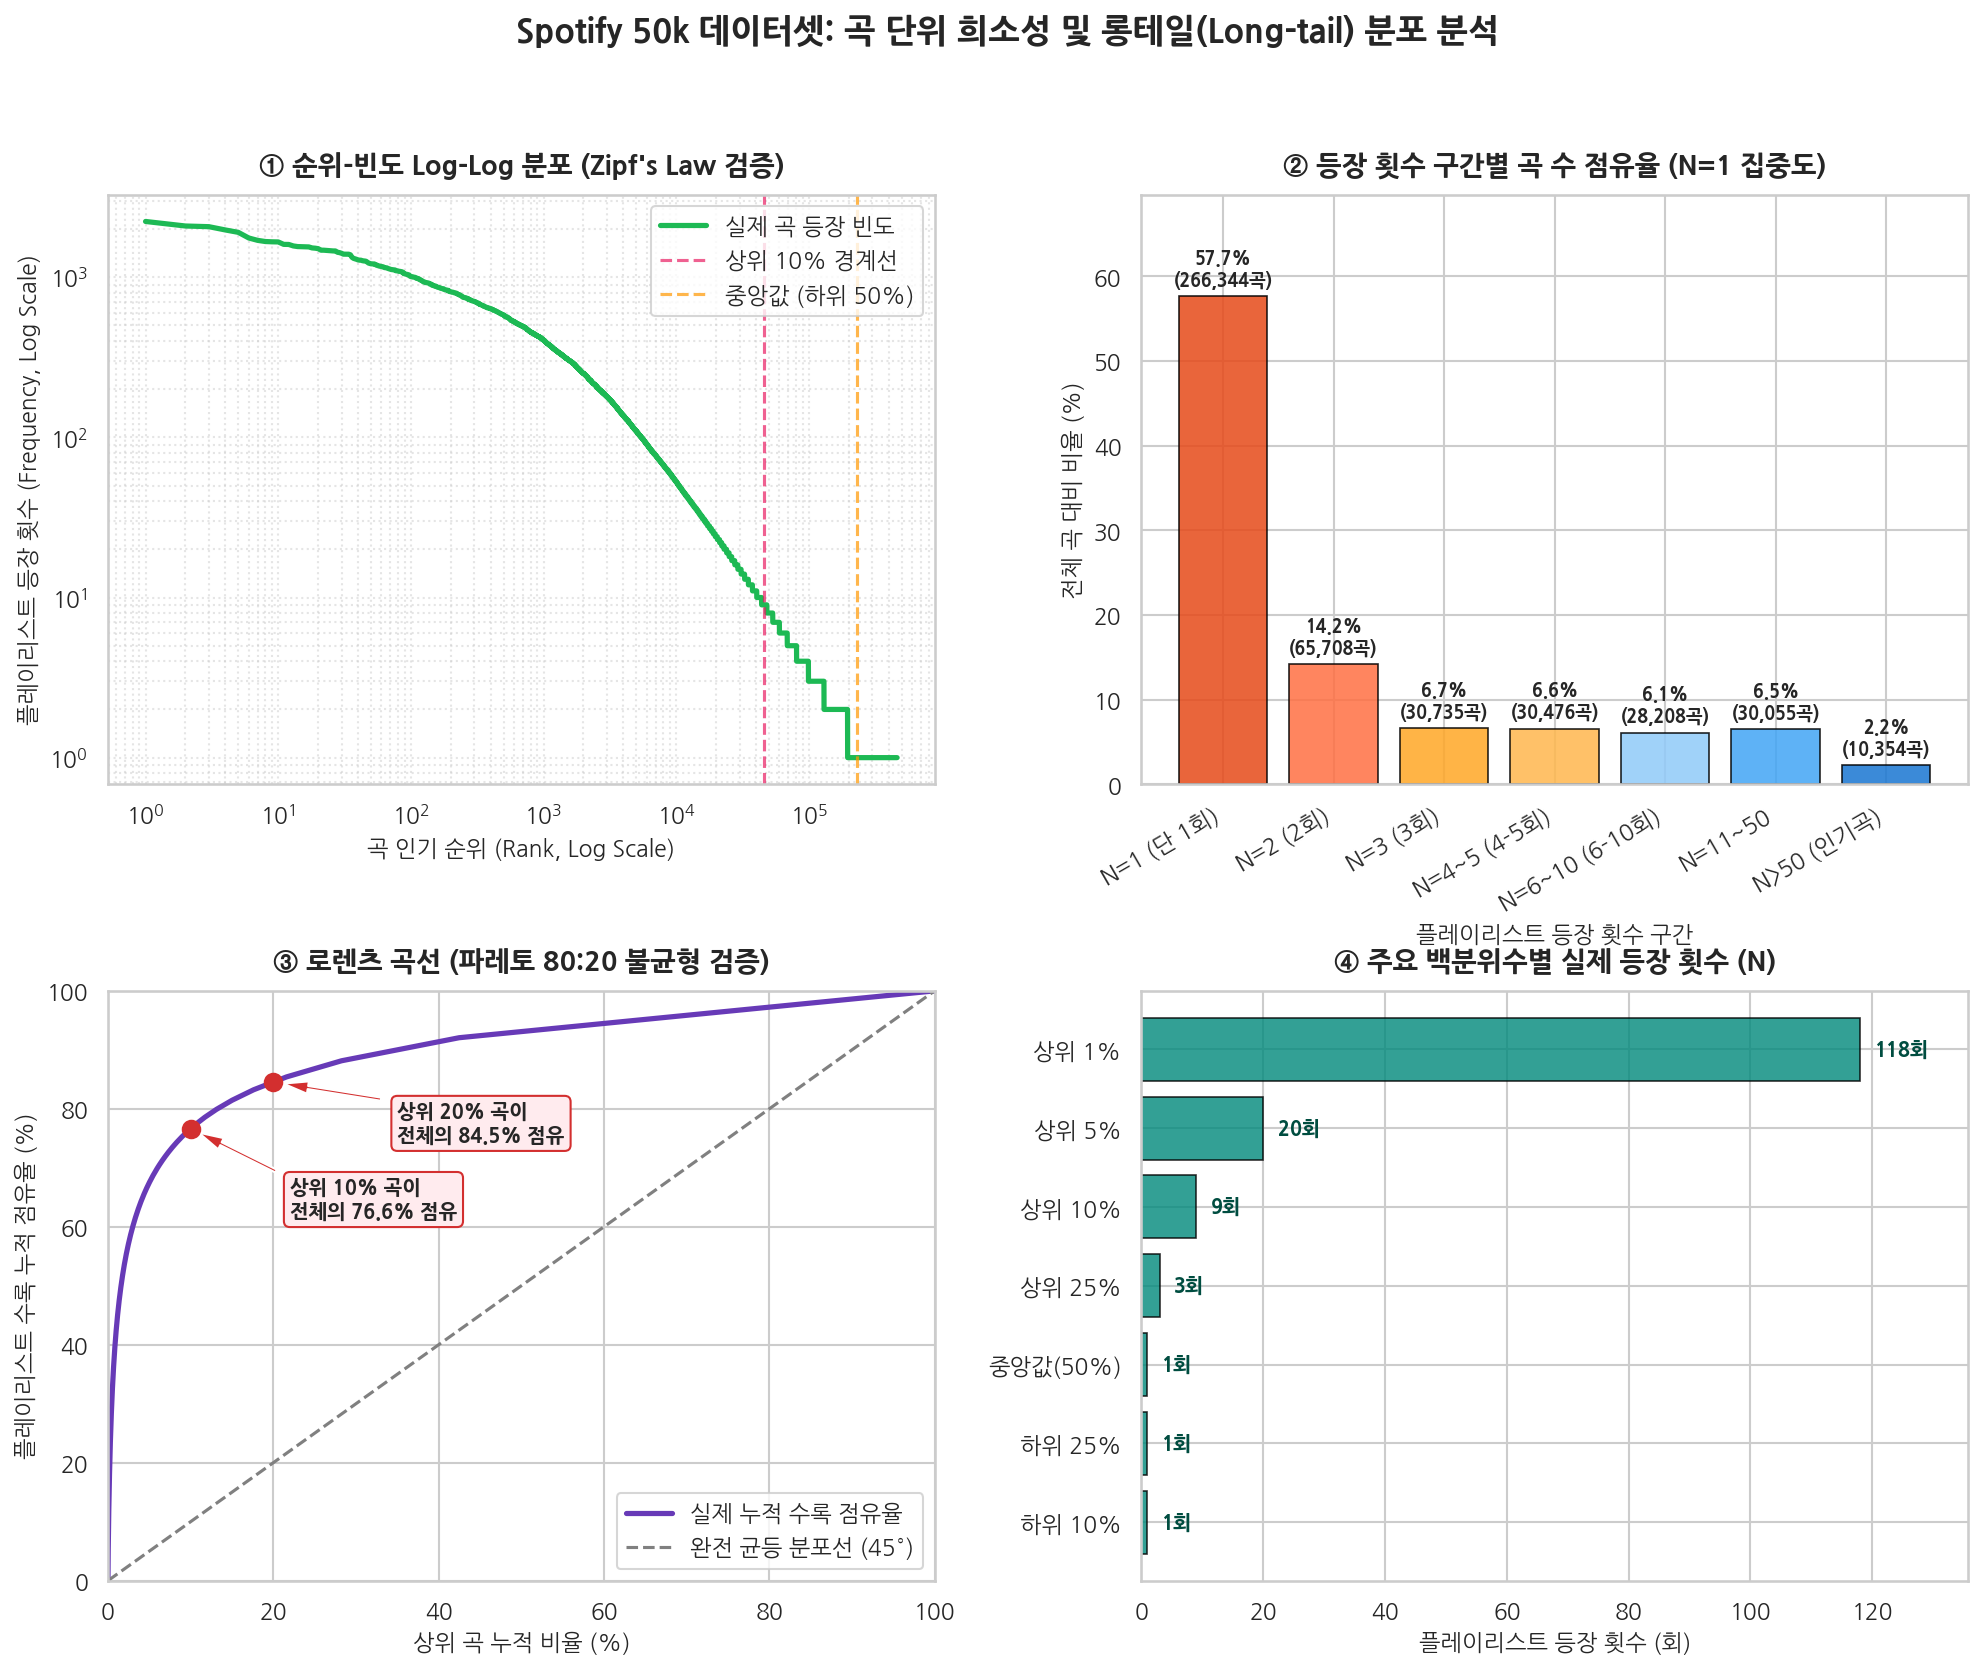


시각화 이미지 저장 완료: /content/spotify_longtail_distribution.png


In [ ]:
# 1. 한글 폰트 라이브러리 설치 및 임포트
!pip install -q koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import koreanize_matplotlib

# 스타일 설정
sns.set_theme(style="whitegrid", font="NanumGothic")
plt.rcParams['figure.dpi'] = 150

# 2. 데이터 로드 및 곡별 빈도 집계
parquet_path = Path("sample_50k_flat.parquet")
print("데이터 로드 및 빈도 집계 중...")
df = pd.read_parquet(parquet_path, columns=["pid", "track_uri"])

track_counts = df["track_uri"].value_counts().values
total_tracks = len(track_counts)
total_interactions = len(df)

# ==============================================================================
# [시각화] 2x2 종합 롱테일 진단 대시보드
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ------------------------------------------------------------------------------
# (1) [좌상단] Log-Log Rank-Frequency 곡선 (지프의 법칙 / Power Law 검증)
# ------------------------------------------------------------------------------
ax1 = axes[0, 0]
ranks = np.arange(1, total_tracks + 1)
ax1.plot(ranks, track_counts, color="#1DB954", linewidth=2.5, label="실제 곡 등장 빈도")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title("① 순위-빈도 Log-Log 분포 (Zipf's Law 검증)", fontsize=13, fontweight="bold", pad=10)
ax1.set_xlabel("곡 인기 순위 (Rank, Log Scale)", fontsize=11)
ax1.set_ylabel("플레이리스트 등장 횟수 (Frequency, Log Scale)", fontsize=11)
ax1.axvline(x=total_tracks * 0.1, color="#E91E63", linestyle="--", alpha=0.7, label="상위 10% 경계선")
ax1.axvline(x=total_tracks * 0.5, color="#FF9800", linestyle="--", alpha=0.7, label="중앙값 (하위 50%)")
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, which="both", ls=":", alpha=0.5)

# ------------------------------------------------------------------------------
# (2) [우상단] 등장 횟수(Frequency) 구간별 곡 수 비율 (N=1 극단성 강조)
# ------------------------------------------------------------------------------
ax2 = axes[0, 1]
bins_def = [
    ("N=1 (단 1회)", (track_counts == 1).sum()),
    ("N=2 (2회)", (track_counts == 2).sum()),
    ("N=3 (3회)", (track_counts == 3).sum()),
    ("N=4~5 (4-5회)", ((track_counts >= 4) & (track_counts <= 5)).sum()),
    ("N=6~10 (6-10회)", ((track_counts >= 6) & (track_counts <= 10)).sum()),
    ("N=11~50", ((track_counts >= 11) & (track_counts <= 50)).sum()),
    ("N>50 (인기곡)", (track_counts > 50).sum()),
]

labels = [b[0] for b in bins_def]
counts = [b[1] for b in bins_def]
percentages = [c / total_tracks * 100 for c in counts]

colors = ["#E64A19", "#FF7043", "#FFA726", "#FFB74D", "#90CAF9", "#42A5F5", "#1976D2"]
bars = ax2.bar(labels, percentages, color=colors, edgecolor="black", linewidth=0.8, alpha=0.85)

ax2.set_title("② 등장 횟수 구간별 곡 수 점유율 (N=1 집중도)", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("플레이리스트 등장 횟수 구간", fontsize=11)
ax2.set_ylabel("전체 곡 대비 비율 (%)", fontsize=11)
ax2.set_xticklabels(labels, rotation=30, ha="right")

# 바 위에 수치 표기
for bar, pct, cnt in zip(bars, percentages, counts):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f"{pct:.1f}%\n({cnt:,}곡)",
             ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax2.set_ylim(0, max(percentages) + 12)

# ------------------------------------------------------------------------------
# (3) [좌하단] 로렌츠 곡선 & 파레토 법칙 (인기곡 점유 집중도)
# ------------------------------------------------------------------------------
ax3 = axes[1, 0]
# 누적 곡 비율 vs 누적 인터랙션 점유율
cum_tracks_pct = np.linspace(0, 100, len(track_counts))
cum_interactions_pct = np.cumsum(track_counts) / total_interactions * 100

ax3.plot(cum_tracks_pct, cum_interactions_pct, color="#673AB7", linewidth=2.5, label="실제 누적 수록 점유율")
ax3.plot([0, 100], [0, 100], color="grey", linestyle="--", label="완전 균등 분포선 (45°)")

# 상위 10%, 20% 지점 강조
idx_10 = int(total_tracks * 0.10)
idx_20 = int(total_tracks * 0.20)
val_10 = cum_interactions_pct[idx_10]
val_20 = cum_interactions_pct[idx_20]

ax3.scatter([10, 20], [val_10, val_20], color="#D32F2F", s=70, zorder=5)
ax3.annotate(f"상위 10% 곡이\n전체의 {val_10:.1f}% 점유", xy=(10, val_10), xytext=(22, val_10 - 15),
             arrowprops=dict(facecolor="#D32F2F", shrink=0.08, width=1.5, headwidth=6),
             fontsize=9.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="#FFEBEE", ec="#D32F2F"))
ax3.annotate(f"상위 20% 곡이\n전체의 {val_20:.1f}% 점유", xy=(20, val_20), xytext=(35, val_20 - 10),
             arrowprops=dict(facecolor="#D32F2F", shrink=0.08, width=1.5, headwidth=6),
             fontsize=9.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="#FFEBEE", ec="#D32F2F"))

ax3.set_title("③ 로렌츠 곡선 (파레토 80:20 불균형 검증)", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("상위 곡 누적 비율 (%)", fontsize=11)
ax3.set_ylabel("플레이리스트 수록 누적 점유율 (%)", fontsize=11)
ax3.legend(loc="lower right", frameon=True)
ax3.set_xlim(0, 100)
ax3.set_ylim(0, 100)

# ------------------------------------------------------------------------------
# (4) [우하단] 주요 분위수(Percentiles)별 등장 횟수
# ------------------------------------------------------------------------------
ax4 = axes[1, 1]
pct_keys = [10, 25, 50, 75, 90, 95, 99]
pct_names = ["하위 10%", "하위 25%", "중앙값(50%)", "상위 25%", "상위 10%", "상위 5%", "상위 1%"]
pct_vals = np.percentile(track_counts[::-1], pct_keys)  # 오름차순 기준

bars4 = ax4.barh(pct_names, pct_vals, color="#00897B", edgecolor="black", linewidth=0.8, alpha=0.8)
ax4.set_title("④ 주요 백분위수별 실제 등장 횟수 (N)", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("플레이리스트 등장 횟수 (회)", fontsize=11)
ax4.set_xlim(0, max(pct_vals) * 1.15)

for bar, v in zip(bars4, pct_vals):
    xval = bar.get_width()
    ax4.text(xval + (max(pct_vals)*0.02), bar.get_y() + bar.get_height()/2.0, f"{int(v)}회",
             va="center", ha="left", fontsize=9.5, fontweight="bold", color="#004D40")

# 전체 레이아웃 저장 및 출력
plt.suptitle("Spotify 50k 데이터셋: 곡 단위 희소성 및 롱테일(Long-tail) 분포 분석", fontsize=16, fontweight="bold", y=0.98)
save_img_path = "/content/spotify_longtail_distribution.png"
plt.savefig(save_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n시각화 이미지 저장 완료: {save_img_path}")

=== TPO 결손율 분석 데이터 로드 중... ===
총 분석 대상 곡 수: 461,880개


/tmp/ipykernel_440/3441944177.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(tier_names, rotation=20, ha="right")


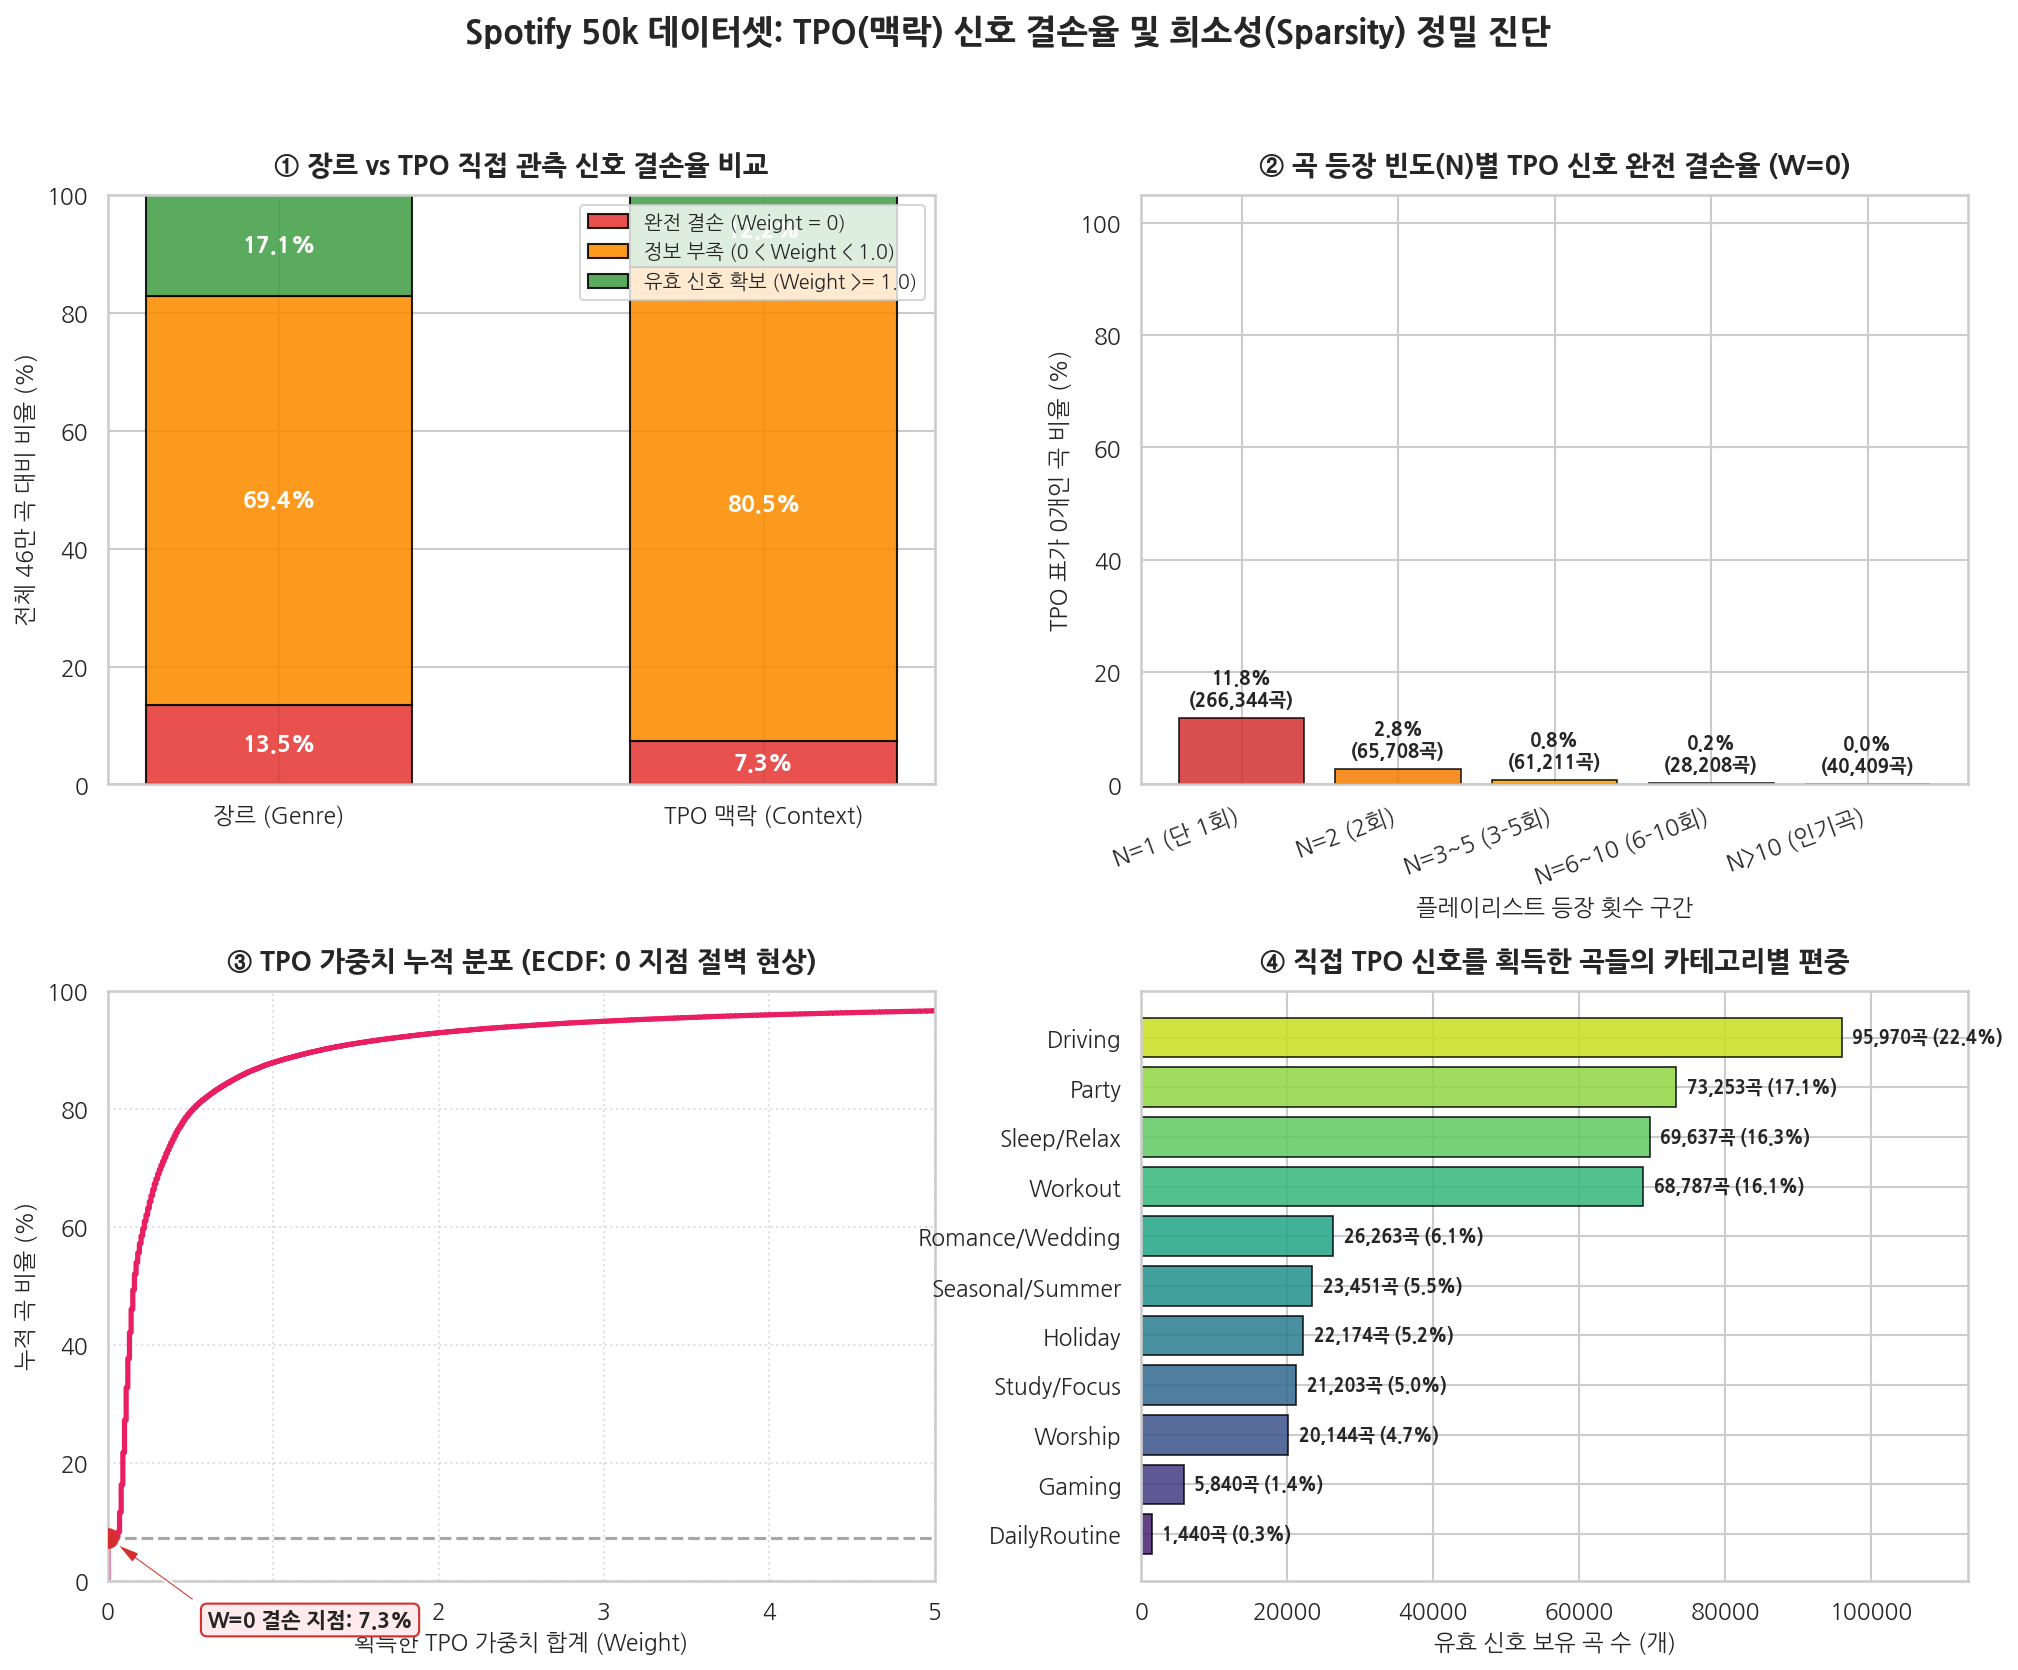


📊 TPO 결손율 시각화 이미지 저장 완료: /content/tpo_sparsity_diagnosis.png


In [ ]:
# 1. 한글 폰트 라이브러리 설치 및 임포트
!pip install -q koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import koreanize_matplotlib

# 스타일 설정
sns.set_theme(style="whitegrid", font="NanumGothic")
plt.rcParams['figure.dpi'] = 150

# ==============================================================================
# [1] 데이터 로드 및 결손율 지표 집계
# ==============================================================================
print("=== TPO 결손율 분석 데이터 로드 중... ===")
profile_path = Path("results_track_profiles/track_2d_profiles.parquet")
flat_path = Path("sample_50k_flat.parquet")

profile_df = pd.read_parquet(profile_path, columns=["track_uri", "genre_weight_sum", "tpo_weight_sum", "top_tpo"])
flat_df = pd.read_parquet(flat_path, columns=["track_uri"])

# 곡별 등장 횟수(Frequency) 매핑
track_counts = flat_df["track_uri"].value_counts()
profile_df["freq"] = profile_df["track_uri"].map(track_counts).fillna(0).astype(int)
total_tracks = len(profile_df)

print(f"총 분석 대상 곡 수: {total_tracks:,}개")

# ==============================================================================
# [2] 2x2 TPO 결손율 정밀 진단 대시보드 시각화
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ------------------------------------------------------------------------------
# (1) [좌상단] 장르 vs TPO 직접 관측 신호 신뢰도 3단계 비교 (The Signal Gap)
# ------------------------------------------------------------------------------
ax1 = axes[0, 0]

def categorize_signal(weights):
    zero_pct = (weights == 0).mean() * 100
    weak_pct = ((weights > 0) & (weights < 1.0)).mean() * 100
    solid_pct = (weights >= 1.0).mean() * 100
    return [zero_pct, weak_pct, solid_pct]

genre_ratios = categorize_signal(profile_df["genre_weight_sum"])
tpo_ratios = categorize_signal(profile_df["tpo_weight_sum"])

categories = ["장르 (Genre)", "TPO 맥락 (Context)"]
data_matrix = np.array([genre_ratios, tpo_ratios]) # [Zero, Weak, Solid]

colors = ["#E53935", "#FB8C00", "#43A047"]
labels = ["완전 결손 (Weight = 0)", "정보 부족 (0 < Weight < 1.0)", "유효 신호 확보 (Weight >= 1.0)"]

bottom = np.zeros(2)
for i in range(3):
    values = data_matrix[:, i]
    bars = ax1.bar(categories, values, bottom=bottom, color=colors[i], label=labels[i], width=0.55, edgecolor="black", alpha=0.88)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3.0:
            y_pos = bottom[j] + val / 2
            ax1.text(bar.get_x() + bar.get_width() / 2, y_pos, f"{val:.1f}%",
                     ha="center", va="center", color="white", fontsize=11, fontweight="bold")
    bottom += values

ax1.set_title("① 장르 vs TPO 직접 관측 신호 결손율 비교", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("전체 46만 곡 대비 비율 (%)", fontsize=11)
ax1.set_ylim(0, 100)
ax1.legend(loc="upper right", frameon=True, fontsize=9.5)

# ------------------------------------------------------------------------------
# (2) [우상단] 곡 등장 빈도(N) 구간별 TPO 완전 결손율 (W=0)
# ------------------------------------------------------------------------------
ax2 = axes[0, 1]

bins = [
    ("N=1 (단 1회)", profile_df[profile_df["freq"] == 1]),
    ("N=2 (2회)", profile_df[profile_df["freq"] == 2]),
    ("N=3~5 (3-5회)", profile_df[(profile_df["freq"] >= 3) & (profile_df["freq"] <= 5)]),
    ("N=6~10 (6-10회)", profile_df[(profile_df["freq"] >= 6) & (profile_df["freq"] <= 10)]),
    ("N>10 (인기곡)", profile_df[profile_df["freq"] > 10])
]

tier_names = [b[0] for b in bins]
tpo_zero_rates = [(sub["tpo_weight_sum"] == 0).mean() * 100 for _, sub in bins]
tier_counts = [len(sub) for _, sub in bins]

colors_tpo = ["#D32F2F", "#F57C00", "#FFA000", "#1976D2", "#388E3C"]
bars2 = ax2.bar(tier_names, tpo_zero_rates, color=colors_tpo, edgecolor="black", linewidth=0.8, alpha=0.85)

ax2.set_title("② 곡 등장 빈도(N)별 TPO 신호 완전 결손율 (W=0)", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("플레이리스트 등장 횟수 구간", fontsize=11)
ax2.set_ylabel("TPO 표가 0개인 곡 비율 (%)", fontsize=11)
ax2.set_xticklabels(tier_names, rotation=20, ha="right")
ax2.set_ylim(0, 105)

for bar, rate, count in zip(bars2, tpo_zero_rates, tier_counts):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 1.5, f"{rate:.1f}%\n({count:,}곡)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

# ------------------------------------------------------------------------------
# (3) [좌하단] TPO 관측 가중치 누적 분포 (ECDF)
# ------------------------------------------------------------------------------
ax3 = axes[1, 0]

tpo_w_sorted = np.sort(profile_df["tpo_weight_sum"].values)
yvals = np.arange(1, len(tpo_w_sorted) + 1) / len(tpo_w_sorted) * 100

ax3.plot(tpo_w_sorted, yvals, color="#E91E63", linewidth=2.5, label="TPO 가중치 누적 분포")
ax3.set_xlim(0, 5.0)  # 가중치 0~5 구간 확대
ax3.set_ylim(0, 100)

zero_pct_val = (profile_df["tpo_weight_sum"] == 0).mean() * 100
ax3.axhline(y=zero_pct_val, color="gray", linestyle="--", alpha=0.7)
ax3.scatter([0], [zero_pct_val], color="#D32F2F", s=80, zorder=5)

ax3.annotate(f"W=0 결손 지점: {zero_pct_val:.1f}%", xy=(0, zero_pct_val), xytext=(0.6, zero_pct_val - 15),
             arrowprops=dict(facecolor="#D32F2F", shrink=0.08, width=1.5, headwidth=6),
             fontsize=10, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="#FFEBEE", ec="#D32F2F"))

ax3.set_title("③ TPO 가중치 누적 분포 (ECDF: 0 지점 절벽 현상)", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("획득한 TPO 가중치 합계 (Weight)", fontsize=11)
ax3.set_ylabel("누적 곡 비율 (%)", fontsize=11)
ax3.grid(True, linestyle=":", alpha=0.6)

# ------------------------------------------------------------------------------
# (4) [우하단] 11개 세부 TPO 카테고리별 유효 곡 수 분포 (불균형 확인)
# ------------------------------------------------------------------------------
ax4 = axes[1, 1]

# 유효 TPO 신호(W > 0)를 가진 곡들의 카테고리별 분포
valid_tpo_df = profile_df[profile_df["tpo_weight_sum"] > 0]
tpo_dist = valid_tpo_df["top_tpo"].value_counts()

tpo_colors = sns.color_palette("viridis", len(tpo_dist))
bars4 = ax4.barh(tpo_dist.index[::-1], tpo_dist.values[::-1], color=tpo_colors, edgecolor="black", linewidth=0.8, alpha=0.85)

ax4.set_title("④ 직접 TPO 신호를 획득한 곡들의 카테고리별 편중", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("유효 신호 보유 곡 수 (개)", fontsize=11)
ax4.set_xlim(0, max(tpo_dist.values) * 1.18)

for bar, v in zip(bars4, tpo_dist.values[::-1]):
    xval = bar.get_width()
    pct = v / len(valid_tpo_df) * 100
    ax4.text(xval + (max(tpo_dist.values) * 0.015), bar.get_y() + bar.get_height() / 2.0,
             f"{v:,}곡 ({pct:.1f}%)", va="center", ha="left", fontsize=8.5, fontweight="bold")

# ==============================================================================
# [3] 이미지 저장 및 출력
# ==============================================================================
plt.suptitle("Spotify 50k 데이터셋: TPO(맥락) 신호 결손율 및 희소성(Sparsity) 정밀 진단", fontsize=16, fontweight="bold", y=0.98)
save_img_path = "/content/tpo_sparsity_diagnosis.png"
plt.savefig(save_img_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n📊 TPO 결손율 시각화 이미지 저장 완료: {save_img_path}")

## Artist 파라미터 튜닝

### 정적 그리드 탐색

=== [1/3] 데이터 로드 및 NumPy 행렬화 사전 작업 ===
=== [2/3] 검증용 Ground Truth 데이터 매핑 ===
검증 대상 유효 플리 수: 4,013개

=== [3/3] 초고속 그리드 서치 실행 중 (49개 조합)... ===

[정적 그리드 서치 Top 10 최적 파라미터]
 M_artist  M_album  Genre_Acc(%)  Genre_LogLoss  TPO_Acc(%)  TPO_LogLoss  Combined_Score
      3.0      0.5         90.47         0.3736       48.92       1.5012           60.32
      5.0      0.5         90.52         0.3734       48.87       1.5010           60.32
      8.0      0.5         90.52         0.3732       48.82       1.5009           60.30
      2.0      0.5         90.47         0.3738       48.87       1.5014           60.29
      1.0      0.5         90.47         0.3742       48.87       1.5020           60.29
      1.0      1.0         90.47         0.3742       48.82       1.5030           60.26
      2.0      1.0         90.47         0.3738       48.82       1.5031           60.26
      0.5      1.0         90.47         0.3747       48.82       1.5033           60.25
      0.5      2.0         90

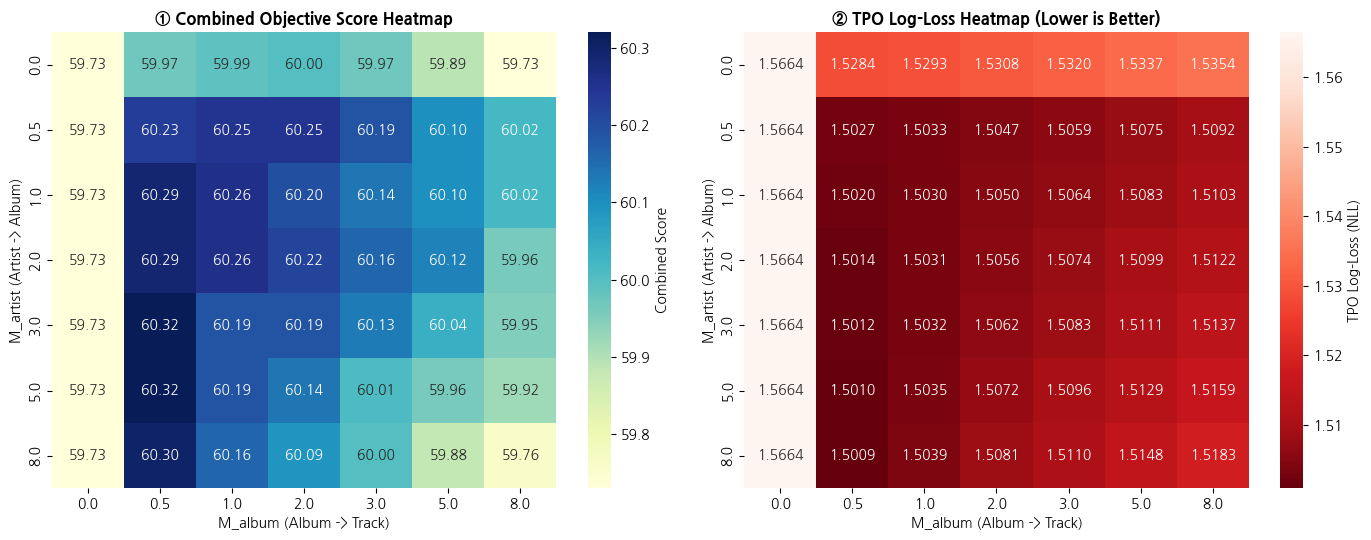


[최종 최적 정적 파라미터]: M_artist = 3.0, M_album = 0.5
   - TPO Log-Loss: 1.5012 | 장르 정확도: 90.47% | TPO 정확도: 48.92%


In [ ]:
from __future__ import annotations

from collections import defaultdict
from itertools import product
import math
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# [1] 경로 및 기본 설정
# ==============================================================================
TRAIN_PARQUET_PATH = Path("sample_50k_flat.parquet")
TRAIN_LABEL_PATH = (
    Path("results_2d_joint_profiling")
    / "50k_2d_joint_pseudo_labels.csv"
)
UNSEEN_PARQUET_PATH = Path("sample_unseen_20k_flat.parquet")
OUTPUT_DIR = Path("results_hyperparameter_tuning")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

NUM_GENRES = len(GENRE_CATEGORIES)
NUM_TPOS = len(TPO_CATEGORIES)
genre_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}
EPS = 1e-12

# ==============================================================================
# [2] 데이터 로드 및 정수 인덱스 매핑 (행렬 연산용)
# ==============================================================================
print("=== [1/3] 데이터 로드 및 NumPy 행렬화 사전 작업 ===")
tracks_df = pd.read_parquet(
    TRAIN_PARQUET_PATH, columns=["pid", "track_uri", "artist_uri", "album_uri"]
)
tracks_df["pid"] = tracks_df["pid"].astype(int)

# 고유 ID 정수 인덱싱
unique_tracks = sorted(tracks_df["track_uri"].unique().tolist())
unique_albums = sorted(tracks_df["album_uri"].unique().tolist())
unique_artists = sorted(tracks_df["artist_uri"].unique().tolist())

t_to_id = {u: i for i, u in enumerate(unique_tracks)}
al_to_id = {u: i for i, u in enumerate(unique_albums)}
ar_to_id = {u: i for i, u in enumerate(unique_artists)}

N_T, N_AL, N_AR = len(unique_tracks), len(unique_albums), len(unique_artists)

# 계층 인덱스 매핑 배열
meta_sub = tracks_df[
    ["track_uri", "album_uri", "artist_uri"]
].drop_duplicates()
t_alb_idx = np.zeros(N_T, dtype=np.int32)
al_art_idx = np.zeros(N_AL, dtype=np.int32)

for _, r in meta_sub.iterrows():
    tid = t_to_id[r["track_uri"]]
    alid = al_to_id[r["album_uri"]]
    arid = ar_to_id[r["artist_uri"]]
    t_alb_idx[tid] = alid
    al_art_idx[alid] = arid

# Raw 누적 행렬
raw_tr_g = np.zeros((N_T, NUM_GENRES), dtype=np.float32)
raw_tr_g_w = np.zeros(N_T, dtype=np.float32)
raw_tr_t = np.zeros((N_T, NUM_TPOS), dtype=np.float32)
raw_tr_t_w = np.zeros(N_T, dtype=np.float32)

raw_al_g = np.zeros((N_AL, NUM_GENRES), dtype=np.float32)
raw_al_g_w = np.zeros(N_AL, dtype=np.float32)
raw_al_t = np.zeros((N_AL, NUM_TPOS), dtype=np.float32)
raw_al_t_w = np.zeros(N_AL, dtype=np.float32)

raw_ar_g = np.zeros((N_AR, NUM_GENRES), dtype=np.float32)
raw_ar_g_w = np.zeros(N_AR, dtype=np.float32)
raw_ar_t = np.zeros((N_AR, NUM_TPOS), dtype=np.float32)
raw_ar_t_w = np.zeros(N_AR, dtype=np.float32)

pl_df = pd.read_csv(TRAIN_LABEL_PATH)
pid_to_genre = dict(
    zip(pl_df["pid"], zip(pl_df["pred_genre"], pl_df["genre_confidence"]))
)
pid_to_tpo = dict(
    zip(pl_df["pid"], zip(pl_df["pred_tpo"], pl_df["tpo_confidence"]))
)

for _, row in tracks_df.drop_duplicates(
    subset=["pid", "track_uri"]
).iterrows():
    pid = int(row["pid"])
    tid = t_to_id[str(row["track_uri"])]
    alid = t_alb_idx[tid]
    arid = al_art_idx[alid]

    if pid in pid_to_genre:
        g, conf = pid_to_genre[pid]
        if pd.notna(g) and g in genre_to_idx and conf > 0:
            idx, w = genre_to_idx[g], float(conf)
            raw_tr_g[tid, idx] += w
            raw_tr_g_w[tid] += w
            raw_al_g[alid, idx] += w
            raw_al_g_w[alid] += w
            raw_ar_g[arid, idx] += w
            raw_ar_g_w[arid] += w

    if pid in pid_to_tpo:
        t_val, conf = pid_to_tpo[pid]
        if pd.notna(t_val) and t_val in tpo_to_idx and conf > 0:
            idx, w = tpo_to_idx[t_val], float(conf)
            raw_tr_t[tid, idx] += w
            raw_tr_t_w[tid] += w
            raw_al_t[alid, idx] += w
            raw_al_t_w[alid] += w
            raw_ar_t[arid, idx] += w
            raw_ar_t_w[arid] += w

# 아티스트 기본 프로필 계산 (행렬)
global_g = np.ones((1, NUM_GENRES), dtype=np.float32) / NUM_GENRES
global_t = np.ones((1, NUM_TPOS), dtype=np.float32) / NUM_TPOS

art_g_p = np.where(
    raw_ar_g_w[:, None] > 0, raw_ar_g / (raw_ar_g_w[:, None] + EPS), global_g
)
art_t_p = np.where(
    raw_ar_t_w[:, None] > 0, raw_ar_t / (raw_ar_t_w[:, None] + EPS), global_t
)

# ==============================================================================
# [3] 검증용 Unseen 데이터 사전 인덱싱 (초고속 평가용)
# ==============================================================================
print("=== [2/3] 검증용 Ground Truth 데이터 매핑 ===")
unseen_df = pd.read_parquet(
    UNSEEN_PARQUET_PATH, columns=["pid", "name", "track_uri"]
)
unseen_df["pid"] = unseen_df["pid"].astype(int)

genre_rules = {
    "rock": "Rock",
    "hip hop": "HipHop",
    "rap": "HipHop",
    "country": "Country",
    "classical": "Classical",
    "jazz": "Jazz",
    "edm": "EDM",
    "pop": "Pop",
    "r&b": "RnB_Soul",
    "soul": "RnB_Soul",
}
tpo_rules = {
    "workout": "Workout",
    "gym": "Workout",
    "party": "Party",
    "driving": "Driving",
    "road trip": "Driving",
    "sleep": "Sleep/Relax",
    "relax": "Sleep/Relax",
    "study": "Study/Focus",
    "focus": "Study/Focus",
    "wedding": "Romance/Wedding",
    "summer": "Seasonal/Summer",
    "christmas": "Holiday",
    "gaming": "Gaming",
    "worship": "Worship",
}

val_records = []
for pid, grp in unseen_df.groupby("pid"):
    name = str(grp["name"].iloc[0]).lower()
    g_target = next((genre_to_idx[v] for k, v in genre_rules.items() if k in name), -1)
    t_target = next((tpo_to_idx[v] for k, v in tpo_rules.items() if k in name), -1)

    if g_target != -1 or t_target != -1:
        # 50k 장부에 존재하는 트랙 ID들만 추출
        t_ids = [t_to_id[t] for t in grp["track_uri"] if t in t_to_id]
        if len(t_ids) > 0:
            val_records.append((np.array(t_ids, dtype=np.int32), g_target, t_target))

print(f"검증 대상 유효 플리 수: {len(val_records):,}개")

# ==============================================================================
# [4] 초고속 그리드 서치 실행 (NumPy Matrix 연산)
# ==============================================================================
print("\n=== [3/3] 초고속 그리드 서치 실행 중 (49개 조합)... ===")
m_artist_candidates = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
m_album_candidates = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0]

grid_results = []

for m_art, m_alb in product(m_artist_candidates, m_album_candidates):
    # 1. 앨범 스무딩 (전체 앨범 일괄 행렬 연산: ~0.002초)
    ar_g_expanded = art_g_p[al_art_idx]
    ar_t_expanded = art_t_p[al_art_idx]

    alb_g_p = (raw_al_g + m_art * ar_g_expanded) / (
        raw_al_g_w[:, None] + m_art + EPS
    )
    alb_g_p = alb_g_p / (alb_g_p.sum(axis=1, keepdims=True) + EPS)

    alb_t_p = (raw_al_t + m_art * ar_t_expanded) / (
        raw_al_t_w[:, None] + m_art + EPS
    )
    alb_t_p = alb_t_p / (alb_t_p.sum(axis=1, keepdims=True) + EPS)

    # 2. 트랙 스무딩 (전체 46만 곡 일괄 행렬 연산: ~0.01초)
    alb_g_expanded = alb_g_p[t_alb_idx]
    alb_t_expanded = alb_t_p[t_alb_idx]

    trk_g_p = (raw_tr_g + m_alb * alb_g_expanded) / (
        raw_tr_g_w[:, None] + m_alb + EPS
    )
    trk_g_p = trk_g_p / (trk_g_p.sum(axis=1, keepdims=True) + EPS)

    trk_t_p = (raw_tr_t + m_alb * alb_t_expanded) / (
        raw_tr_t_w[:, None] + m_alb + EPS
    )
    trk_t_p = trk_t_p / (trk_t_p.sum(axis=1, keepdims=True) + EPS)

    # 3. 검증 셋 평가 (C-배열 슬라이싱으로 고속 집계: ~0.15초)
    g_corr, g_tot, g_loss = 0, 0, 0.0
    t_corr, t_tot, t_loss = 0, 0, 0.0

    for t_ids, g_idx, t_idx in val_records:
        if g_idx != -1:
            gp = trk_g_p[t_ids].mean(axis=0)
            gp = gp / gp.sum()
            if np.argmax(gp) == g_idx:
                g_corr += 1
            g_loss -= math.log(max(gp[g_idx], EPS))
            g_tot += 1

        if t_idx != -1:
            tp = trk_t_p[t_ids].mean(axis=0)
            tp = tp / tp.sum()
            if np.argmax(tp) == t_idx:
                t_corr += 1
            t_loss -= math.log(max(tp[t_idx], EPS))
            t_tot += 1

    g_acc = round(g_corr / g_tot * 100, 2) if g_tot > 0 else 0.0
    t_acc = round(t_corr / t_tot * 100, 2) if t_tot > 0 else 0.0
    g_nll = round(g_loss / g_tot, 4) if g_tot > 0 else 99.0
    t_nll = round(t_loss / t_tot, 4) if t_tot > 0 else 99.0
    comb_score = round(0.5 * g_acc + 0.5 * t_acc - 5.0 * (g_nll + t_nll), 2)

    grid_results.append(
        {
            "M_artist": m_art,
            "M_album": m_alb,
            "Genre_Acc(%)": g_acc,
            "Genre_LogLoss": g_nll,
            "TPO_Acc(%)": t_acc,
            "TPO_LogLoss": t_nll,
            "Combined_Score": comb_score,
        }
    )

res_df = (
    pd.DataFrame(grid_results)
    .sort_values(by="Combined_Score", ascending=False)
    .reset_index(drop=True)
)

# ==============================================================================
# [5] 결과 출력 및 시각화
# ==============================================================================
res_df.to_csv(
    OUTPUT_DIR / "hierarchical_grid_search_results.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\n" + "=" * 85)
print("[정적 그리드 서치 Top 10 최적 파라미터]")
print("=" * 85)
print(res_df.head(10).to_string(index=False))
print("=" * 85)

# 히트맵 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
pivot_score = res_df.pivot(
    index="M_artist", columns="M_album", values="Combined_Score"
)
pivot_loss = res_df.pivot(
    index="M_artist", columns="M_album", values="TPO_LogLoss"
)

sns.heatmap(
    pivot_score,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[0],
    cbar_kws={"label": "Combined Score"},
)
axes[0].set_title(
    "① Combined Objective Score Heatmap", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("M_album (Album -> Track)", fontsize=10)
axes[0].set_ylabel("M_artist (Artist -> Album)", fontsize=10)

sns.heatmap(
    pivot_loss,
    annot=True,
    fmt=".4f",
    cmap="Reds_r",
    ax=axes[1],
    cbar_kws={"label": "TPO Log-Loss (NLL)"},
)
axes[1].set_title(
    "② TPO Log-Loss Heatmap (Lower is Better)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("M_album (Album -> Track)", fontsize=10)
axes[1].set_ylabel("M_artist (Artist -> Album)", fontsize=10)

plt.tight_layout()
heatmap_path = OUTPUT_DIR / "tuning_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

best = res_df.iloc[0]
print(
    f"\n[최종 최적 정적 파라미터]: M_artist = {best['M_artist']}, M_album = {best['M_album']}"
)
print(
    f"   - TPO Log-Loss: {best['TPO_LogLoss']} | 장르 정확도: {best['Genre_Acc(%)']}% | TPO 정확도: {best['TPO_Acc(%)']}%"
)

In [ ]:
from __future__ import annotations

from itertools import product
import math
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# [1] 데이터 로드 및 NumPy 정수 인덱스 사전 매핑
# ==============================================================================
print("=== [1/3] 데이터 및 NumPy 행렬화 적재 ===")
TRAIN_PARQUET_PATH = Path("sample_50k_flat.parquet")
TRAIN_LABEL_PATH = (
    Path("results_2d_joint_profiling")
    / "50k_2d_joint_pseudo_labels.csv"
)
UNSEEN_PARQUET_PATH = Path("sample_unseen_20k_flat.parquet")
OUTPUT_DIR = Path("results_fair_ablation_benchmark")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

NUM_GENRES, NUM_TPOS = len(GENRE_CATEGORIES), len(TPO_CATEGORIES)
genre_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}
EPS = 1e-12

tracks_df = pd.read_parquet(
    TRAIN_PARQUET_PATH, columns=["pid", "track_uri", "artist_uri", "album_uri"]
)
tracks_df["pid"] = tracks_df["pid"].astype(int)

unique_tracks = sorted(tracks_df["track_uri"].unique().tolist())
unique_albums = sorted(tracks_df["album_uri"].unique().tolist())
unique_artists = sorted(tracks_df["artist_uri"].unique().tolist())

t_to_id = {u: i for i, u in enumerate(unique_tracks)}
al_to_id = {u: i for i, u in enumerate(unique_albums)}
ar_to_id = {u: i for i, u in enumerate(unique_artists)}
N_T, N_AL, N_AR = len(unique_tracks), len(unique_albums), len(unique_artists)

# 트랙 빈도 및 매핑 배열
t_counts_arr = np.zeros(N_T, dtype=np.float32)
vc = tracks_df["track_uri"].value_counts()
for u, count in vc.items():
    t_counts_arr[t_to_id[u]] = count

meta_sub = tracks_df[
    ["track_uri", "album_uri", "artist_uri"]
].drop_duplicates()
t_alb_idx = np.zeros(N_T, dtype=np.int32)
al_art_idx = np.zeros(N_AL, dtype=np.int32)
for _, r in meta_sub.iterrows():
    tid, alid, arid = (
        t_to_id[r["track_uri"]],
        al_to_id[r["album_uri"]],
        ar_to_id[r["artist_uri"]],
    )
    t_alb_idx[tid] = alid
    al_art_idx[alid] = arid

# Raw 관측치 행렬
raw_tr_g = np.zeros((N_T, NUM_GENRES), dtype=np.float32)
raw_tr_g_w = np.zeros(N_T, dtype=np.float32)
raw_tr_t = np.zeros((N_T, NUM_TPOS), dtype=np.float32)
raw_tr_t_w = np.zeros(N_T, dtype=np.float32)

raw_al_g = np.zeros((N_AL, NUM_GENRES), dtype=np.float32)
raw_al_g_w = np.zeros(N_AL, dtype=np.float32)
raw_al_t = np.zeros((N_AL, NUM_TPOS), dtype=np.float32)
raw_al_t_w = np.zeros(N_AL, dtype=np.float32)

raw_ar_g = np.zeros((N_AR, NUM_GENRES), dtype=np.float32)
raw_ar_g_w = np.zeros(N_AR, dtype=np.float32)
raw_ar_t = np.zeros((N_AR, NUM_TPOS), dtype=np.float32)
raw_ar_t_w = np.zeros(N_AR, dtype=np.float32)

pl_df = pd.read_csv(TRAIN_LABEL_PATH)
pid_to_genre = dict(
    zip(pl_df["pid"], zip(pl_df["pred_genre"], pl_df["genre_confidence"]))
)
pid_to_tpo = dict(
    zip(pl_df["pid"], zip(pl_df["pred_tpo"], pl_df["tpo_confidence"]))
)

for _, row in tracks_df.drop_duplicates(
    subset=["pid", "track_uri"]
).iterrows():
    pid = int(row["pid"])
    tid = t_to_id[str(row["track_uri"])]
    alid, arid = t_alb_idx[tid], al_art_idx[alid]

    if pid in pid_to_genre:
        g, conf = pid_to_genre[pid]
        if pd.notna(g) and g in genre_to_idx and conf > 0:
            idx, w = genre_to_idx[g], float(conf)
            raw_tr_g[tid, idx] += w
            raw_tr_g_w[tid] += w
            raw_al_g[alid, idx] += w
            raw_al_g_w[alid] += w
            raw_ar_g[arid, idx] += w
            raw_ar_g_w[arid] += w

    if pid in pid_to_tpo:
        t_val, conf = pid_to_tpo[pid]
        if pd.notna(t_val) and t_val in tpo_to_idx and conf > 0:
            idx, w = tpo_to_idx[t_val], float(conf)
            raw_tr_t[tid, idx] += w
            raw_tr_t_w[tid] += w
            raw_al_t[alid, idx] += w
            raw_al_t_w[alid] += w
            raw_ar_t[arid, idx] += w
            raw_ar_t_w[arid] += w

# 기본 아티스트 사전 확률 및 엔트로피 계산
global_g = np.ones((1, NUM_GENRES), dtype=np.float32) / NUM_GENRES
global_t = np.ones((1, NUM_TPOS), dtype=np.float32) / NUM_TPOS

art_g_p = np.where(
    raw_ar_g_w[:, None] > 0, raw_ar_g / (raw_ar_g_w[:, None] + EPS), global_g
)
art_t_p = np.where(
    raw_ar_t_w[:, None] > 0, raw_ar_t / (raw_ar_t_w[:, None] + EPS), global_t
)


def calc_arr_entropy(p_mat):
    safe_p = np.where(p_mat > 0, p_mat, 1.0)
    ent = -np.sum(p_mat * np.log(safe_p), axis=1) / np.log(p_mat.shape[1])
    return np.clip(ent, 0.0, 1.0)


art_g_ent = calc_arr_entropy(art_g_p)  # (N_AR,)
art_t_ent = calc_arr_entropy(art_t_p)  # (N_AR,)

# 검증 데이터셋 로드
unseen_df = pd.read_parquet(
    UNSEEN_PARQUET_PATH, columns=["pid", "name", "track_uri"]
)
genre_rules = {
    "rock": "Rock",
    "hip hop": "HipHop",
    "rap": "HipHop",
    "country": "Country",
    "classical": "Classical",
    "jazz": "Jazz",
    "edm": "EDM",
    "pop": "Pop",
    "r&b": "RnB_Soul",
    "soul": "RnB_Soul",
}
tpo_rules = {
    "workout": "Workout",
    "gym": "Workout",
    "party": "Party",
    "driving": "Driving",
    "road trip": "Driving",
    "sleep": "Sleep/Relax",
    "relax": "Sleep/Relax",
    "study": "Study/Focus",
    "focus": "Study/Focus",
    "wedding": "Romance/Wedding",
    "summer": "Seasonal/Summer",
    "christmas": "Holiday",
    "gaming": "Gaming",
    "worship": "Worship",
}

val_records = []
for pid, grp in unseen_df.groupby("pid"):
    name = str(grp["name"].iloc[0]).lower()
    g_target = next((genre_to_idx[v] for k, v in genre_rules.items() if k in name), -1)
    t_target = next((tpo_to_idx[v] for k, v in tpo_rules.items() if k in name), -1)
    if g_target != -1 or t_target != -1:
        t_ids = [t_to_id[t] for t in grp["track_uri"] if t in t_to_id]
        if len(t_ids) > 0:
            val_records.append((np.array(t_ids, dtype=np.int32), g_target, t_target))

# ==============================================================================
# [2] 통합 평가 함수 (초고속 NumPy 엔진)
# ==============================================================================


def evaluate_smoothing(m_art_g_arr, m_art_t_arr, m_alb_g_arr, m_alb_t_arr):
    # 앨범 스무딩
    ar_g_exp = art_g_p[al_art_idx]
    ar_t_exp = art_t_p[al_art_idx]

    alb_g = (raw_al_g + m_art_g_arr[:, None] * ar_g_exp) / (
        raw_al_g_w[:, None] + m_art_g_arr[:, None] + EPS
    )
    alb_g_p = alb_g / (alb_g.sum(axis=1, keepdims=True) + EPS)

    alb_t = (raw_al_t + m_art_t_arr[:, None] * ar_t_exp) / (
        raw_al_t_w[:, None] + m_art_t_arr[:, None] + EPS
    )
    alb_t_p = alb_t / (alb_t.sum(axis=1, keepdims=True) + EPS)

    # 트랙 스무딩
    alb_g_exp = alb_g_p[t_alb_idx]
    alb_t_exp = alb_t_p[t_alb_idx]

    trk_g = (raw_tr_g + m_alb_g_arr[:, None] * alb_g_exp) / (
        raw_tr_g_w[:, None] + m_alb_g_arr[:, None] + EPS
    )
    trk_g_p = trk_g / (trk_g.sum(axis=1, keepdims=True) + EPS)

    trk_t = (raw_tr_t + m_alb_t_arr[:, None] * alb_t_exp) / (
        raw_tr_t_w[:, None] + m_alb_t_arr[:, None] + EPS
    )
    trk_t_p = trk_t / (trk_t.sum(axis=1, keepdims=True) + EPS)

    # 검증셋 집계
    g_corr, g_tot, g_loss = 0, 0, 0.0
    t_corr, t_tot, t_loss = 0, 0, 0.0

    for t_ids, g_idx, t_idx in val_records:
        if g_idx != -1:
            gp = trk_g_p[t_ids].mean(axis=0)
            gp = gp / gp.sum()
            if np.argmax(gp) == g_idx:
                g_corr += 1
            g_loss -= math.log(max(gp[g_idx], EPS))
            g_tot += 1

        if t_idx != -1:
            tp = trk_t_p[t_ids].mean(axis=0)
            tp = tp / tp.sum()
            if np.argmax(tp) == t_idx:
                t_corr += 1
            t_loss -= math.log(max(tp[t_idx], EPS))
            t_tot += 1

    g_acc = round(g_corr / g_tot * 100, 2) if g_tot > 0 else 0.0
    t_acc = round(t_corr / t_tot * 100, 2) if t_tot > 0 else 0.0
    g_nll = round(g_loss / g_tot, 4) if g_tot > 0 else 99.0
    t_nll = round(t_loss / t_tot, 4) if t_tot > 0 else 99.0
    comb_score = round(0.5 * g_acc + 0.5 * t_acc - 5.0 * (g_nll + t_nll), 2)

    return {
        "Genre_Acc(%)": g_acc,
        "Genre_LogLoss": g_nll,
        "TPO_Acc(%)": t_acc,
        "TPO_LogLoss": t_nll,
        "Combined_Score": comb_score,
    }


# ==============================================================================
# [3] 전 Stage별 최적 파라미터 개별 탐색 (Fair Optimization)
# ==============================================================================
print("\n=== [2/3] 전 Stage별 최적화 탐색 (Fair Tuning) 시작 ===")
final_fair_results = []

# --- 1. Stage 0: Baseline (M=0) ---
print("• [1/5] Stage 0 (Baseline) 평가...")
base_res = evaluate_smoothing(
    np.zeros(N_AL, dtype=np.float32),
    np.zeros(N_AL, dtype=np.float32),
    np.zeros(N_T, dtype=np.float32),
    np.zeros(N_T, dtype=np.float32),
)
base_res.update(
    {
        "Stage": "Stage 0: Baseline",
        "Best Parameters": "M_art=0, M_alb=0",
        "Strategy Description": "순수 트랙 관측치만 사용",
    }
)
final_fair_results.append(base_res)

# --- 2. Stage 1: Static Fixed Tuning ---
print("• [2/5] Stage 1 (Static) 최적 파라미터 탐색...")
best_s1, best_s1_score = None, -999.0
for m_art, m_alb in product(
    [0.5, 1.0, 2.0, 3.0, 5.0, 8.0], [0.1, 0.3, 0.5, 1.0, 2.0]
):
    m_art_arr = np.full(N_AL, m_art, dtype=np.float32)
    m_alb_arr = np.full(N_T, m_alb, dtype=np.float32)
    res = evaluate_smoothing(m_art_arr, m_art_arr, m_alb_arr, m_alb_arr)
    if res["Combined_Score"] > best_s1_score:
        best_s1_score = res["Combined_Score"]
        best_s1 = res
        best_s1_params = f"M_art={m_art}, M_alb={m_alb}"
best_s1.update(
    {
        "Stage": "Stage 1: Static Optimal",
        "Best Parameters": best_s1_params,
        "Strategy Description": "고정 상수 일괄 최적화",
    }
)
final_fair_results.append(best_s1)

# --- 3. Stage 2-A: Dynamic (Entropy-Adaptive) Tuning ---
print("• [3/5] Stage 2-A (Entropy) 최적 파라미터 탐색...")
best_s2a, best_s2a_score = None, -999.0
al_g_ent = art_g_ent[al_art_idx]
al_t_ent = art_t_ent[al_art_idx]

for m0, gamma, m_alb in product(
    [2.0, 4.0, 6.0, 8.0], [1.0, 2.0], [0.1, 0.3, 0.5, 1.0]
):
    m_art_g = (m0 * ((1.0 - al_g_ent) ** gamma)).astype(np.float32)
    m_art_t = (m0 * ((1.0 - al_t_ent) ** gamma)).astype(np.float32)
    m_alb_arr = np.full(N_T, m_alb, dtype=np.float32)
    res = evaluate_smoothing(m_art_g, m_art_t, m_alb_arr, m_alb_arr)
    if res["Combined_Score"] > best_s2a_score:
        best_s2a_score = res["Combined_Score"]
        best_s2a = res
        best_s2a_params = f"M0={m0}, γ={gamma}, M_alb={m_alb}"
best_s2a.update(
    {
        "Stage": "Stage 2-A: Dynamic (Entropy)",
        "Best Parameters": best_s2a_params,
        "Strategy Description": "아티스트 순도 기반 동적 조절",
    }
)
final_fair_results.append(best_s2a)

# --- 4. Stage 2-B: Dynamic (Evidence-Adaptive) Tuning ---
print("• [4/5] Stage 2-B (Evidence) 최적 파라미터 탐색...")
best_s2b, best_s2b_score = None, -999.0
for m_art, c0 in product(
    [1.0, 3.0, 5.0], [0.3, 0.5, 0.8, 1.2, 2.0]
):
    m_art_arr = np.full(N_AL, m_art, dtype=np.float32)
    m_alb_arr = (c0 / np.sqrt(t_counts_arr + 1.0)).astype(np.float32)
    res = evaluate_smoothing(m_art_arr, m_art_arr, m_alb_arr, m_alb_arr)
    if res["Combined_Score"] > best_s2b_score:
        best_s2b_score = res["Combined_Score"]
        best_s2b = res
        best_s2b_params = f"M_art={m_art}, C0={c0}"
best_s2b.update(
    {
        "Stage": "Stage 2-B: Dynamic (Evidence)",
        "Best Parameters": best_s2b_params,
        "Strategy Description": "트랙 등장 빈도(N) 감쇠 조절",
    }
)
final_fair_results.append(best_s2b)

# --- 5. Stage 3: Hybrid Unified Framework Tuning ---
print("• [5/5] Stage 3 (Hybrid) 최적 파라미터 탐색...")
best_s3, best_s3_score = None, -999.0
for m0, gamma, c0 in product(
    [3.0, 5.0, 8.0], [1.0, 2.0], [0.3, 0.5, 0.8, 1.2]
):
    m_art_g = (m0 * ((1.0 - al_g_ent) ** gamma)).astype(np.float32)
    m_art_t = (m0 * ((1.0 - al_t_ent) ** gamma)).astype(np.float32)
    m_alb_arr = (c0 / np.sqrt(t_counts_arr + 1.0)).astype(np.float32)
    res = evaluate_smoothing(m_art_g, m_art_t, m_alb_arr, m_alb_arr)
    if res["Combined_Score"] > best_s3_score:
        best_s3_score = res["Combined_Score"]
        best_s3 = res
        best_s3_params = f"M0={m0}, γ={gamma}, C0={c0}"
best_s3.update(
    {
        "Stage": "Stage 3: Hybrid Unified (Final)",
        "Best Parameters": best_s3_params,
        "Strategy Description": "[엔트로피 순도] x [표본 감쇠] 결합",
    }
)
final_fair_results.append(best_s3)

# ==============================================================================
# [4] 공정 비교 결과표 출력 및 CSV 저장
# ==============================================================================
print("\n=== [3/3] 최종 공정 벤치마크 결과 집계 ===")
fair_df = pd.DataFrame(final_fair_results)
fair_df.to_csv(
    OUTPUT_DIR / "fair_ablation_benchmark_results.csv",
    index=False,
    encoding="utf-8-sig",
)

cols_show = [
    "Stage",
    "Best Parameters",
    "Genre_Acc(%)",
    "Genre_LogLoss",
    "TPO_Acc(%)",
    "TPO_LogLoss",
    "Combined_Score",
]
print("\n" + "=" * 110)
print("[전 Stage 개별 최적화 후 공정 비교 벤치마크 (Fair Ablation Study Table)]")
print("=" * 110)
print(fair_df[cols_show].to_string(index=False))
print("=" * 110)
print(f"결과 저장 완료: {OUTPUT_DIR / 'fair_ablation_benchmark_results.csv'}")

=== [1/3] 데이터 및 NumPy 행렬화 적재 ===

=== [2/3] 전 Stage별 최적화 탐색 (Fair Tuning) 시작 ===
• [1/5] Stage 0 (Baseline) 평가...
• [2/5] Stage 1 (Static) 최적 파라미터 탐색...
• [3/5] Stage 2-A (Entropy) 최적 파라미터 탐색...
• [4/5] Stage 2-B (Evidence) 최적 파라미터 탐색...
• [5/5] Stage 3 (Hybrid) 최적 파라미터 탐색...

=== [3/3] 최종 공정 벤치마크 결과 집계 ===

[전 Stage 개별 최적화 후 공정 비교 벤치마크 (Fair Ablation Study Table)]
                          Stage          Best Parameters  Genre_Acc(%)  Genre_LogLoss  TPO_Acc(%)  TPO_LogLoss  Combined_Score
              Stage 0: Baseline         M_art=0, M_alb=0         90.37         0.4169       48.92       1.5664           59.73
        Stage 1: Static Optimal     M_art=5.0, M_alb=0.5         90.52         0.3740       48.92       1.4987           60.36
   Stage 2-A: Dynamic (Entropy) M0=4.0, γ=1.0, M_alb=0.5         90.47         0.3750       48.92       1.4985           60.33
  Stage 2-B: Dynamic (Evidence)        M_art=5.0, C0=0.8         90.52         0.3742       48.92       1.4992           60.

### 4가지 model 실험

=== [1/4] 50k 데이터 로드 및 계층별 Raw 관측치 집계 ===


Aggregating Raw Counts: 100%|██████████| 3300244/3300244 [03:30<00:00, 15708.72it/s]



=== [2/4] 엔트로피 계산 및 검증용 Ground Truth 구축 ===
검증용 고순도 플리 수: 4,015개

=== [3/4] 4대 모델 단계별 벤치마크(Ablation Study) 실행 ===
• [1/5] Stage 0: Baseline (M=0) 평가 중...


/tmp/ipykernel_939/497652228.py:296: RuntimeWarning: invalid value encountered in divide
  gp = g_acc_vec / g_acc_vec.sum()


• [2/5] Stage 1: Static Fixed Smoothing (M_art=3.0, M_alb=0.5) 평가 중...
• [3/5] Stage 2-A: Dynamic (Entropy-Adaptive) 평가 중...
• [4/5] Stage 2-B: Dynamic (Evidence-Adaptive) 평가 중...
• [5/5] Stage 3: Hybrid Unified Framework 평가 중...

=== [4/4] 벤치마크 결과 집계 및 시각화 리포트 생성 ===

[4단계 하이퍼파라미터 평활화 벤치마크 결과 (Ablation Comparison Table)]
                          Stage  Genre_Acc(%)  Genre_LogLoss  TPO_Acc(%)  TPO_LogLoss  Combined_Score
              Stage 0: Baseline         90.37         0.4169       48.92       1.5664           59.73
          Stage 1: Static Fixed         90.52         0.3729       48.92       1.5008           60.35
   Stage 2-A: Dynamic (Entropy)         90.57         0.3750       48.62       1.5045           60.20
  Stage 2-B: Dynamic (Evidence)         90.52         0.3734       48.77       1.5053           60.25
Stage 3: Hybrid Unified (Final)         90.57         0.3748       48.72       1.5045           60.25


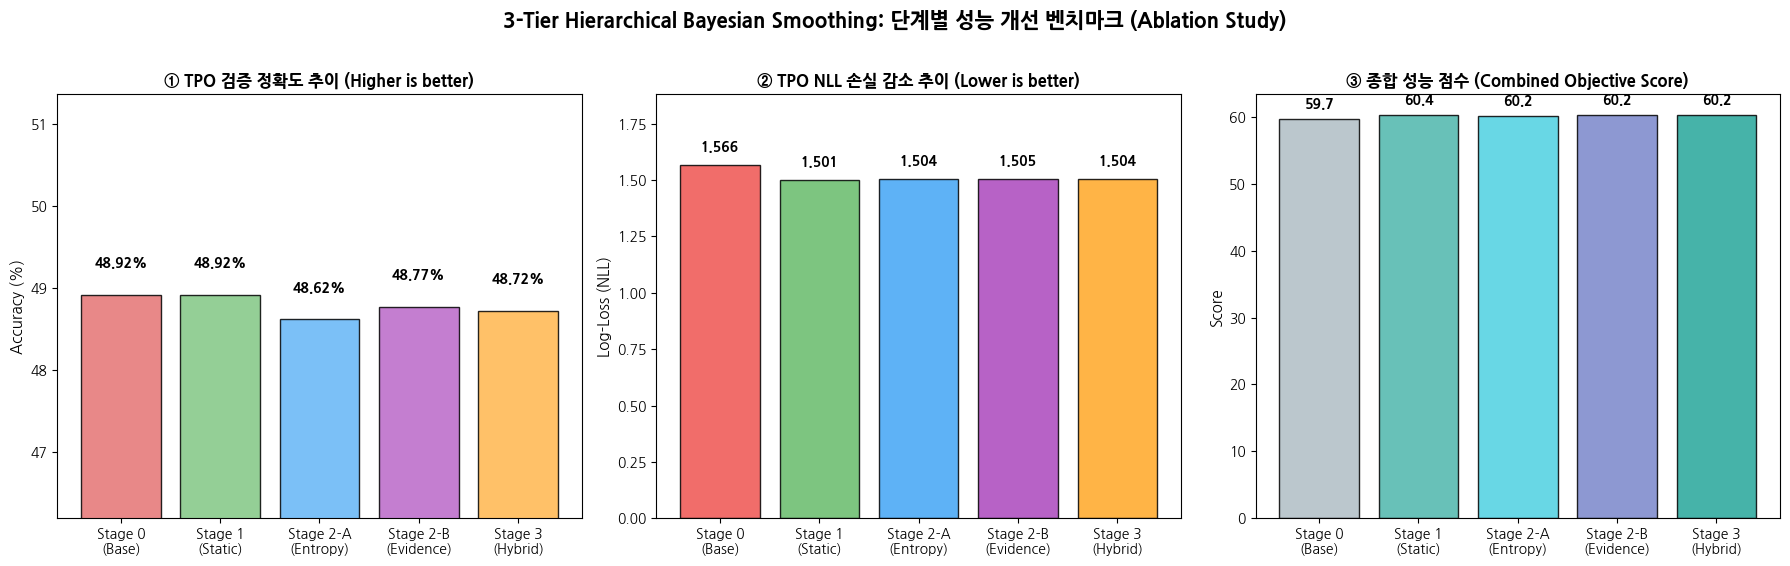


📊 벤치마크 대시보드 저장 완료: results_ablation_benchmark/ablation_benchmark_dashboard.png
📄 벤치마크 결과 CSV 저장 완료 : results_ablation_benchmark/ablation_benchmark_results.csv


In [ ]:
from __future__ import annotations

from collections import defaultdict
import math
import os
from pathlib import Path
import koreanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# ==============================================================================
# [1] 경로 및 기본 설정
# ==============================================================================
TRAIN_PARQUET_PATH = Path("sample_50k_flat.parquet")
TRAIN_LABEL_PATH = (
    Path("results_2d_joint_profiling")
    / "50k_2d_joint_pseudo_labels.csv"
)
UNSEEN_PARQUET_PATH = Path("sample_unseen_20k_flat.parquet")
OUTPUT_DIR = Path("results_ablation_benchmark")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

NUM_GENRES = len(GENRE_CATEGORIES)
NUM_TPOS = len(TPO_CATEGORIES)
genre_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}

global_g_prior = np.ones(NUM_GENRES) / NUM_GENRES
global_t_prior = np.ones(NUM_TPOS) / NUM_TPOS
EPS = 1e-12

# ==============================================================================
# [2] 50k 학습 데이터 로드 및 상향식 기초 관측치 집계
# ==============================================================================
print("=== [1/4] 50k 데이터 로드 및 계층별 Raw 관측치 집계 ===")
tracks_df = pd.read_parquet(
    TRAIN_PARQUET_PATH, columns=["pid", "track_uri", "artist_uri", "album_uri"]
)
tracks_df["pid"] = tracks_df["pid"].astype(int)

# 트랙별 등장 빈도(N_track) 계산
track_counts = tracks_df["track_uri"].value_counts().to_dict()

pl_df = pd.read_csv(TRAIN_LABEL_PATH)
pid_to_genre = dict(
    zip(pl_df["pid"], zip(pl_df["pred_genre"], pl_df["genre_confidence"]))
)
pid_to_tpo = dict(
    zip(pl_df["pid"], zip(pl_df["pred_tpo"], pl_df["tpo_confidence"]))
)

unique_meta = tracks_df[
    ["track_uri", "album_uri", "artist_uri"]
].drop_duplicates()
track_to_album = dict(zip(unique_meta["track_uri"], unique_meta["album_uri"]))
album_to_artist = dict(
    zip(unique_meta["album_uri"], unique_meta["artist_uri"])
)
track_to_artist = dict(
    zip(unique_meta["track_uri"], unique_meta["artist_uri"])
)

raw_tr_g = defaultdict(lambda: np.zeros(NUM_GENRES))
raw_tr_g_w = defaultdict(float)
raw_tr_t = defaultdict(lambda: np.zeros(NUM_TPOS))
raw_tr_t_w = defaultdict(float)

raw_al_g = defaultdict(lambda: np.zeros(NUM_GENRES))
raw_al_g_w = defaultdict(float)
raw_al_t = defaultdict(lambda: np.zeros(NUM_TPOS))
raw_al_t_w = defaultdict(float)

raw_ar_g = defaultdict(lambda: np.zeros(NUM_GENRES))
raw_ar_g_w = defaultdict(float)
raw_ar_t = defaultdict(lambda: np.zeros(NUM_TPOS))
raw_ar_t_w = defaultdict(float)

unique_pl_tracks = tracks_df.drop_duplicates(subset=["pid", "track_uri"])

for _, row in tqdm(
    unique_pl_tracks.iterrows(),
    total=len(unique_pl_tracks),
    desc="Aggregating Raw Counts",
):
    pid = int(row["pid"])
    t = str(row["track_uri"])
    al = track_to_album.get(t)
    ar = track_to_artist.get(t)

    # 장르 누적
    if pid in pid_to_genre:
        g_pred, g_conf = pid_to_genre[pid]
        if pd.notna(g_pred) and g_pred in genre_to_idx and g_conf > 0:
            idx = genre_to_idx[g_pred]
            w = float(g_conf)
            raw_tr_g[t][idx] += w
            raw_tr_g_w[t] += w
            raw_al_g[al][idx] += w
            raw_al_g_w[al] += w
            raw_ar_g[ar][idx] += w
            raw_ar_g_w[ar] += w

    # TPO 누적
    if pid in pid_to_tpo:
        t_pred, t_conf = pid_to_tpo[pid]
        if pd.notna(t_pred) and t_pred in tpo_to_idx and t_conf > 0:
            idx = tpo_to_idx[t_pred]
            w = float(t_conf)
            raw_tr_t[t][idx] += w
            raw_tr_t_w[t] += w
            raw_al_t[al][idx] += w
            raw_al_t_w[al] += w
            raw_ar_t[ar][idx] += w
            raw_ar_t_w[ar] += w

# ==============================================================================
# [3] 엔트로피(Entropy) 계산 및 검증 데이터셋 (Unseen 20k) 준비
# ==============================================================================
print("\n=== [2/4] 엔트로피 계산 및 검증용 Ground Truth 구축 ===")


def calc_norm_entropy(vec: np.ndarray) -> float:
    p = vec[vec > 0]
    if len(p) <= 1:
        return 0.0
    p = p / p.sum()
    return float(-np.sum(p * np.log(p)) / np.log(len(vec)))


all_artists = set(album_to_artist.values())
all_albums = set(album_to_artist.keys())
all_tracks = set(track_to_album.keys())

# 아티스트 및 앨범의 순수 관측 엔트로피 사전 계산
art_g_entropy = {}
art_t_entropy = {}
art_g_base_p = {}
art_t_base_p = {}

for ar in all_artists:
    gw = raw_ar_g_w[ar]
    gp = raw_ar_g[ar] / gw if gw > 0 else global_g_prior
    art_g_base_p[ar] = gp
    art_g_entropy[ar] = calc_norm_entropy(gp)

    tw = raw_ar_t_w[ar]
    tp = raw_ar_t[ar] / tw if tw > 0 else global_t_prior
    art_t_base_p[ar] = tp
    art_t_entropy[ar] = calc_norm_entropy(tp)

# 검증용 고순도 Ground Truth 플리 파싱
unseen_df = pd.read_parquet(
    UNSEEN_PARQUET_PATH, columns=["pid", "name", "track_uri"]
)
unseen_df["pid"] = unseen_df["pid"].astype(int)

genre_rules = {
    "rock": "Rock",
    "hip hop": "HipHop",
    "rap": "HipHop",
    "country": "Country",
    "classical": "Classical",
    "jazz": "Jazz",
    "edm": "EDM",
    "pop": "Pop",
    "r&b": "RnB_Soul",
    "soul": "RnB_Soul",
}
tpo_rules = {
    "workout": "Workout",
    "gym": "Workout",
    "party": "Party",
    "driving": "Driving",
    "road trip": "Driving",
    "sleep": "Sleep/Relax",
    "relax": "Sleep/Relax",
    "study": "Study/Focus",
    "focus": "Study/Focus",
    "wedding": "Romance/Wedding",
    "summer": "Seasonal/Summer",
    "christmas": "Holiday",
    "gaming": "Gaming",
    "worship": "Worship",
}

val_playlists = {}
for _, row in unseen_df[["pid", "name"]].drop_duplicates().iterrows():
    pid = int(row["pid"])
    name = str(row["name"]).lower()
    g_target = next((v for k, v in genre_rules.items() if k in name), None)
    t_target = next((v for k, v in tpo_rules.items() if k in name), None)
    if g_target or t_target:
        val_playlists[pid] = {"genre": g_target, "tpo": t_target}

val_pl_tracks = (
    unseen_df[unseen_df["pid"].isin(val_playlists.keys())]
    .groupby("pid")["track_uri"]
    .apply(list)
    .to_dict()
)
print(f"검증용 고순도 플리 수: {len(val_playlists):,}개")

# ==============================================================================
# [4] 4대 모델 평가 공통 함수 정의
# ==============================================================================


def evaluate_model_pipeline(
    model_name: str, strategy: str, m_art_func, m_alb_func
):
    # 1. 앨범 프로필 스무딩
    alb_g_p = {}
    alb_t_p = {}
    for al in all_albums:
        ar = album_to_artist[al]
        ar_gp = art_g_base_p[ar]
        ar_tp = art_t_base_p[ar]

        m_art_g = m_art_func(ar, "genre")
        m_art_t = m_art_func(ar, "tpo")

        # Genre
        sg = (raw_al_g[al] + m_art_g * ar_gp) / (raw_al_g_w[al] + m_art_g + EPS)
        alb_g_p[al] = sg / (sg.sum() + EPS)
        # TPO
        st = (raw_al_t[al] + m_art_t * ar_tp) / (raw_al_t_w[al] + m_art_t + EPS)
        alb_t_p[al] = st / (st.sum() + EPS)

    # 2. 트랙 최종 프로필 스무딩
    trk_g_p = {}
    trk_t_p = {}
    for t in all_tracks:
        al = track_to_album[t]
        al_gp = alb_g_p.get(al, global_g_prior)
        al_tp = alb_t_p.get(al, global_t_prior)

        m_alb_g = m_alb_func(t, al, "genre")
        m_alb_t = m_alb_func(t, al, "tpo")

        # Genre
        sg = (raw_tr_g[t] + m_alb_g * al_gp) / (raw_tr_g_w[t] + m_alb_g + EPS)
        trk_g_p[t] = sg / (sg.sum() + EPS)
        # TPO
        st = (raw_tr_t[t] + m_alb_t * al_tp) / (raw_tr_t_w[t] + m_alb_t + EPS)
        trk_t_p[t] = st / (st.sum() + EPS)

    # 3. Unseen 검증 셋 평가
    g_corr, g_tot, g_loss = 0, 0, 0.0
    t_corr, t_tot, t_loss = 0, 0, 0.0

    for pid, targets in val_playlists.items():
        tracks = val_pl_tracks.get(pid, [])
        if not tracks:
            continue

        g_acc_vec = np.zeros(NUM_GENRES)
        t_acc_vec = np.zeros(NUM_TPOS)
        hit_cnt = 0

        for t in tracks:
            if t in trk_g_p:
                g_acc_vec += trk_g_p[t]
                t_acc_vec += trk_t_p[t]
                hit_cnt += 1

        if hit_cnt == 0:
            continue

        gp = g_acc_vec / g_acc_vec.sum()
        tp = t_acc_vec / t_acc_vec.sum()

        if targets["genre"] is not None:
            c_idx = genre_to_idx[targets["genre"]]
            if np.argmax(gp) == c_idx:
                g_corr += 1
            g_loss -= math.log(max(gp[c_idx], EPS))
            g_tot += 1

        if targets["tpo"] is not None:
            c_idx = tpo_to_idx[targets["tpo"]]
            if np.argmax(tp) == c_idx:
                t_corr += 1
            t_loss -= math.log(max(tp[c_idx], EPS))
            t_tot += 1

    g_acc = round(g_corr / g_tot * 100, 2) if g_tot > 0 else 0.0
    t_acc = round(t_corr / t_tot * 100, 2) if t_tot > 0 else 0.0
    g_nll = round(g_loss / g_tot, 4) if g_tot > 0 else 99.0
    t_nll = round(t_loss / t_tot, 4) if t_tot > 0 else 99.0

    # 종합 스코어 (정확도 가중합 - NLL 손실 페널티)
    comb_score = round(0.5 * g_acc + 0.5 * t_acc - 5.0 * (g_nll + t_nll), 2)

    return {
        "Stage": model_name,
        "Strategy Description": strategy,
        "Genre_Acc(%)": g_acc,
        "Genre_LogLoss": g_nll,
        "TPO_Acc(%)": t_acc,
        "TPO_LogLoss": t_nll,
        "Combined_Score": comb_score,
    }


# ==============================================================================
# [5] 4대 모델 순차 벤치마크 실행
# ==============================================================================
print("\n=== [3/4] 4대 모델 단계별 벤치마크(Ablation Study) 실행 ===")
benchmark_results = []

# --- Model 0: Baseline (No Smoothing) ---
print("• [1/5] Stage 0: Baseline (M=0) 평가 중...")
res0 = evaluate_model_pipeline(
    "Stage 0: Baseline",
    "순수 트랙 관측치만 사용 (M_art=0, M_alb=0)",
    lambda ar, mode: 0.0,
    lambda t, al, mode: 0.0,
)
benchmark_results.append(res0)

# --- Model 1: Static Fixed Smoothing ---
print("• [2/5] Stage 1: Static Fixed Smoothing (M_art=3.0, M_alb=0.5) 평가 중...")
res1 = evaluate_model_pipeline(
    "Stage 1: Static Fixed",
    "고정 상수 스무딩 일괄 적용 (M_art=3.0, M_alb=0.5)",
    lambda ar, mode: 3.0,
    lambda t, al, mode: 0.5,
)
benchmark_results.append(res1)

# --- Model 2-A: Dynamic (Entropy-Adaptive only) ---
print("• [3/5] Stage 2-A: Dynamic (Entropy-Adaptive) 평가 중...")
res2a = evaluate_model_pipeline(
    "Stage 2-A: Dynamic (Entropy)",
    "아티스트/앨범 순도(엔트로피) 기반 동적 조절",
    lambda ar, mode: (
        5.0 * ((1.0 - art_g_entropy[ar]) ** 2)
        if mode == "genre"
        else 5.0 * ((1.0 - art_t_entropy[ar]) ** 2)
    ),
    lambda t, al, mode: 2.0,
)
benchmark_results.append(res2a)

# --- Model 2-B: Dynamic (Evidence-Adaptive only) ---
print("• [4/5] Stage 2-B: Dynamic (Evidence-Adaptive) 평가 중...")
res2b = evaluate_model_pipeline(
    "Stage 2-B: Dynamic (Evidence)",
    "트랙 등장 빈도(N)에 반비례한 감쇠 스무딩",
    lambda ar, mode: 3.0,
    lambda t, al, mode: 4.0 / math.sqrt(track_counts.get(t, 1) + 1),
)
benchmark_results.append(res2b)

# --- Model 3: Hybrid Unified Framework (최종 제안) ---
print("• [5/5] Stage 3: Hybrid Unified Framework 평가 중...")


def hybrid_m_art(ar, mode):
    ent = art_g_entropy[ar] if mode == "genre" else art_t_entropy[ar]
    return 6.0 * ((1.0 - ent) ** 2)


def hybrid_m_alb(t, al, mode):
    n_cnt = track_counts.get(t, 1)
    return 4.0 / math.sqrt(n_cnt + 1)


res3 = evaluate_model_pipeline(
    "Stage 3: Hybrid Unified (Final)",
    "[엔트로피 순도] x [표본 희소도 감쇠] 결합",
    hybrid_m_art,
    hybrid_m_alb,
)
benchmark_results.append(res3)

# ==============================================================================
# [6] 벤치마크 결과표 출력, CSV 저장 및 비교 시각화
# ==============================================================================
print("\n=== [4/4] 벤치마크 결과 집계 및 시각화 리포트 생성 ===")
bench_df = pd.DataFrame(benchmark_results)

# CSV 저장
bench_csv_path = OUTPUT_DIR / "ablation_benchmark_results.csv"
bench_df.to_csv(bench_csv_path, index=False, encoding="utf-8-sig")

print("\n" + "=" * 95)
print("[4단계 하이퍼파라미터 평활화 벤치마크 결과 (Ablation Comparison Table)]")
print("=" * 95)
print(
    bench_df[
        [
            "Stage",
            "Genre_Acc(%)",
            "Genre_LogLoss",
            "TPO_Acc(%)",
            "TPO_LogLoss",
            "Combined_Score",
        ]
    ].to_string(index=False)
)
print("=" * 95)

# --- 시각화: 1x3 단계별 핵심 지표 개선 추이 차트 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
stages_short = ["Stage 0\n(Base)", "Stage 1\n(Static)", "Stage 2-A\n(Entropy)", "Stage 2-B\n(Evidence)", "Stage 3\n(Hybrid)"]

# 1. TPO Accuracy 개선율
ax1 = axes[0]
bars1 = ax1.bar(stages_short, bench_df["TPO_Acc(%)"], color=["#E57373", "#81C784", "#64B5F6", "#BA68C8", "#FFB74D"], edgecolor="black", alpha=0.85)
ax1.set_title("① TPO 검증 정확도 추이 (Higher is better)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.set_ylim(min(bench_df["TPO_Acc(%)"]) * 0.95, max(bench_df["TPO_Acc(%)"]) * 1.05)
for bar in bars1:
    y = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, y + 0.3, f"{y:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# 2. TPO Log-Loss (NLL) 감소율
ax2 = axes[1]
bars2 = ax2.bar(stages_short, bench_df["TPO_LogLoss"], color=["#EF5350", "#66BB6A", "#42A5F5", "#AB47BC", "#FFA726"], edgecolor="black", alpha=0.85)
ax2.set_title("② TPO NLL 손실 감소 추이 (Lower is better)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Log-Loss (NLL)", fontsize=11)
ax2.set_ylim(0, max(bench_df["TPO_LogLoss"]) * 1.2)
for bar in bars2:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, y + 0.05, f"{y:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# 3. Overall Combined Score
ax3 = axes[2]
bars3 = ax3.bar(stages_short, bench_df["Combined_Score"], color=["#B0BEC5", "#4DB6AC", "#4DD0E1", "#7986CB", "#26A69A"], edgecolor="black", alpha=0.85)
ax3.set_title("③ 종합 성능 점수 (Combined Objective Score)", fontsize=12, fontweight="bold")
ax3.set_ylabel("Score", fontsize=11)
for bar in bars3:
    y = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, y + (max(bench_df["Combined_Score"])*0.02), f"{y:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("3-Tier Hierarchical Bayesian Smoothing: 단계별 성능 개선 벤치마크 (Ablation Study)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
viz_save_path = OUTPUT_DIR / "ablation_benchmark_dashboard.png"
plt.savefig(viz_save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n📊 벤치마크 대시보드 저장 완료: {viz_save_path}")
print(f"📄 벤치마크 결과 CSV 저장 완료 : {bench_csv_path}")

In [ ]:
pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.6 MB/s eta 0:00:00


## 최종 3계층 Feature Store 구축

In [ ]:
from collections import defaultdict
import glob
import json
import os
from pathlib import Path
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm

# ==============================================================================
# [1] 환경 및 하이퍼파라미터 설정 (Ablation Study 최적점 적용)
# ==============================================================================
PARQUET_PATH = Path("sample_50k_flat.parquet")
PL_LABEL_PATH = (
    Path("results_2d_joint_profiling")
    / "50k_2d_joint_pseudo_labels.csv"
)
OUTPUT_DIR = Path("results_final_feature_store")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = [
    "Classical",
    "Country",
    "EDM",
    "HipHop",
    "Jazz",
    "Pop",
    "RnB_Soul",
    "Rock",
]
TPO_CATEGORIES = [
    "DailyRoutine",
    "Driving",
    "Gaming",
    "Holiday",
    "Party",
    "Romance/Wedding",
    "Seasonal/Summer",
    "Sleep/Relax",
    "Study/Focus",
    "Workout",
    "Worship",
]

NUM_GENRES = len(GENRE_CATEGORIES)
NUM_TPOS = len(TPO_CATEGORIES)
genre_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}

# 확정된 최적 하이퍼파라미터
M_ARTIST = 5.0
M_ALBUM = 0.5
EPS = 1e-12

global_g_prior = np.ones(NUM_GENRES, dtype=np.float32) / NUM_GENRES
global_t_prior = np.ones(NUM_TPOS, dtype=np.float32) / NUM_TPOS

# ==============================================================================
# [2] 메타데이터 및 실제 이름(Name) 매핑 로드
# ==============================================================================
print("=== [1/4] 데이터셋 로드 및 이름 사전 구축 ===")
tracks_df = pd.read_parquet(
    PARQUET_PATH, columns=["pid", "track_uri", "artist_uri", "album_uri"]
)
tracks_df["pid"] = tracks_df["pid"].astype(int)
track_counts = tracks_df["track_uri"].value_counts().to_dict()

# Kaggle 원본 JSON에서 곡명/아티스트명 추출
dataset_dir = kagglehub.dataset_download("himanshuwagh/spotify-million")
data_path = (
    os.path.join(dataset_dir, "data")
    if os.path.exists(os.path.join(dataset_dir, "data"))
    else dataset_dir
)
json_files = sorted(glob.glob(os.path.join(data_path, "mpd.slice.*.json")))[:50]

uri_to_track_name = {}
uri_to_artist_name = {}
for fpath in tqdm(json_files, desc="Parsing Names"):
    with open(fpath, "r", encoding="utf-8") as f:
        data = json.load(f)
    for pl in data.get("playlists", []):
        for tr in pl.get("tracks", []):
            t_uri = tr.get("track_uri")
            a_uri = tr.get("artist_uri")
            if t_uri and t_uri not in uri_to_track_name:
                uri_to_track_name[t_uri] = tr.get("track_name", "Unknown Track")
            if a_uri and a_uri not in uri_to_artist_name:
                uri_to_artist_name[a_uri] = tr.get(
                    "artist_name", "Unknown Artist"
                )

# 플리 레이블 로드
pl_df = pd.read_csv(PL_LABEL_PATH)
pid_to_genre = dict(
    zip(pl_df["pid"], zip(pl_df["pred_genre"], pl_df["genre_confidence"]))
)
pid_to_tpo = dict(
    zip(pl_df["pid"], zip(pl_df["pred_tpo"], pl_df["tpo_confidence"]))
)

# 계층 매핑 트리
unique_meta = tracks_df[
    ["track_uri", "album_uri", "artist_uri"]
].drop_duplicates()
track_to_album = dict(zip(unique_meta["track_uri"], unique_meta["album_uri"]))
album_to_artist = dict(
    zip(unique_meta["album_uri"], unique_meta["artist_uri"])
)
track_to_artist = dict(
    zip(unique_meta["track_uri"], unique_meta["artist_uri"])
)

# ==============================================================================
# [3] Phase 1: 상향식(Bottom-Up) 다차원 관측치 누적
# ==============================================================================
print("\n=== [2/4] 상향식 Raw 관측치 집계 (Track -> Album -> Artist) ===")
raw_tr_g, raw_tr_g_w = defaultdict(lambda: np.zeros(NUM_GENRES)), defaultdict(
    float
)
raw_tr_t, raw_tr_t_w = defaultdict(lambda: np.zeros(NUM_TPOS)), defaultdict(
    float
)
raw_al_g, raw_al_g_w = defaultdict(lambda: np.zeros(NUM_GENRES)), defaultdict(
    float
)
raw_al_t, raw_al_t_w = defaultdict(lambda: np.zeros(NUM_TPOS)), defaultdict(
    float
)
raw_ar_g, raw_ar_g_w = defaultdict(lambda: np.zeros(NUM_GENRES)), defaultdict(
    float
)
raw_ar_t, raw_ar_t_w = defaultdict(lambda: np.zeros(NUM_TPOS)), defaultdict(
    float
)

for _, row in tracks_df.drop_duplicates(
    subset=["pid", "track_uri"]
).iterrows():
    pid = int(row["pid"])
    t = str(row["track_uri"])
    al = track_to_album[t]
    ar = track_to_artist[t]

    # 장르 누적
    if pid in pid_to_genre:
        g, conf = pid_to_genre[pid]
        if pd.notna(g) and g in genre_to_idx and conf > 0:
            idx, w = genre_to_idx[g], float(conf)
            raw_tr_g[t][idx] += w
            raw_tr_g_w[t] += w
            raw_al_g[al][idx] += w
            raw_al_g_w[al] += w
            raw_ar_g[ar][idx] += w
            raw_ar_g_w[ar] += w

    # TPO 누적
    if pid in pid_to_tpo:
        t_val, conf = pid_to_tpo[pid]
        if pd.notna(t_val) and t_val in tpo_to_idx and conf > 0:
            idx, w = tpo_to_idx[t_val], float(conf)
            raw_tr_t[t][idx] += w
            raw_tr_t_w[t] += w
            raw_al_t[al][idx] += w
            raw_al_t_w[al] += w
            raw_ar_t[ar][idx] += w
            raw_ar_t_w[ar] += w

# ==============================================================================
# [4] Phase 2: 하향식(Top-Down) 최적 평활화 및 레코드 생성
# ==============================================================================
print(
    f"\n=== [3/4] 하향식 최적 평활화 (M_art={M_ARTIST}, M_alb={M_ALBUM}) ==="
)

# 1. 아티스트 프로필
art_g_p, art_t_p = {}, {}
artist_records = []
for ar in set(album_to_artist.values()):
    gw, tw = raw_ar_g_w[ar], raw_ar_t_w[ar]
    gp = raw_ar_g[ar] / gw if gw > 0 else global_g_prior
    tp = raw_ar_t[ar] / tw if tw > 0 else global_t_prior
    art_g_p[ar], art_t_p[ar] = gp, tp

    artist_records.append(
        {
            "artist_name": uri_to_artist_name.get(ar, "Unknown Artist"),
            "artist_uri": ar,
            "top_genre": GENRE_CATEGORIES[int(np.argmax(gp))],
            "genre_prob": round(float(np.max(gp)), 4),
            "top_tpo": TPO_CATEGORIES[int(np.argmax(tp))],
            "tpo_prob": round(float(np.max(tp)), 4),
            "raw_obs_weight_genre": round(gw, 2),
            "raw_obs_weight_tpo": round(tw, 2),
            "genre_vector": gp.round(4).tolist(),
            "tpo_vector": tp.round(4).tolist(),
        }
    )

# 2. 앨범 프로필 (M_art = 5.0 적용)
alb_g_p, alb_t_p = {}, {}
album_records = []
for al, ar in album_to_artist.items():
    ag_prior = art_g_p.get(ar, global_g_prior)
    at_prior = art_t_p.get(ar, global_t_prior)

    sg = (raw_al_g[al] + M_ARTIST * ag_prior) / (raw_al_g_w[al] + M_ARTIST)
    st = (raw_al_t[al] + M_ARTIST * at_prior) / (raw_al_t_w[al] + M_ARTIST)
    gp, tp = sg / sg.sum(), st / st.sum()
    alb_g_p[al], alb_t_p[al] = gp, tp

    album_records.append(
        {
            "album_uri": al,
            "artist_name": uri_to_artist_name.get(ar, "Unknown Artist"),
            "artist_uri": ar,
            "top_genre": GENRE_CATEGORIES[int(np.argmax(gp))],
            "genre_prob": round(float(np.max(gp)), 4),
            "top_tpo": TPO_CATEGORIES[int(np.argmax(tp))],
            "tpo_prob": round(float(np.max(tp)), 4),
            "raw_obs_weight_genre": round(raw_al_g_w[al], 2),
            "raw_obs_weight_tpo": round(raw_al_t_w[al], 2),
            "genre_vector": gp.round(4).tolist(),
            "tpo_vector": tp.round(4).tolist(),
        }
    )

# 3. 트랙 최종 프로필 (M_alb = 0.5 적용)
track_records = []
for t, al in tqdm(track_to_album.items(), desc="Generating Track Profiles"):
    ar = track_to_artist[t]
    alg_prior = alb_g_p.get(al, global_g_prior)
    alt_prior = alb_t_p.get(al, global_t_prior)

    sg = (raw_tr_g[t] + M_ALBUM * alg_prior) / (raw_tr_g_w[t] + M_ALBUM)
    st = (raw_tr_t[t] + M_ALBUM * alt_prior) / (raw_tr_t_w[t] + M_ALBUM)
    gp, tp = sg / sg.sum(), st / st.sum()

    track_records.append(
        {
            "track_name": uri_to_track_name.get(t, "Unknown Track"),
            "artist_name": uri_to_artist_name.get(ar, "Unknown Artist"),
            "top_genre": GENRE_CATEGORIES[int(np.argmax(gp))],
            "genre_prob": round(float(np.max(gp)), 4),
            "top_tpo": TPO_CATEGORIES[int(np.argmax(tp))],
            "tpo_prob": round(float(np.max(tp)), 4),
            "appearance_count": track_counts.get(t, 1),
            "raw_obs_weight_genre": round(raw_tr_g_w[t], 2),
            "raw_obs_weight_tpo": round(raw_tr_t_w[t], 2),
            "track_uri": t,
            "album_uri": al,
            "artist_uri": ar,
            "genre_vector": gp.round(4).tolist(),
            "tpo_vector": tp.round(4).tolist(),
        }
    )

# ==============================================================================
# [5] Parquet 및 전수 CSV 동시 저장
# ==============================================================================
print("\n=== [4/4] 3종 피처 스토어 Parquet 및 CSV 파일 디스크 저장 ===")

df_tr = pd.DataFrame(track_records)
df_tr.to_parquet(
    OUTPUT_DIR / "track_2d_hierarchical_profiles.parquet", index=False
)
df_tr.to_csv(
    OUTPUT_DIR / "track_2d_hierarchical_profiles.csv",
    index=False,
    encoding="utf-8-sig",
)

df_al = pd.DataFrame(album_records)
df_al.to_parquet(OUTPUT_DIR / "album_2d_profiles.parquet", index=False)
df_al.to_csv(
    OUTPUT_DIR / "album_2d_profiles.csv", index=False, encoding="utf-8-sig"
)

df_ar = pd.DataFrame(artist_records)
df_ar.to_parquet(OUTPUT_DIR / "artist_2d_profiles.parquet", index=False)
df_ar.to_csv(
    OUTPUT_DIR / "artist_2d_profiles.csv", index=False, encoding="utf-8-sig"
)

print("\n" + "=" * 80)
print("[모듈 1 완료: 3계층 피처 스토어 생성 완료]")
print("=" * 80)
print(f"• 완성 트랙 수    : {len(df_tr):,}개 (TPO 결손율: 0.00%)")
print(f"• 완성 앨범 수    : {len(df_al):,}개")
print(f"• 완성 아티스트 수: {len(df_ar):,}개")
print(f"• 저장 디렉토리   : {OUTPUT_DIR}")
print("=" * 80)

=== [1/4] 데이터셋 로드 및 이름 사전 구축 ===


100%|██████████| 5.20G/5.20G [04:15<00:00, 21.9MB/s]

Extracting files...



Parsing Names: 100%|██████████| 50/50 [00:18<00:00,  2.67it/s]



=== [2/4] 상향식 Raw 관측치 집계 (Track -> Album -> Artist) ===

=== [3/4] 하향식 최적 평활화 (M_art=5.0, M_alb=0.5) ===


Generating Track Profiles: 100%|██████████| 461880/461880 [00:28<00:00, 16420.72it/s]



=== [4/4] 3종 피처 스토어 Parquet 및 CSV 파일 디스크 저장 ===

[모듈 1 완료: 3계층 피처 스토어 생성 완료]
• 완성 트랙 수    : 461,880개 (TPO 결손율: 0.00%)
• 완성 앨범 수    : 195,600개
• 완성 아티스트 수: 75,189개
• 저장 디렉토리   : results_final_feature_store


## 3계층 결합 데이터셋 분석

### 평활화 후

=== 평활화 후 TPO 결손율 분석 데이터 로드 중... ===
총 분석 대상 곡 수: 461,880개


/tmp/ipykernel_939/2567182587.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(tier_names, rotation=20, ha="right")


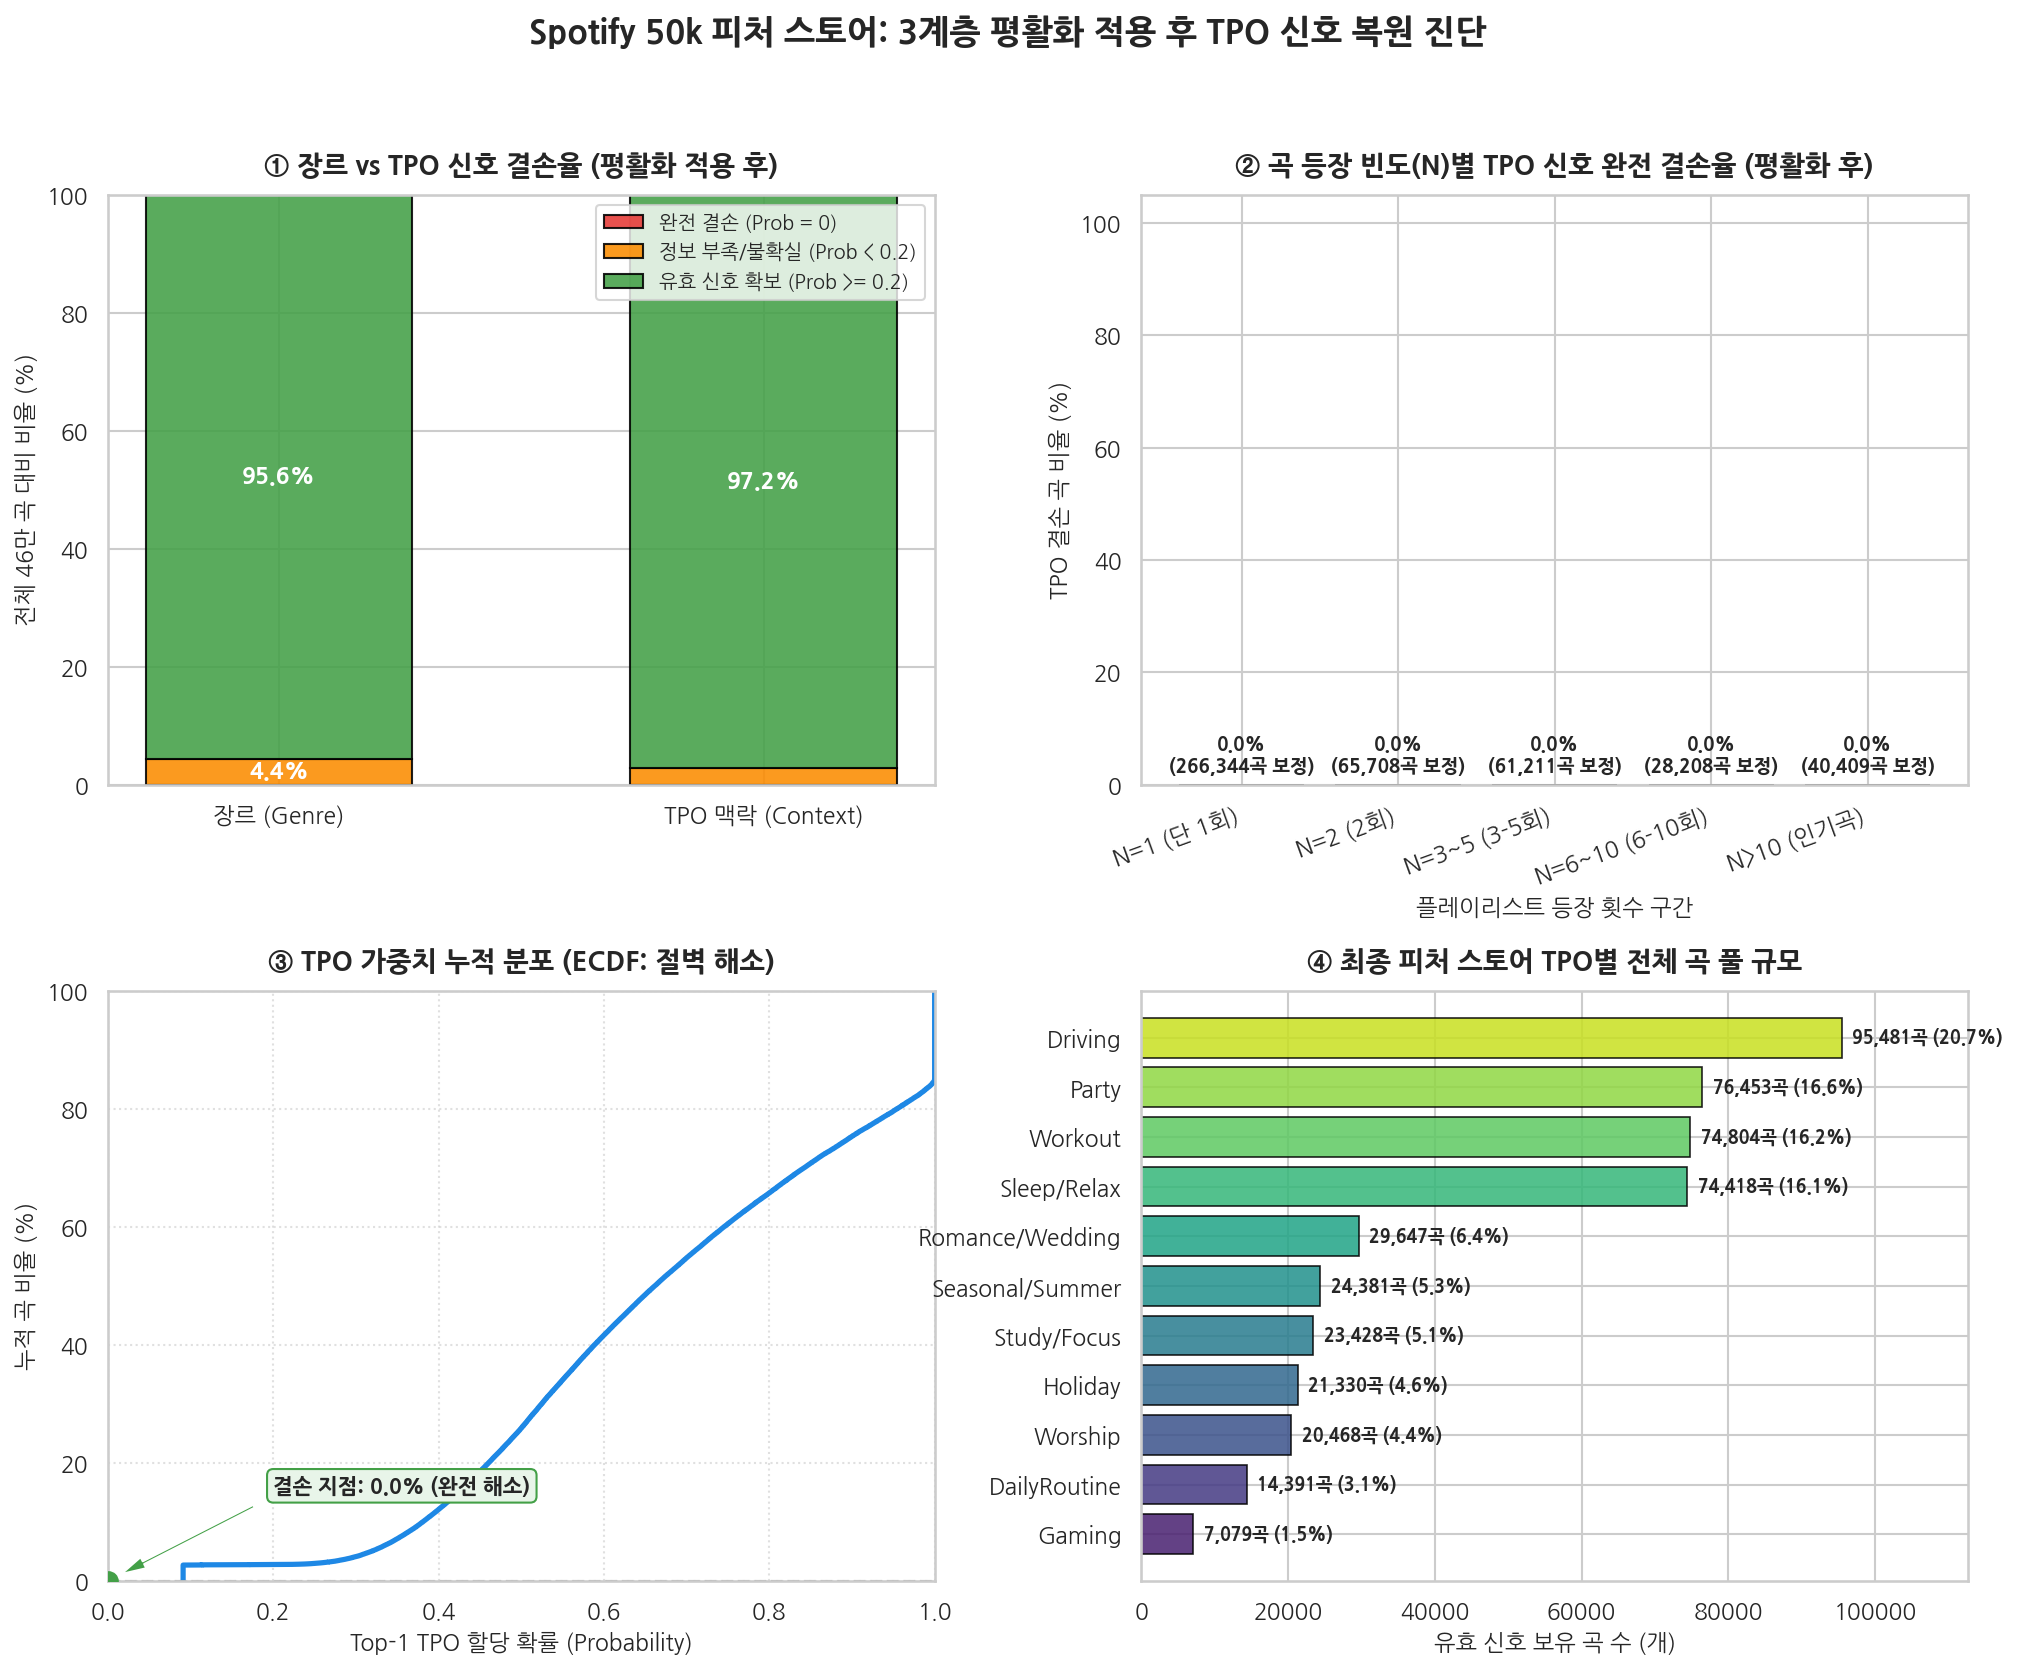

In [ ]:
# 1. 한글 폰트 라이브러리 설치 및 임포트
!pip install -q koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import koreanize_matplotlib

# 스타일 설정
sns.set_theme(style="whitegrid", font="NanumGothic")
plt.rcParams['figure.dpi'] = 150

# ==============================================================================
# [1] 데이터 로드 및 결손율 지표 집계
# ==============================================================================
print("=== 평활화 후 TPO 결손율 분석 데이터 로드 중... ===")
# 최종 구축된 피처 스토어 경로
profile_path = Path("results_final_feature_store/track_2d_hierarchical_profiles.parquet")

# 신규 피처 스토어 로드
profile_df = pd.read_parquet(
    profile_path,
    columns=["track_uri", "top_tpo", "top_genre", "genre_prob", "tpo_prob", "appearance_count", "raw_obs_weight_genre", "raw_obs_weight_tpo"]
)

# 등장 횟수 매핑 (피처 스토어 내 컬럼 활용)
profile_df["freq"] = profile_df["appearance_count"].astype(int)
total_tracks = len(profile_df)

print(f"총 분석 대상 곡 수: {total_tracks:,}개")

# ==============================================================================
# [2] 2x2 TPO 결손율 정밀 진단 대시보드 시각화 (동일 포맷)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ------------------------------------------------------------------------------
# (1) [좌상단] 장르 vs TPO 직접+간접 신호 확보율 비교 (The Signal Gap 해소)
# ------------------------------------------------------------------------------
ax1 = axes[0, 0]

def categorize_signal(probs):
    # 평활화 후: prob == 0 (결손), prob < 0.2 (정보부족/모호), prob >= 0.2 (유효 신호)
    zero_pct = (probs == 0).mean() * 100
    weak_pct = ((probs > 0) & (probs < 0.20)).mean() * 100
    solid_pct = (probs >= 0.20).mean() * 100
    return [zero_pct, weak_pct, solid_pct]

genre_ratios = categorize_signal(profile_df["genre_prob"])
tpo_ratios = categorize_signal(profile_df["tpo_prob"])

categories = ["장르 (Genre)", "TPO 맥락 (Context)"]
data_matrix = np.array([genre_ratios, tpo_ratios]) # [Zero, Weak, Solid]

colors = ["#E53935", "#FB8C00", "#43A047"]
labels = ["완전 결손 (Prob = 0)", "정보 부족/불확실 (Prob < 0.2)", "유효 신호 확보 (Prob >= 0.2)"]

bottom = np.zeros(2)
for i in range(3):
    values = data_matrix[:, i]
    bars = ax1.bar(categories, values, bottom=bottom, color=colors[i], label=labels[i], width=0.55, edgecolor="black", alpha=0.88)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3.0:
            y_pos = bottom[j] + val / 2
            ax1.text(bar.get_x() + bar.get_width() / 2, y_pos, f"{val:.1f}%",
                     ha="center", va="center", color="white", fontsize=11, fontweight="bold")
    bottom += values

ax1.set_title("① 장르 vs TPO 신호 결손율 (평활화 적용 후)", fontsize=13, fontweight="bold", pad=10)
ax1.set_ylabel("전체 46만 곡 대비 비율 (%)", fontsize=11)
ax1.set_ylim(0, 100)
ax1.legend(loc="upper right", frameon=True, fontsize=9.5)

# ------------------------------------------------------------------------------
# (2) [우상단] 곡 등장 빈도(N) 구간별 TPO 완전 결손율 (W=0)
# ------------------------------------------------------------------------------
ax2 = axes[0, 1]

bins = [
    ("N=1 (단 1회)", profile_df[profile_df["freq"] == 1]),
    ("N=2 (2회)", profile_df[profile_df["freq"] == 2]),
    ("N=3~5 (3-5회)", profile_df[(profile_df["freq"] >= 3) & (profile_df["freq"] <= 5)]),
    ("N=6~10 (6-10회)", profile_df[(profile_df["freq"] >= 6) & (profile_df["freq"] <= 10)]),
    ("N>10 (인기곡)", profile_df[profile_df["freq"] > 10])
]

tier_names = [b[0] for b in bins]
# 평활화 후에는 확률이 0인 곡이 없으므로 결손율 0%
tpo_zero_rates = [(sub["tpo_prob"] == 0).mean() * 100 for _, sub in bins]
tier_counts = [len(sub) for _, sub in bins]

colors_tpo = ["#43A047", "#43A047", "#43A047", "#43A047", "#43A047"]
bars2 = ax2.bar(tier_names, tpo_zero_rates, color=colors_tpo, edgecolor="black", linewidth=0.8, alpha=0.85)

ax2.set_title("② 곡 등장 빈도(N)별 TPO 신호 완전 결손율 (평활화 후)", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("플레이리스트 등장 횟수 구간", fontsize=11)
ax2.set_ylabel("TPO 결손 곡 비율 (%)", fontsize=11)
ax2.set_xticklabels(tier_names, rotation=20, ha="right")
ax2.set_ylim(0, 105)

for bar, rate, count in zip(bars2, tpo_zero_rates, tier_counts):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, yval + 1.5, f"{rate:.1f}%\n({count:,}곡 보정)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

# ------------------------------------------------------------------------------
# (3) [좌하단] TPO 확신도 누적 분포 (ECDF)
# ------------------------------------------------------------------------------
ax3 = axes[1, 0]

tpo_prob_sorted = np.sort(profile_df["tpo_prob"].values)
yvals = np.arange(1, len(tpo_prob_sorted) + 1) / len(tpo_prob_sorted) * 100

ax3.plot(tpo_prob_sorted, yvals, color="#1E88E5", linewidth=2.5, label="TPO Top-1 확신도 누적 분포")
ax3.set_xlim(0, 1.0)
ax3.set_ylim(0, 100)

zero_pct_val = (profile_df["tpo_prob"] == 0).mean() * 100
ax3.axhline(y=zero_pct_val, color="gray", linestyle="--", alpha=0.7)
ax3.scatter([0], [zero_pct_val], color="#43A047", s=80, zorder=5)

ax3.annotate(f"결손 지점: {zero_pct_val:.1f}% (완전 해소)", xy=(0, zero_pct_val), xytext=(0.2, zero_pct_val + 15),
             arrowprops=dict(facecolor="#43A047", shrink=0.08, width=1.5, headwidth=6),
             fontsize=10, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="#E8F5E9", ec="#43A047"))

ax3.set_title("③ TPO 가중치 누적 분포 (ECDF: 절벽 해소)", fontsize=13, fontweight="bold", pad=10)
ax3.set_xlabel("Top-1 TPO 할당 확률 (Probability)", fontsize=11)
ax3.set_ylabel("누적 곡 비율 (%)", fontsize=11)
ax3.grid(True, linestyle=":", alpha=0.6)

# ------------------------------------------------------------------------------
# (4) [우하단] 11개 세부 TPO 카테고리별 전체 곡 수 분포 (풀 확장 확인)
# ------------------------------------------------------------------------------
ax4 = axes[1, 1]

valid_tpo_df = profile_df[profile_df["tpo_prob"] > 0]
tpo_dist = valid_tpo_df["top_tpo"].value_counts()

tpo_colors = sns.color_palette("viridis", len(tpo_dist))
bars4 = ax4.barh(tpo_dist.index[::-1], tpo_dist.values[::-1], color=tpo_colors, edgecolor="black", linewidth=0.8, alpha=0.85)

ax4.set_title("④ 최종 피처 스토어 TPO별 전체 곡 풀 규모", fontsize=13, fontweight="bold", pad=10)
ax4.set_xlabel("유효 신호 보유 곡 수 (개)", fontsize=11)
ax4.set_xlim(0, max(tpo_dist.values) * 1.18)

for bar, v in zip(bars4, tpo_dist.values[::-1]):
    xval = bar.get_width()
    pct = v / len(valid_tpo_df) * 100
    ax4.text(xval + (max(tpo_dist.values) * 0.015), bar.get_y() + bar.get_height() / 2.0,
             f"{v:,}곡 ({pct:.1f}%)", va="center", ha="left", fontsize=8.5, fontweight="bold")

# ==============================================================================
# [3] 이미지 저장 및 출력
# ==============================================================================
plt.suptitle("Spotify 50k 피처 스토어: 3계층 평활화 적용 후 TPO 신호 복원 진단", fontsize=16, fontweight="bold", y=0.98)

plt.show()



=== 피처 스토어 로드 및 2D 교차 집계 중... ===


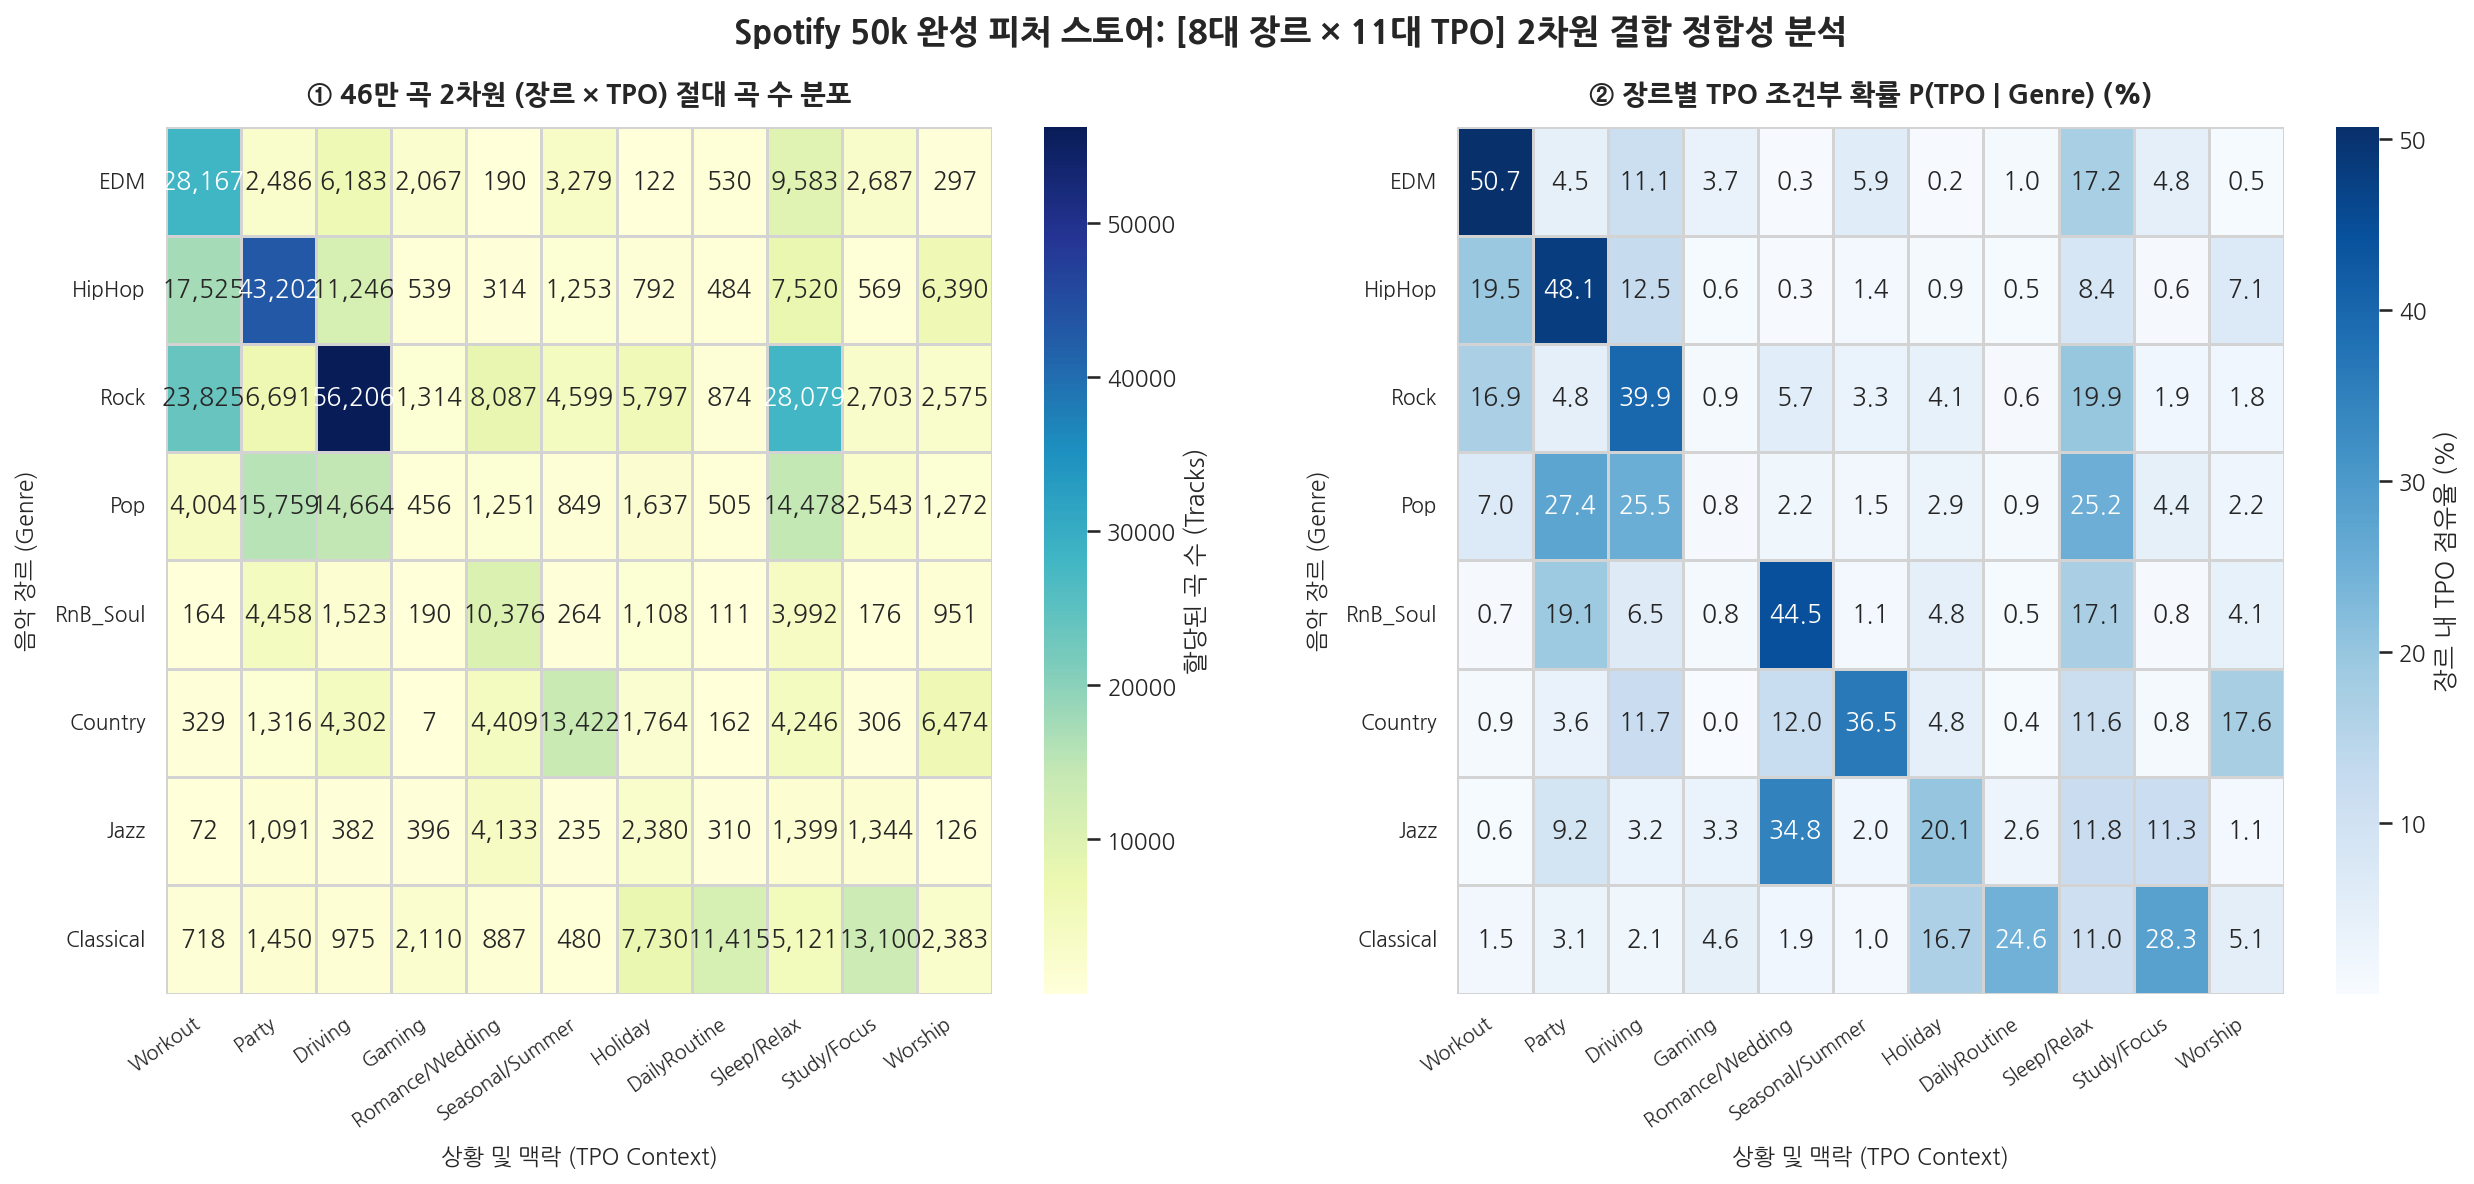

NameError: name 'save_img_path' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import koreanize_matplotlib

# 스타일 설정
sns.set_theme(style="white", font="NanumGothic")
plt.rcParams['figure.dpi'] = 150

# ==============================================================================
# [1] 피처 스토어 로드 및 2차원 교차표 생성
# ==============================================================================
print("=== 피처 스토어 로드 및 2D 교차 집계 중... ===")
feature_path = Path("results_final_feature_store/track_2d_hierarchical_profiles.parquet")
df = pd.read_parquet(feature_path, columns=["top_genre", "top_tpo", "appearance_count"])

genre_order = ["EDM", "HipHop", "Rock", "Pop", "RnB_Soul", "Country", "Jazz", "Classical"]
tpo_order = [
    "Workout", "Party", "Driving", "Gaming",
    "Romance/Wedding", "Seasonal/Summer", "Holiday",
    "DailyRoutine", "Sleep/Relax", "Study/Focus", "Worship"
]

# 1. 절대 곡 수 교차 집계 (Counts)
crosstab_counts = pd.crosstab(df["top_genre"], df["top_tpo"]).reindex(index=genre_order, columns=tpo_order).fillna(0)

# 2. 장르별 TPO 조건부 확률 집계: P(TPO | Genre) (Row-normalized, %)
crosstab_prob = crosstab_counts.div(crosstab_counts.sum(axis=1), axis=0) * 100

# ==============================================================================
# [2] 2D 매크로 정합성 듀얼 히트맵 시각화
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))
plt.subplots_adjust(wspace=0.25)

# ------------------------------------------------------------------------------
# (1) [좌측] 88개 2D 교차 영역별 절대 곡 수 분포
# ------------------------------------------------------------------------------
sns.heatmap(
    crosstab_counts,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    cbar_kws={'label': '할당된 곡 수 (Tracks)'},
    linewidths=0.5,
    linecolor="lightgrey",
    ax=axes[0]
)
axes[0].set_title("① 46만 곡 2차원 (장르 × TPO) 절대 곡 수 분포", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("상황 및 맥락 (TPO Context)", fontsize=11, labelpad=8)
axes[0].set_ylabel("음악 장르 (Genre)", fontsize=11, labelpad=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=10)

# ------------------------------------------------------------------------------
# (2) [우측] 장르 기준 조건부 확률 분포 P(TPO | Genre) (%)
# ------------------------------------------------------------------------------
sns.heatmap(
    crosstab_prob,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={'label': '장르 내 TPO 점유율 (%)'},
    linewidths=0.5,
    linecolor="lightgrey",
    ax=axes[1]
)
axes[1].set_title("② 장르별 TPO 조건부 확률 P(TPO | Genre) (%)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("상황 및 맥락 (TPO Context)", fontsize=11, labelpad=8)
axes[1].set_ylabel("음악 장르 (Genre)", fontsize=11, labelpad=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

# ==============================================================================
# [3] 저장 및 출력
# ==============================================================================
plt.suptitle("Spotify 50k 완성 피처 스토어: [8대 장르 × 11대 TPO] 2차원 결합 정합성 분석", fontsize=16, fontweight="bold", y=0.98)
plt.show()

print(f"\n2D 정합성 히트맵 이미지 저장 완료: {save_img_path}")

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==============================================================================
# [1] 피처 스토어 로드
# ==============================================================================
feature_path = Path("results_final_feature_store/track_2d_hierarchical_profiles.parquet")
df = pd.read_parquet(feature_path)

GENRE_CATEGORIES = ["Classical", "Country", "EDM", "HipHop", "Jazz", "Pop", "RnB_Soul", "Rock"]
TPO_CATEGORIES = [
    "DailyRoutine", "Driving", "Gaming", "Holiday", "Party",
    "Romance/Wedding", "Seasonal/Summer", "Sleep/Relax",
    "Study/Focus", "Workout", "Worship"
]

# ==============================================================================
# [2] 3대 유형별 대표 사례 필터링 및 추출
# ==============================================================================
print("=== [Case Study] 3대 대표 유형별 트랙 정밀 분석 ===")

# 1. 메가 인기곡 (N >= 500)
pop_hits = df[df["appearance_count"] >= 500].sort_values(by="appearance_count", ascending=False).head(4)

# 2. 전문 목적 뾰족곡 (특정 TPO 확신도 >= 0.70)
sharp_tracks = df[
    (df["appearance_count"] >= 10) &
    (df["tpo_prob"] >= 0.70)
].sort_values(by="tpo_prob", ascending=False).head(4)

# 3. N=1 초희소 곡 중 상위 메타데이터로 완벽 보정된 곡 (원시 관측치 W=0 -> TPO 확신도 확보)
rescued_rare_tracks = df[
    (df["appearance_count"] == 1) &
    (df["raw_obs_weight_tpo"] == 0) &
    (df["tpo_prob"] >= 0.40)
].head(4)

# ==============================================================================
# [3] 사례별 비교 분석표 생성
# ==============================================================================
cases = []

for _, r in pop_hits.iterrows():
    cases.append({
        "유형": "① 메가 대중가요",
        "곡명": r["track_name"][:25],
        "아티스트": r["artist_name"][:18],
        "등장 횟수": f"{r['appearance_count']:,}회",
        "원시 TPO 가중치": f"{r['raw_obs_weight_tpo']:.1f}",
        "최종 장르": f"{r['top_genre']} ({r['genre_prob']*100:.1f}%)",
        "최종 TPO": f"{r['top_tpo']} ({r['tpo_prob']*100:.1f}%)",
    })

for _, r in sharp_tracks.iterrows():
    cases.append({
        "유형": "② 특정 목적곡",
        "곡명": r["track_name"][:25],
        "아티스트": r["artist_name"][:18],
        "등장 횟수": f"{r['appearance_count']:,}회",
        "원시 TPO 가중치": f"{r['raw_obs_weight_tpo']:.1f}",
        "최종 장르": f"{r['top_genre']} ({r['genre_prob']*100:.1f}%)",
        "최종 TPO": f"{r['top_tpo']} ({r['tpo_prob']*100:.1f}%)",

    })

for _, r in rescued_rare_tracks.iterrows():
    cases.append({
        "유형": "③ N=1 희소곡",
        "곡명": r["track_name"][:25],
        "아티스트": r["artist_name"][:18],
        "등장 횟수": f"{r['appearance_count']:,}회",
        "원시 TPO 가중치": f"{r['raw_obs_weight_tpo']:.1f} (결손)",
        "최종 장르": f"{r['top_genre']} ({r['genre_prob']*100:.1f}%)",
        "최종 TPO": f"{r['top_tpo']} ({r['tpo_prob']*100:.1f}%)",

    })

case_df = pd.DataFrame(cases)

# CSV 저장
output_csv = Path("results_final_feature_store/case_study_summary.csv")
case_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("\n" + "=" * 120)
print("📋 [3계층 피처 스토어 대표 엣지 케이스 정성 검증 표]")
print("=" * 120)
print(case_df.to_string(index=False))
print("=" * 120)
print(f"저장 완료: {output_csv}")

=== [Case Study] 3대 대표 유형별 트랙 정밀 분석 ===

📋 [3계층 피처 스토어 대표 엣지 케이스 정성 검증 표]
       유형                        곡명             아티스트  등장 횟수 원시 TPO 가중치             최종 장르                  최종 TPO
① 메가 대중가요                   HUMBLE.   Kendrick Lamar 2,231회      376.4    HipHop (94.6%)           Party (71.2%)
① 메가 대중가요                 One Dance            Drake 2,090회      332.7    HipHop (73.6%)           Party (67.4%)
① 메가 대중가요                    Closer The Chainsmokers 2,070회      322.6    HipHop (35.9%)           Party (36.3%)
① 메가 대중가요 Broccoli (feat. Lil Yacht             DRAM 1,974회      346.0    HipHop (92.8%)           Party (82.1%)
 ② 특정 목적곡           Marvelous Light     Charlie Hall    16회        6.0    HipHop (69.9%)        Worship (100.0%)
 ② 특정 목적곡 I Saw Mommy Kissing Santa     The Ronettes    31회       14.9      Jazz (54.2%)        Holiday (100.0%)
 ② 특정 목적곡         Winter Wonderland     Phil Spector    15회        7.1      Jazz (76.3%)        Holiday (100.0%)
 ② 특정 목적곡       A Mars

### 평활화 전

=== [1/3] 원천 데이터 로드 및 순수 Raw 관측치 집계 ===
Using Colab cache for faster access to the 'spotify-million' dataset.

=== [2/3] 평활화 전 2차원 결합 히트맵 생성 중... ===


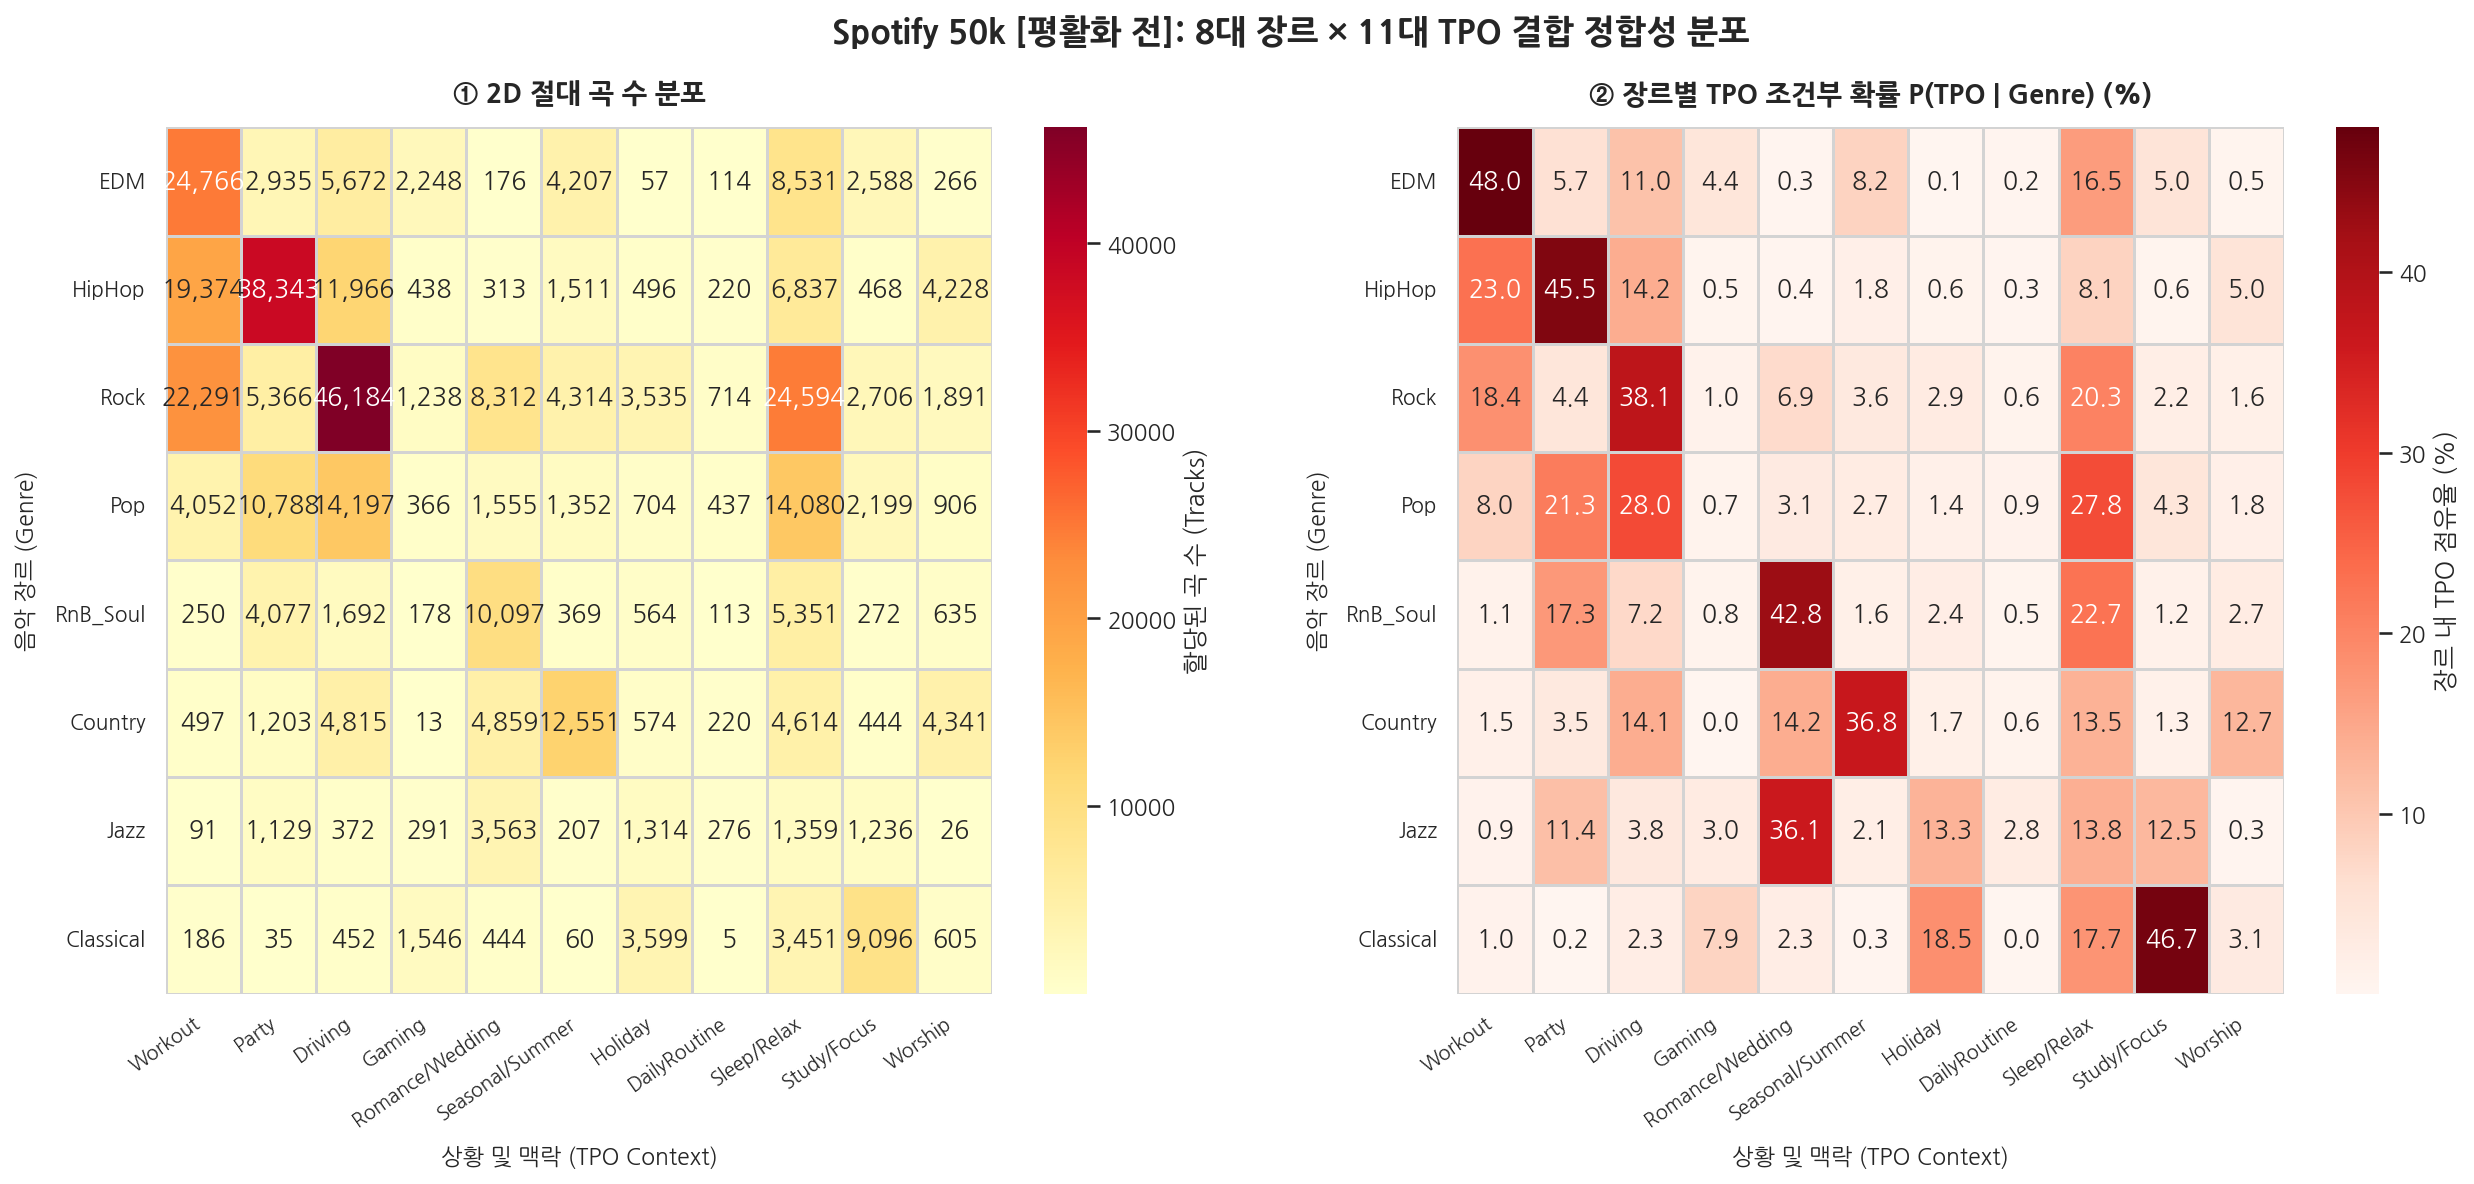


=== [3/3] 평활화 전 동일 엣지 케이스 추출 중... ===

[평활화 적용 전 (Before) 동일 엣지 케이스 정성 검증 표]
       유형                        곡명  등장 횟수 원시 TPO 가중치          평활화 전 장르        평활화 전 TPO
① 메가 대중가요                   HUMBLE. 2,231회      376.4    HipHop (94.6%)    Party (71.2%)
① 메가 대중가요                 One Dance 2,090회      332.7    HipHop (73.6%)    Party (67.4%)
 ② 특정 목적곡                    Closer   208회       34.6    HipHop (52.2%)    Party (76.9%)
① 메가 대중가요 Broccoli (feat. Lil Yacht 1,974회      346.0    HipHop (92.8%)    Party (82.1%)
 ② 특정 목적곡           Marvelous Light     8회        3.0    HipHop (51.6%) Worship (100.0%)
 ② 특정 목적곡 I Saw Mommy Kissing Santa   101회       49.4      Jazz (43.9%)  Holiday (99.7%)
 ② 특정 목적곡         Winter Wonderland   115회       53.0 Classical (42.2%)  Holiday (99.5%)
 ② 특정 목적곡       A Marshmallow World    15회        7.2      Jazz (76.9%) Holiday (100.0%)
③ N=1 희소곡 Forbidden Love Affair (Th     1회        0.0 RnB_Soul (100.0%)         미분류 (결손)
③ N=1 희소곡            Still Strok

In [ ]:
import os
import glob
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import koreanize_matplotlib

# 스타일 설정
sns.set_theme(style="white", font="NanumGothic")
plt.rcParams['figure.dpi'] = 150

# ==============================================================================
# [1] 데이터 로드 및 원시(Raw) 관측치 집계
# ==============================================================================
print("=== [1/3] 원천 데이터 로드 및 순수 Raw 관측치 집계 ===")
PARQUET_PATH = Path("sample_50k_flat.parquet")
PL_LABEL_PATH = Path("results_2d_joint_profiling/50k_2d_joint_pseudo_labels.csv")
OUTPUT_DIR = Path("results_final_feature_store")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENRE_CATEGORIES = ["Classical", "Country", "EDM", "HipHop", "Jazz", "Pop", "RnB_Soul", "Rock"]
TPO_CATEGORIES = [
    "DailyRoutine", "Driving", "Gaming", "Holiday", "Party",
    "Romance/Wedding", "Seasonal/Summer", "Sleep/Relax",
    "Study/Focus", "Workout", "Worship"
]

NUM_GENRES = len(GENRE_CATEGORIES)
NUM_TPOS = len(TPO_CATEGORIES)
genre_to_idx = {c: i for i, c in enumerate(GENRE_CATEGORIES)}
tpo_to_idx = {c: i for i, c in enumerate(TPO_CATEGORIES)}

tracks_df = pd.read_parquet(PARQUET_PATH, columns=["pid", "track_uri", "artist_uri", "album_uri"])
tracks_df["pid"] = tracks_df["pid"].astype(int)
track_counts = tracks_df["track_uri"].value_counts().to_dict()

# 이름 사전 로드 (Kaggle JSON)
dataset_dir = kagglehub.dataset_download('himanshuwagh/spotify-million')
data_path = os.path.join(dataset_dir, "data") if os.path.exists(os.path.join(dataset_dir, "data")) else dataset_dir
json_files = sorted(glob.glob(os.path.join(data_path, "mpd.slice.*.json")))[:50]

uri_to_track_name = {}
uri_to_artist_name = {}
for fpath in json_files:
    with open(fpath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    for pl in data.get('playlists', []):
        for tr in pl.get('tracks', []):
            t_uri, a_uri = tr.get('track_uri'), tr.get('artist_uri')
            if t_uri and t_uri not in uri_to_track_name:
                uri_to_track_name[t_uri] = tr.get('track_name', 'Unknown Track')
            if a_uri and a_uri not in uri_to_artist_name:
                uri_to_artist_name[a_uri] = tr.get('artist_name', 'Unknown Artist')

# 플리 레이블 로드
pl_df = pd.read_csv(PL_LABEL_PATH)
pid_to_genre = dict(zip(pl_df['pid'], zip(pl_df['pred_genre'], pl_df['genre_confidence'])))
pid_to_tpo = dict(zip(pl_df['pid'], zip(pl_df['pred_tpo'], pl_df['tpo_confidence'])))

# 순수 트랙 단위 Raw 관측치 누적 (평활화 전)
raw_tr_g = defaultdict(lambda: np.zeros(NUM_GENRES))
raw_tr_g_w = defaultdict(float)
raw_tr_t = defaultdict(lambda: np.zeros(NUM_TPOS))
raw_tr_t_w = defaultdict(float)

for _, row in tracks_df.drop_duplicates(subset=["pid", "track_uri"]).iterrows():
    pid = int(row["pid"])
    t = str(row["track_uri"])

    if pid in pid_to_genre:
        g, conf = pid_to_genre[pid]
        if pd.notna(g) and g in genre_to_idx and conf > 0:
            idx, w = genre_to_idx[g], float(conf)
            raw_tr_g[t][idx] += w
            raw_tr_g_w[t] += w

    if pid in pid_to_tpo:
        t_val, conf = pid_to_tpo[pid]
        if pd.notna(t_val) and t_val in tpo_to_idx and conf > 0:
            idx, w = tpo_to_idx[t_val], float(conf)
            raw_tr_t[t][idx] += w
            raw_tr_t_w[t] += w

# 평활화 전 Raw 프로필 생성
raw_records = []
for t in tracks_df["track_uri"].unique():
    gw = raw_tr_g_w[t]
    tw = raw_tr_t_w[t]

    top_g = GENRE_CATEGORIES[int(np.argmax(raw_tr_g[t]))] if gw > 0 else "Unclassified"
    g_prob = (np.max(raw_tr_g[t]) / gw) if gw > 0 else 0.0

    top_t = TPO_CATEGORIES[int(np.argmax(raw_tr_t[t]))] if tw > 0 else "Unclassified"
    t_prob = (np.max(raw_tr_t[t]) / tw) if tw > 0 else 0.0

    raw_records.append({
        "track_uri": t,
        "track_name": uri_to_track_name.get(t, "Unknown Track"),
        "top_genre": top_g,
        "genre_prob": round(g_prob, 4),
        "raw_obs_weight_genre": round(gw, 2),
        "top_tpo": top_t,
        "tpo_prob": round(t_prob, 4),
        "raw_obs_weight_tpo": round(tw, 2),
        "appearance_count": track_counts.get(t, 1)
    })

raw_df = pd.DataFrame(raw_records)

# ==============================================================================
# [2] 분석 ①: 평활화 전 2D 결합 히트맵 시각화
# ==============================================================================
print("\n=== [2/3] 평활화 전 2차원 결합 히트맵 생성 중... ===")

# 유효 관측치를 가진 곡들만 교차표 생성
valid_raw = raw_df[(raw_df["top_genre"] != "Unclassified") & (raw_df["top_tpo"] != "Unclassified")]

genre_order = ["EDM", "HipHop", "Rock", "Pop", "RnB_Soul", "Country", "Jazz", "Classical"]
tpo_order = [
    "Workout", "Party", "Driving", "Gaming",
    "Romance/Wedding", "Seasonal/Summer", "Holiday",
    "DailyRoutine", "Sleep/Relax", "Study/Focus", "Worship"
]

crosstab_counts_before = pd.crosstab(valid_raw["top_genre"], valid_raw["top_tpo"]).reindex(index=genre_order, columns=tpo_order).fillna(0)
crosstab_prob_before = crosstab_counts_before.div(crosstab_counts_before.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))
plt.subplots_adjust(wspace=0.25)

# (1) 절대 곡 수 히트맵
sns.heatmap(
    crosstab_counts_before,
    annot=True,
    fmt=",.0f",
    cmap="YlOrRd",
    cbar_kws={'label': '할당된 곡 수 (Tracks)'},
    linewidths=0.5,
    linecolor="lightgrey",
    ax=axes[0]
)
axes[0].set_title(f"① 2D 절대 곡 수 분포", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("상황 및 맥락 (TPO Context)", fontsize=11, labelpad=8)
axes[0].set_ylabel("음악 장르 (Genre)", fontsize=11, labelpad=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=10)

# (2) 조건부 확률 히트맵
sns.heatmap(
    crosstab_prob_before,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar_kws={'label': '장르 내 TPO 점유율 (%)'},
    linewidths=0.5,
    linecolor="lightgrey",
    ax=axes[1]
)
axes[1].set_title("② 장르별 TPO 조건부 확률 P(TPO | Genre) (%)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("상황 및 맥락 (TPO Context)", fontsize=11, labelpad=8)
axes[1].set_ylabel("음악 장르 (Genre)", fontsize=11, labelpad=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right", fontsize=9.5)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=10)

plt.suptitle("Spotify 50k [평활화 전]: 8대 장르 × 11대 TPO 결합 정합성 분포", fontsize=16, fontweight="bold", y=0.98)
save_img_path = "/content/genre_x_tpo_2d_heatmap_BEFORE.png"
plt.savefig(save_img_path, dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================================
# [3] 분석 ②: 평활화 전 대표 엣지 케이스 정성 검증표
# ==============================================================================
print("\n=== [3/3] 평활화 전 동일 엣지 케이스 추출 중... ===")

# 앞서 선정한 대표 곡들의 URI 추출
target_tracks = [
    # ① 대중가요
    "HUMBLE.", "One Dance", "Closer", "Broccoli",
    # ② 전문곡
    "Marvelous Light", "I Saw Mommy Kissing Santa", "Winter Wonderland", "A Marshmallow World",
    # ③ 희소곡
    "Forbidden Love Affair", "Still Strokin'"
]

case_rows = []
for name in target_tracks:
    sub = raw_df[raw_df["track_name"].str.contains(name, case=False, na=False)]
    if len(sub) > 0:
        r = sub.iloc[0]
        n_cnt = r["appearance_count"]

        # 유형 분류
        if n_cnt >= 500:
            ctype = "① 메가 대중가요"

        elif n_cnt == 1:
            ctype = "③ N=1 희소곡"

        else:
            ctype = "② 특정 목적곡"


        case_rows.append({
            "유형": ctype,
            "곡명": r["track_name"][:25],
            "등장 횟수": f"{n_cnt:,}회",
            "원시 TPO 가중치": f"{r['raw_obs_weight_tpo']:.1f}",
            "평활화 전 장르": f"{r['top_genre']} ({r['genre_prob']*100:.1f}%)" if r['top_genre'] != 'Unclassified' else "미분류 (결손)",
            "평활화 전 TPO": f"{r['top_tpo']} ({r['tpo_prob']*100:.1f}%)" if r['top_tpo'] != 'Unclassified' else "미분류 (결손)"
        })

case_before_df = pd.DataFrame(case_rows)
case_before_df.to_csv(OUTPUT_DIR / "case_study_summary_BEFORE.csv", index=False, encoding="utf-8-sig")

print("\n" + "=" * 125)
print("[평활화 적용 전 (Before) 동일 엣지 케이스 정성 검증 표]")
print("=" * 125)
print(case_before_df.to_string(index=False))
print("=" * 125)

## 추천 시스템 서빙

In [ ]:
import pandas as pd

class Track2DFeatureStore:
    def __init__(self, parquet_path="results_final_feature_store/track_2d_hierarchical_profiles.parquet"):
        self.df = pd.read_parquet(parquet_path).set_index("track_uri")
        print(f"피처 스토어 로드 완료 (총 {len(self.df):,}개 트랙)")

    def get_profile(self, track_uri: str) -> dict:
        """단일 곡 2D 장르/TPO 확률 벡터 조회"""
        if track_uri not in self.df.index:
            return None
        r = self.df.loc[track_uri]
        return {
            "track_name": r["track_name"],
            "artist_name": r["artist_name"],
            "top_genre": (r["top_genre"], r["genre_prob"]),
            "top_tpo": (r["top_tpo"], r["tpo_prob"]),
            "genre_vector": r["genre_vector"],  # 8차원 장르 확률
            "tpo_vector": r["tpo_vector"]       # 11차원 TPO 확률
        }

    def filter_tracks(self, genre: str, tpo: str, min_prob: float = 0.3) -> pd.DataFrame:
        """[장르 x TPO] 조건 매칭 트랙 필터링"""
        cond = (
            (self.df["top_genre"] == genre) &
            (self.df["top_tpo"] == tpo) &
            (self.df["genre_prob"] >= min_prob) &
            (self.df["tpo_prob"] >= min_prob)
        )
        return self.df[cond][["track_name", "artist_name", "genre_prob", "tpo_prob", "appearance_count"]]

# 사용 예시
store = Track2DFeatureStore()
rock_workout_tracks = store.filter_tracks(genre="Rock", tpo="Workout", min_prob=0.4)
print(rock_workout_tracks.head(5))